# Heart Disease Dataset 
(Dataset disponível em > [Kaggle](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset?resource=download) <)

A principal ideia desse Dataset é de alguma maneira conseguir preditar um indíviduo possivelmente com alguma doença cardíaca a partir de 

fatores pessoiais. 


Esse Dataset reúne dados de 1988 de 4 lugares diferentes, sendo eles: Cleveland, Hungary, Switzerland e Long Beach V. As colunas são compostas por essas 14 variáveis:



1. **Idade**

2. **Sexo**

3. **Tipo_de_dor_no_peito (4 valores possíveis)**

4. **Pressao_arterial_em_repouso**

5. **Colesterol_serico_mg_dl**

6. **Glicemia_de_jejum_maior_120mg_dl**

7. **Eletrocardiograma_repouso (valores: 0, 1, 2)**

8. **Frequencia_cardiaca_maxima**

9. **Angina_induzida_por_exercicio**

10. **Oldpeak (depressão do segmento ST induzida pelo exercício em relação ao repouso)**

11. **Inclinacao_ST_pico_exercicio**

12. **Numero_grandes_vasos_fluorescencia (valores: 0–3)**

13. **Escala_defeito (0 = normal; 1 = defeito fixo; 2 = defeito reversível)**


<span style="color:red">IMPORTANTE</span>

Mesmo que o Dataset apresente referências de coleta para aumentar sua veracidade, **ele** ainda pode **gerar desconfiança**.

Ao entrar na aba <span style="color:#c7c77d">Discussion</span> do Kaggle, nos deparamos com um <i>paper</i> que mostra a inconsistência desse Dataset em relação ao lugar de onde foi coletado: [paper](https://libres.uncg.edu/ir/ecsu/f/Brandon_Simmons_Thesis-Final.pdf). Veja um exemplo de inconsistência na imagem a seguir:

![image](images/paperex.png)

Então provavelmente o Dataset foi modificado para que modelos obtivessem resultados melhores.

Por exemplo:

Foi observado que muitos modelos classificavam errado específicos "x" instâncias não doentes como doentes,

logo foram alterados os seus targets.

Para contornar essa situação iremos "aleatorizar" um pouco nossas instâncias, removendo dados aleatoriamente e depois

fazendo um método de imputação

# Limpeza Inicial do Dataset

In [512]:
# Importações Iniciais

import numpy as np
import pandas as pd

In [513]:
# Carregando Dataset

heart_ds = pd.read_csv("data/heart.csv")
heart_ds.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [514]:
len(heart_ds)

1025

In [515]:
heart_ds.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1020     True
1021     True
1022     True
1023     True
1024     True
Length: 1025, dtype: bool

In [516]:
heart_ds = heart_ds.drop_duplicates()
len(heart_ds)

302

Temos inicialmente 1025 pacientes para analisar, porém ao analisarmos mais a fundo vemos que vários desses dados são dados duplicados, ou seja, são apenas linhas repetidas, e elaborar modelos com Datasets com dados repetidos é péssimo, já que dessa maneira estamos enviesando a distribuição dos dados.

# Delete e Imputação de Dados

In [517]:
# Apagando dados aleatórios
base = heart_ds.copy()
fonte = "heart_ds (kernel)"

print(f"Fonte de dados: {fonte} - shape: {base.shape}")

# 2) Definir coluna alvo (não apagaremos o alvo para manter a tarefa de classificação)
if 'target' in base.columns:
    target_col = 'target'

# 3) Copiar e aplicar máscara aleatória de 20% (por célula), exceto na coluna alvo
rng = np.random.default_rng(42)
mask = rng.random(base.shape) < 0.2
if target_col in base.columns:
    target_idx = base.columns.get_loc(target_col)
    mask[:, target_idx] = False

heart_ds_missing = base.copy()
# Aplicar NaN com base na máscara (funciona para numéricos e também converte ints para float quando necessário)
heart_ds_missing = heart_ds_missing.mask(mask)

# 4) Relatório de faltantes por coluna
na_counts = heart_ds_missing.isna().sum()
print("Valores faltantes por coluna (após mascarar 20%):")
print(na_counts.to_string())

# 5) Pré-visualização
display(heart_ds_missing.head())

Fonte de dados: heart_ds (kernel) - shape: (302, 14)
Valores faltantes por coluna (após mascarar 20%):
age         54
sex         65
cp          70
trestbps    62
chol        61
fbs         63
restecg     74
thalach     68
exang       58
oldpeak     56
slope       58
ca          58
thal        59
target       0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,NaN,0.0,1.0,168.0,NaN,1.0,2.0,2.0,3.0,0
1,53.0,1.0,0.0,NaN,203.0,1.0,0.0,155.0,1.0,3.1,0.0,NaN,3.0,0
2,NaN,1.0,0.0,145.0,174.0,0.0,1.0,NaN,NaN,2.6,0.0,0.0,3.0,0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,NaN,NaN,NaN,2.0,1.0,3.0,0
4,62.0,0.0,NaN,NaN,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3.0,NaN,0


Vamos passar o Dataframe com os novos valores de <span style="color:yellow">NaN</span> para uma matriz e fazer então a imputação

In [518]:
def npar_to_df(Matrix:np.array) -> pd.DataFrame:
    dict_ = {}
    list_vars = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal","target"]
    list_coluns = []
    for i in range(14):
        list_coluns.append(Matrix[i])
    for i in range(14):
        dict_[list_vars[i]] =  list_coluns[i]
    
    return pd.DataFrame(dict_)

    

In [519]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import pandas as pd

scaler = StandardScaler()
heart_scaled = scaler.fit_transform(heart_ds_missing)

imputer = KNNImputer(n_neighbors=5)
heart_imputed_scaled = imputer.fit_transform(heart_scaled)

heart_imputed = scaler.inverse_transform(heart_imputed_scaled)

heart_imputed = pd.DataFrame(heart_imputed, columns=heart_ds_missing.columns)

In [520]:
heart_imputed.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,240.8,0.0,1.0,168.0,0.6,1.0,2.0,2.0,3.0,0.0
1,53.0,1.0,0.0,149.6,203.0,1.0,0.0,155.0,1.0,3.1,0.0,1.4,3.0,0.0
2,53.8,1.0,0.0,145.0,174.0,0.0,1.0,142.8,0.2,2.6,0.0,0.0,3.0,0.0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,146.8,0.6,1.8,2.0,1.0,3.0,0.0
4,62.0,0.0,0.4,127.6,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3.0,2.6,0.0


In [521]:
heart_imputed["sex"] = heart_imputed["sex"].apply(lambda x: 1 if x > 0.5 else 0)
heart_imputed["fbs"] = heart_imputed["fbs"].apply(lambda x: 1 if x > 0.5 else 0)
heart_imputed["exang"] = heart_imputed["exang"].apply(lambda x: 1 if x > 0.5 else 0)
heart_imputed["cp"]      = np.clip(np.round(heart_imputed["cp"]), 0, 3)
heart_imputed["restecg"] = np.clip(np.round(heart_imputed["restecg"]), 0, 2)
heart_imputed["slope"]   = np.clip(np.round(heart_imputed["slope"]), 0, 2)
heart_imputed["ca"]      = np.clip(np.round(heart_imputed["ca"]), 0, 4)
heart_imputed["thal"]    = np.clip(np.round(heart_imputed["thal"]), 0, 3)




In [522]:
heart_imputed["cp"]      = np.clip(np.round(heart_imputed["cp"]), 0, 3)
heart_imputed["restecg"] = np.clip(np.round(heart_imputed["restecg"]), 0, 2)
heart_imputed["slope"]   = np.clip(np.round(heart_imputed["slope"]), 0, 2)
heart_imputed["ca"]      = np.clip(np.round(heart_imputed["ca"]), 0, 4)
heart_imputed["thal"]    = np.clip(np.round(heart_imputed["thal"]), 0, 3)


# Análise Exploratória

In [523]:
# Informações
heart_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    float64
 1   sex       302 non-null    int64  
 2   cp        302 non-null    float64
 3   trestbps  302 non-null    float64
 4   chol      302 non-null    float64
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    float64
 7   thalach   302 non-null    float64
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    float64
 11  ca        302 non-null    float64
 12  thal      302 non-null    float64
 13  target    302 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 33.2 KB


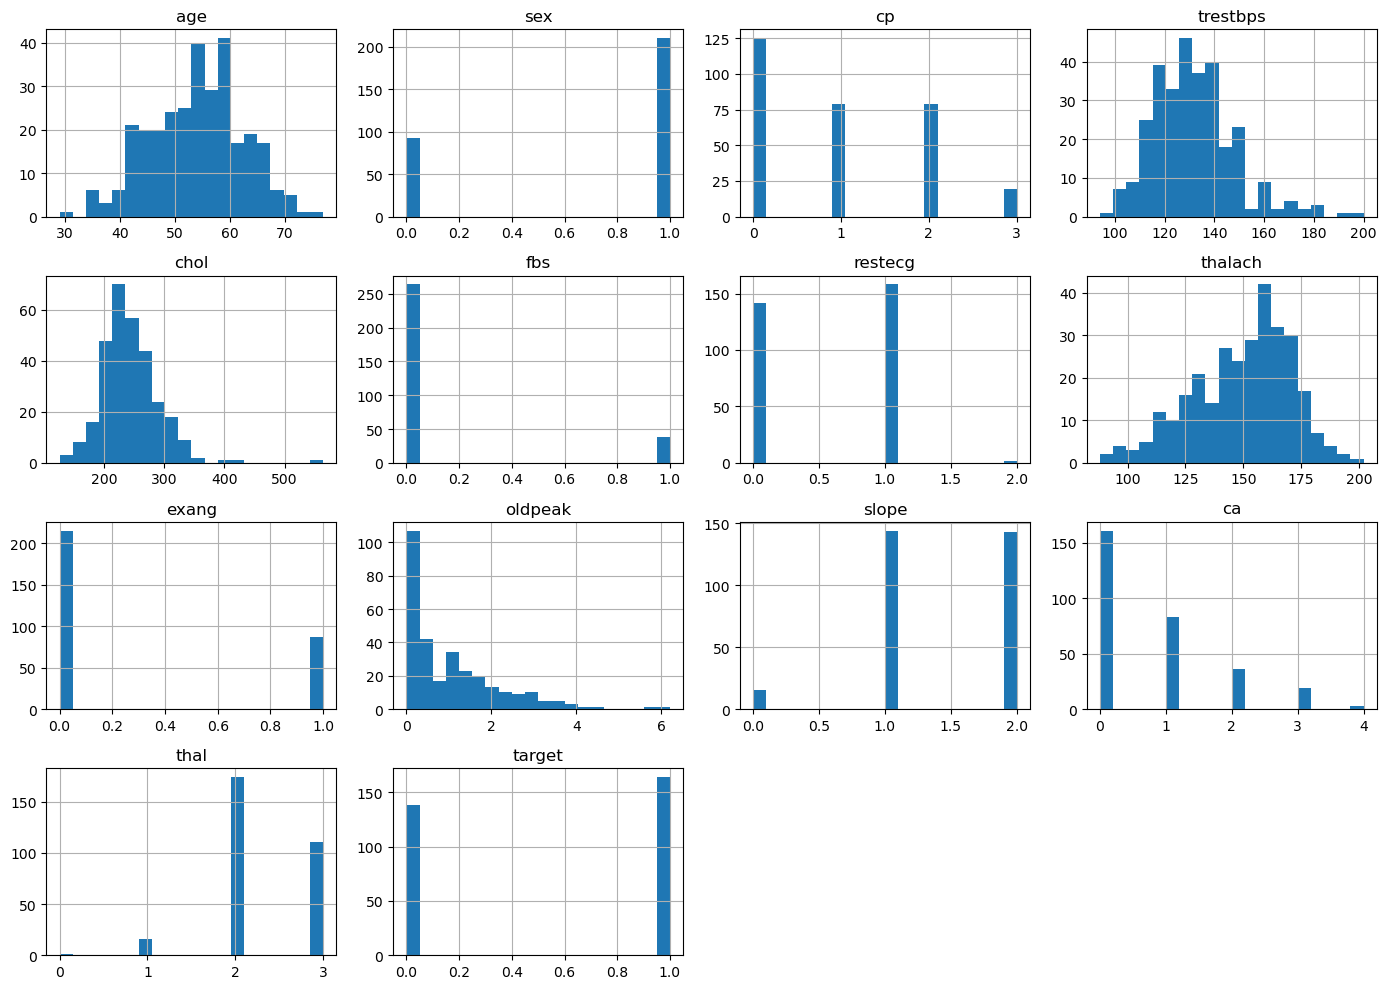

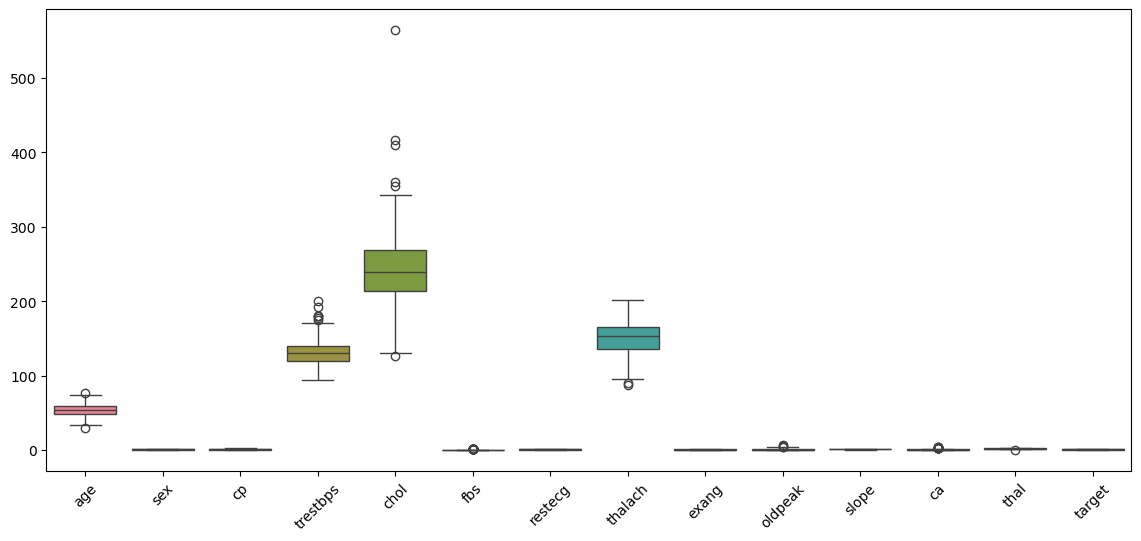

In [524]:
import matplotlib.pyplot as plt
import seaborn as sns

heart_imputed.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

# Boxplots para verificar outliers
plt.figure(figsize=(14, 6))
sns.boxplot(data=heart_imputed.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.show()
     


Podemos claramente ver um outlier olhando para a coluna **chol** então retiraremos ele para não afetar os nossos resultados

In [525]:
heart_imputed = heart_imputed.reset_index()
heart_imputed.loc[heart_imputed["chol"] > 500]

,index,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
128,128,67.0,0,2.0,115.0,564.0,0,0.0,160.0,0,1.6,2.0,0.0,3.0,1.0


In [526]:
heart_imputed = heart_imputed.drop(index = 128)

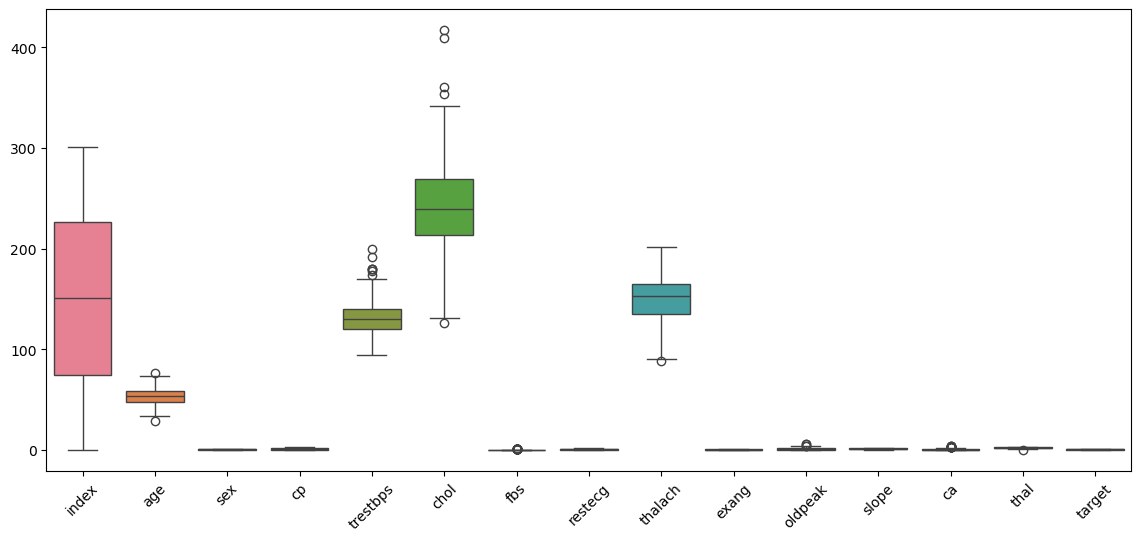

In [527]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=heart_imputed.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.show()

A distância entre pontos em uma reta é apenas dada por $p_2 - p_1$

porém quanto mais aumentamos a dimensão mesmo que a diferença nos eixos seja pouca podemos observar uma grande 

distância no espaço completo

se $\delta$ é a diferença entre cada coordenada de $p_1$ e $p_2$ temos:

$dist(p_1,p_2)$ em $\mathbb{R}^{10}$ agora será $\sqrt{10}*\delta$

veja que mesmo que esses deltas não sejam tão problemáticos, ao aumentar a dimensão podemos estar falando de pontos distantes demais

Então inspirado nisso, implementaremos um método moderno para identificação de outliers no espaço completo

# Isolation Forest — Detecção de Outliers


O **Isolation Forest** é um algoritmo de aprendizado de máquina usado para detectar **outliers** em um conjunto de dados.  
Ele é um método **não supervisionado**, ou seja, não precisa de rótulos para funcionar.

A ideia central é que **pontos anômalos são mais fáceis de isolar** do que os pontos normais.  
O algoritmo cria várias árvores de decisão aleatórias e mede quantas divisões são necessárias para isolar cada ponto.

- **Pontos normais** exigem mais divisões, pois estão em regiões densas.  
- **Outliers** são isolados rapidamente, pois estão em regiões mais vazias.

---

## Funcionamento básico

1. Escolhe aleatoriamente uma variável (feature).  
2. Escolhe um ponto de corte dentro do intervalo dessa variável.  
3. Divide os dados e repete o processo em cada subconjunto.  
4. Mede quantas divisões (profundidade) foram necessárias para isolar cada amostra.

O comprimento médio do caminho até o isolamento é usado para calcular um **score de anomalia**:  
- Valores próximos de 1 indicam *outliers*.  
- Valores próximos de 0,5 indicam pontos normais.

---

## Parâmetro de Contaminação

O parâmetro **`contamination`** define a **proporção esperada de outliers** no conjunto de dados.  
Ele influencia o ponto de corte usado para separar observações normais e anômalas.

Por exemplo:
- `contamination=0.05` significa que o modelo espera que 5% dos dados sejam outliers.  
- Se esse valor for muito alto, o modelo pode marcar pontos normais como anômalos.  
- Se for muito baixo, pode deixar de detectar outliers verdadeiros.

Na prática, esse valor é escolhido com base no conhecimento do domínio ou testado empiricamente.

---


Como o dado é pequeno e, em teoria é bem selecionado, escolhemos o parâmetro de contaminação como 0.01. Esperando 1% do Dataset como outlier

In [528]:
from sklearn.ensemble import IsolationForest

def detect_outliers_iforest(df, contamination=0.01, random_state=42):
    model = IsolationForest(contamination=contamination, random_state=random_state)
    numeric_df = df.select_dtypes(include='number')
    preds = model.fit_predict(numeric_df)
    outlier_mask = preds == -1
    return df[outlier_mask]

outliers = detect_outliers_iforest(heart_imputed)
print(f"Outliers encontrados: {len(outliers)}")
outliers.head()


Outliers encontrados: 3


,index,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
4,4,62.0,0,0.0,127.6,294.0,1,1.0,106.0,0,1.90,1.0,3.0,3.0,0.0
6,6,62.8,1,0.0,114.0,261.2,0,0.0,140.0,0,4.40,0.0,3.0,1.0,0.0
246,246,63.0,1,3.0,145.0,233.0,1,0.0,150.0,0,1.22,0.0,0.0,1.0,1.0


#Conclusão Heart Disease

/tmp/ipykernel_7053/3325964075.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


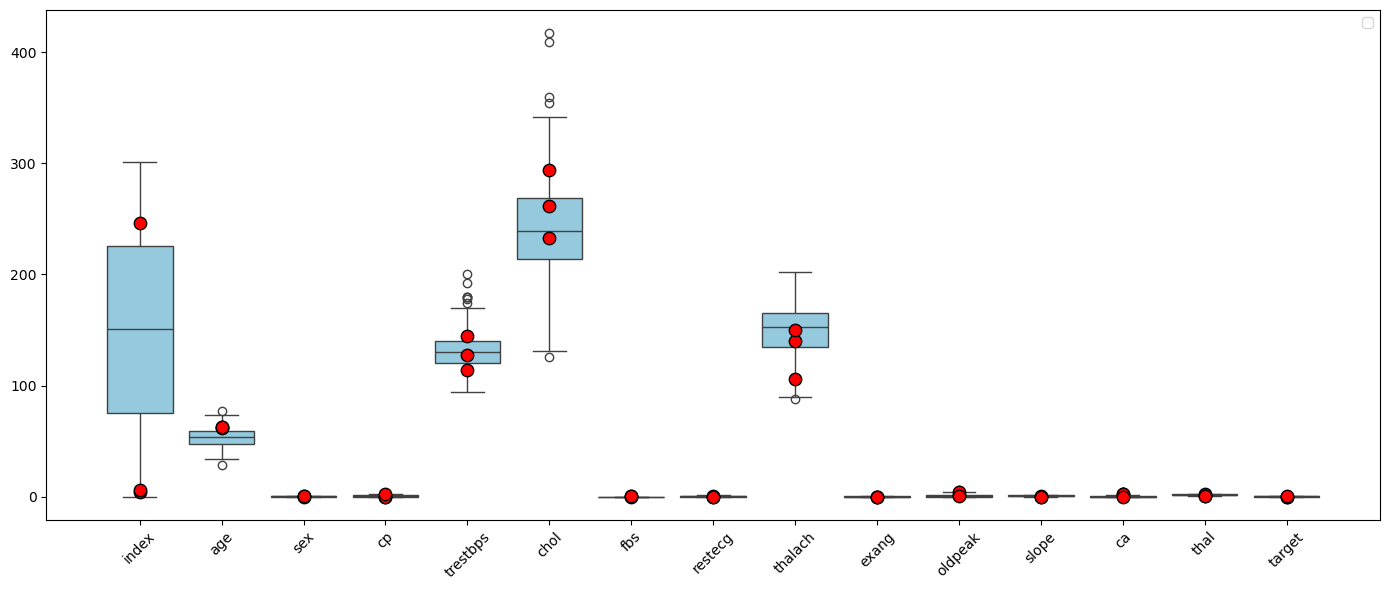

In [529]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(14, 6))
sns.boxplot(data=heart_imputed.select_dtypes(include=np.number), color='skyblue')

indices_destacados = [4, 6, 246]

for i, col in enumerate(heart_imputed.select_dtypes(include=np.number).columns):
    y_vals = heart_imputed.loc[indices_destacados, col]
    plt.scatter(
        [i] * len(indices_destacados), 
        y_vals, 
        color='red', 
        s=80, 
        edgecolor='black', 
        zorder=10,
    )

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Ánalise de variáveis do tipo Numéricas contínuas

Analisando esses tipos de variáveis podemos identificar a tendência central, dispersão, outliers...
Colunas desse tipo:
* **age** (idade), **trestbps**(pressão arterial), **chol** (colesterol),**thalach** (frequência cardíaca máxima), **oldpeak** (depressão ST)

 Analisando somente a coluna da Idade:

In [530]:
df = heart_imputed.copy() # Cópia para análise

In [531]:
df["age"].describe()


count    301.000000
mean      53.845847
std        8.373396
min       29.000000
25%       48.000000
50%       54.000000
75%       59.000000
max       77.000000
Name: age, dtype: float64

Verificamos a idade min é de 29 e a máx é 77 anos, ou seja, não temos valores potenciais valores estranhos também.

In [532]:
df["sex"] = df["sex"].map({0: "Mulher", 1: "Homem"})


### Análise da distribuição da coluna idade (em anos)

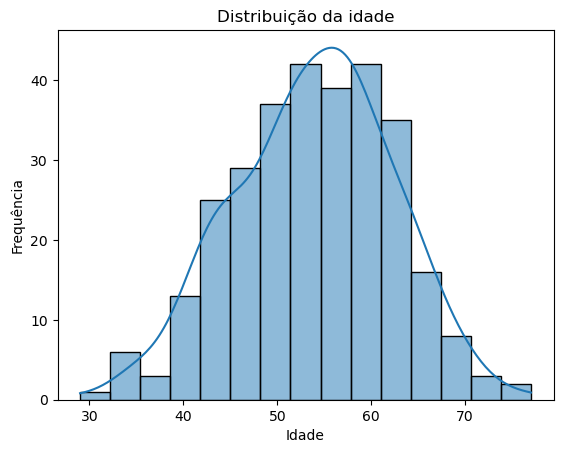

In [533]:
#Distribuição de idade
sns.histplot(df["age"],kde=True)
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.title("Distribuição da idade")
plt.show()


In [534]:
import altair as alt
#Grafico da quantidade de homens e mulheres
alt.Chart(df).mark_bar().encode(
    x=alt.X('sex:O', title='Sexo'),
    y=alt.Y('count():Q', title='Quantidade'),
).properties(
    title='Quantidade por Sexo',
    width=300, #largura
    height=600 #altura
)

/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

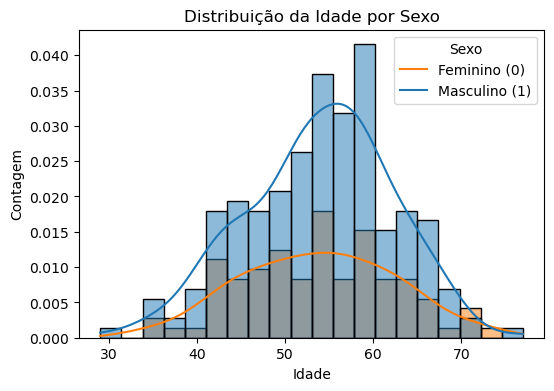

Estatística t: 0.07593746861115405
p-valor: 0.9395614640370069
Não há diferença significativa na idade média entre homens e mulheres.


In [535]:
import seaborn as sns
import matplotlib.pyplot as plt
# Distribuição das idades por sexo
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="age", hue="sex", kde=True, bins=20, alpha=0.5,stat="density" )
plt.title("Distribuição da Idade por Sexo")
plt.xlabel("Idade")
plt.ylabel("Contagem")
plt.legend(title="Sexo", labels=["Feminino (0)", "Masculino (1)"])
plt.show()

# Teste t
from scipy.stats import ttest_ind

idade_homens = df[df["sex"] == "Homem"]["age"]
idade_mulheres = df[df["sex"] == "Mulher"]["age"]

t_stat, p_value = ttest_ind(idade_homens, idade_mulheres, equal_var=False)

print("Estatística t:", t_stat)
print("p-valor:", p_value)

if p_value < 0.05:
    print("Há diferença significativa na idade média entre homens e mulheres.")
else:
    print("Não há diferença significativa na idade média entre homens e mulheres.")

In [536]:
df.groupby("sex")["age"].describe()


,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
Homem,210.0,53.870476,8.263298,29.0,48.7,54.0,59.0,77.0
Mulher,91.0,53.789011,8.668429,34.0,47.7,54.0,60.0,74.0


Análise: Há uma indicação de que as mulheres do estudo são, em geral, mais velhas. Como a idade é **fator de risco** para problemas cardíacos, isso pode influenciar os resultados clínicos (ex: pressão alta, angina, defeitos eletrocardiográficos) das mulheres.

In [537]:
import pandas as pd

# Ajuste os bins conforme o range das idades do seu dataset
bins = [29, 40, 50, 60, 70, 80]
labels = ['30-40', '41-50', '51-60', '61-70', '71-80']

df['Faixa_Idade'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)


In [538]:
tabela = df.groupby(['Faixa_Idade', 'sex', 'cp']).size().unstack(fill_value=0)
print(tabela)


cp                  0.0  1.0  2.0  3.0
Faixa_Idade sex                       
30-40       Homem     4    3    2    2
            Mulher    0    1    3    0
41-50       Homem    16   19   12    3
            Mulher    4   11   14    0
51-60       Homem    50   27   20    7
            Mulher   13    7   13    4
61-70       Homem    28    5    7    3
            Mulher    8    4    5    0
71-80       Homem     1    0    0    0
            Mulher    1    1    2    0


/tmp/ipykernel_7053/436473530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela = df.groupby(['Faixa_Idade', 'sex', 'cp']).size().unstack(fill_value=0)


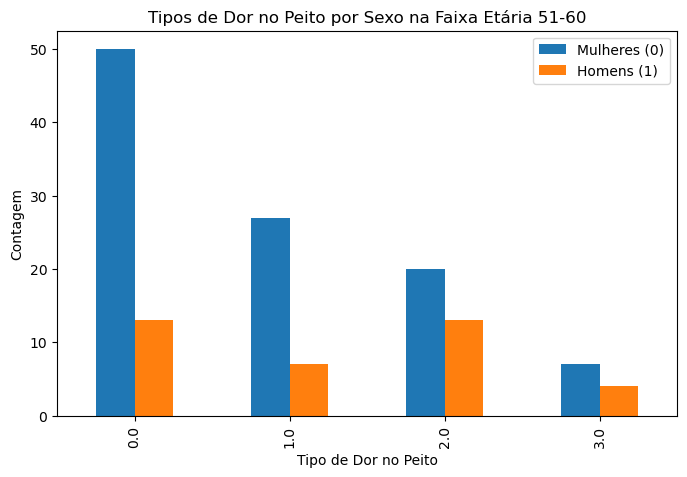

In [539]:
import matplotlib.pyplot as plt

faixa = '51-60'
dados_faixa = df[df['Faixa_Idade'] == faixa]

# Contar tipos de dor no peito por sexo
contagem = dados_faixa.groupby(['cp', 'sex']).size().unstack()

contagem.plot(kind='bar', figsize=(8,5))
plt.title(f'Tipos de Dor no Peito por Sexo na Faixa Etária {faixa}')
plt.xlabel('Tipo de Dor no Peito')
plt.ylabel('Contagem')
plt.legend(['Mulheres (0)', 'Homens (1)'])
plt.show()


Contagem absoluta:
sex  Homem  Mulher
cp                
0.0     50      13
1.0     27       7
2.0     20      13
3.0      7       4

Proporções (% dentro do sexo):
sex  Homem  Mulher
cp                
0.0   48.1    35.1
1.0   26.0    18.9
2.0   19.2    35.1
3.0    6.7    10.8


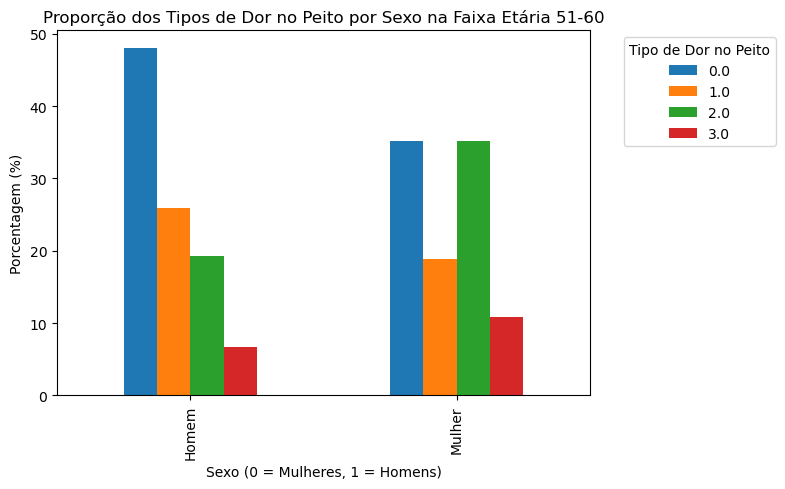

In [540]:
import pandas as pd
import matplotlib.pyplot as plt


faixa = '51-60'
df_faixa = df[df['Faixa_Idade'] == faixa]

# Conta o total por sexo para calcular as proporções
total_por_sexo = df_faixa.groupby('sex').size()

# Conta quantos para cada tipo de dor no peito por sexo
contagem = df_faixa.groupby(['cp', 'sex']).size().unstack(fill_value=0)

# Calcula a proporção dentro de cada sexo
proporcoes = contagem.div(total_por_sexo, axis=1) * 100  # em porcentagem

print("Contagem absoluta:")
print(contagem)
print("\nProporções (% dentro do sexo):")
print(proporcoes.round(1))


proporcoes.T.plot(kind='bar', figsize=(8,5))
plt.title(f'Proporção dos Tipos de Dor no Peito por Sexo na Faixa Etária {faixa}')
plt.xlabel('Sexo (0 = Mulheres, 1 = Homens)')
plt.ylabel('Porcentagem (%)')
plt.legend(title='Tipo de Dor no Peito', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [541]:
df[['age','trestbps','chol','thalach','oldpeak']].describe()


,age,trestbps,chol,thalach,oldpeak
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,53.845847,131.910299,242.516944,149.699668,1.022658
std,8.373396,16.413679,43.874960,21.215118,1.112916
min,29.000000,94.000000,126.000000,88.000000,0.000000
25%,48.000000,120.000000,213.600000,134.800000,0.000000
50%,54.000000,130.000000,239.000000,153.200000,0.640000
75%,59.000000,140.000000,269.000000,165.200000,1.600000
max,77.000000,200.000000,417.000000,202.000000,6.200000


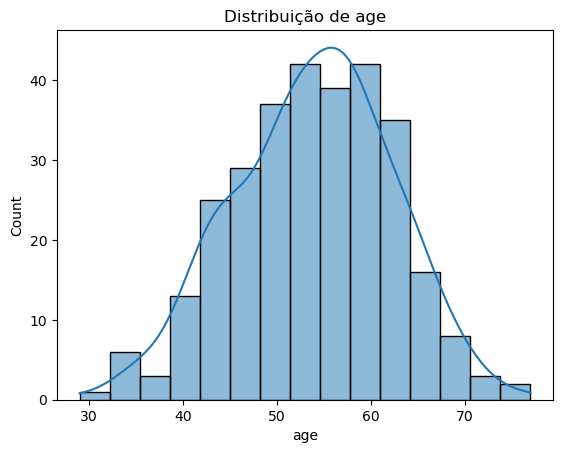

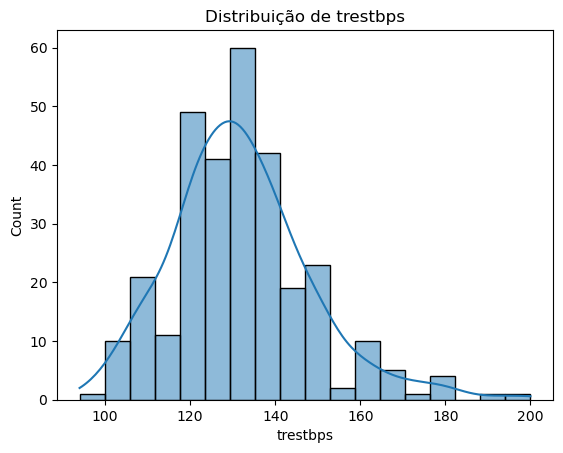

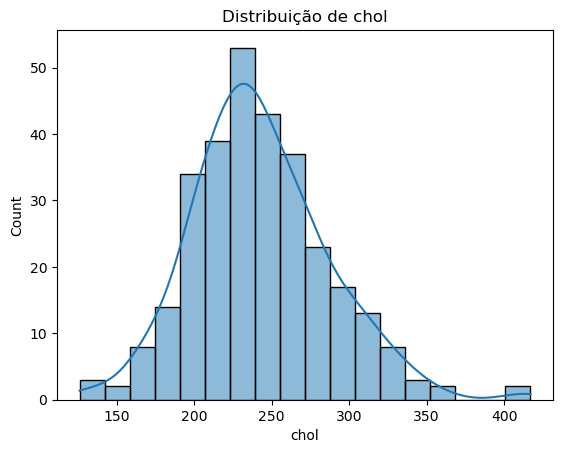

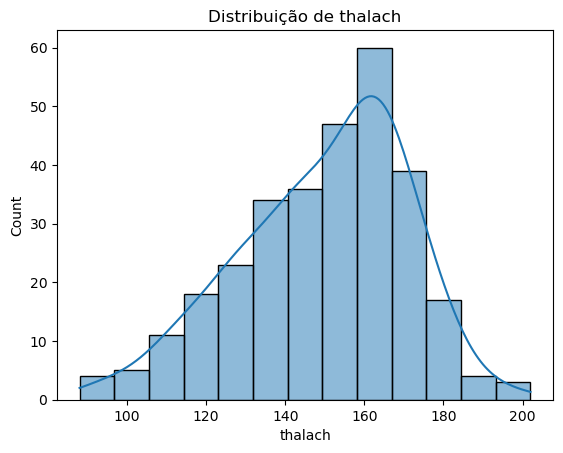

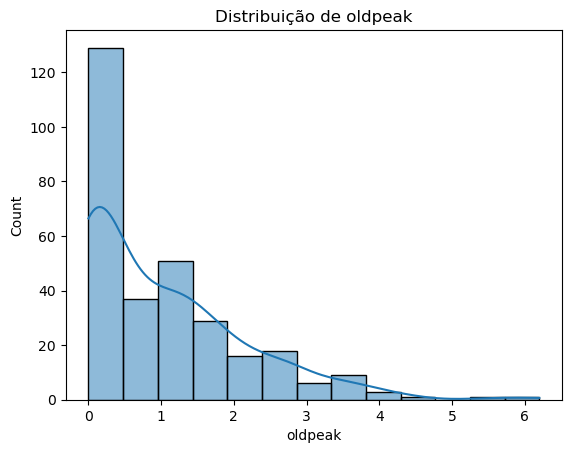

In [542]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['age','trestbps','chol','thalach','oldpeak']:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição de {col}')
    plt.show()


# Análise
* A distribuição de idades dos pacientes em nosso conjunto de dados revela que a maioria se concentra na faixa etária entre 50 e 60 anos. Essa concentração é clinicamente relevante, pois esta faixa etária é conhecida por apresentar maior incidência de problemas relacionados à saúde do coração.

* A pressão arterial se refere a força que o sangue exerce nas paredes das artérias quando é impulsionado pelo coração para ser levado a todo o corpo.

Em uma análise inicial dos dados de pressão arterial, focando especificamente na pressão sistólica, observamos as seguintes classificações de referência:

    Normal: Abaixo de 120 mmHg.
    Pré-hipertensão: Entre 120-139 mmHg.
    Hipertensão Estágio 1: Entre 140-159 mmHg.
    Hipertensão Estágio 2: Acima de 160 mmHg.

Ao analisar a distribuição da nossa amostra de pacientes, notamos que a grande maioria dos valores dos dados está concentrada na faixa entre 120 e 140 mmHg. Isso nos coloca majoritariamente nas categorias de pré-hipertensão e início da hipertensão estágio 1, que são, essencialmente, os estágios iniciais de um problema mais sério de saúde cardiovascular, indicando a necessidade de intervenção e monitoramento imediatos.

* Colesterol: A maior parte dos pacientes analisados apresenta Colesterol Total elevado, na faixa considerada limítrofe a alta (200 a 300 mg/dL).

Existe uma correlação a ser analisada: se esses pacientes, com esses níveis de colesterol, apresentam doença cardíaca, isso reforça a tese médica de que níveis elevados de colesterol total são um fator de risco significativo e estão associados a desfechos negativos (a presença da doença).

* A variável oldpeak representa a depressão do segmento ST observada durante o teste de esforço em relação ao repouso. Valores próximos de 0 indicam ausência de alteração significativa, enquanto valores maiores refletem maior nível de isquemia miocárdica, ou seja, um indício de menor oxigenação do músculo cardíaco durante o exercício.

Ao observar o histograma dessa variável, nota-se uma forte concentração de valores próximos de 0, com poucos casos apresentando valores mais altos (acima de 2). Essa distribuição assimétrica à direita sugere que a maioria dos pacientes do conjunto de dados não apresentou sinais de anormalidade cardíaca significativa, enquanto apenas uma pequena parcela apresentou valores que podem indicar condições mais graves.

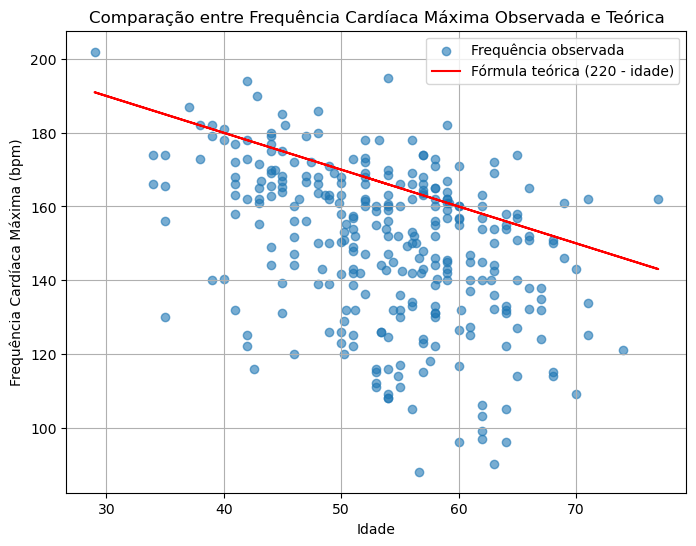

In [543]:
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que o seu DataFrame se chame df
# e que as colunas sejam 'age' e 'thalach'

# Calcula a frequência máxima teórica
df['max_teorica'] = 220 - df['age']

# Cria o gráfico
plt.figure(figsize=(8, 6))
plt.scatter(df['age'], df['thalach'], alpha=0.6, label='Frequência observada')
plt.plot(df['age'], df['max_teorica'], color='red', label='Fórmula teórica (220 - idade)')
plt.xlabel('Idade')
plt.ylabel('Frequência Cardíaca Máxima (bpm)')
plt.title('Comparação entre Frequência Cardíaca Máxima Observada e Teórica')
plt.legend()
plt.grid(True)
plt.show()


A variável thalach representa a frequência cardíaca máxima observada para cada indivíduo do conjunto de dados. Para verificar a coerência dos valores registrados, foi realizada uma comparação com a frequência cardíaca máxima teórica, obtida pela fórmula 220−idade. Essa análise exploratória permitiu observar o comportamento da frequência cardíaca em relação à idade, avaliando se os dados seguem o padrão esperado de diminuição da frequência máxima conforme o aumento da idade. Além disso, a comparação auxilia na identificação de possíveis outliers ou registros inconsistentes, contribuindo para a compreensão da distribuição e da qualidade dos dados.

<Axes: xlabel='oldpeak'>

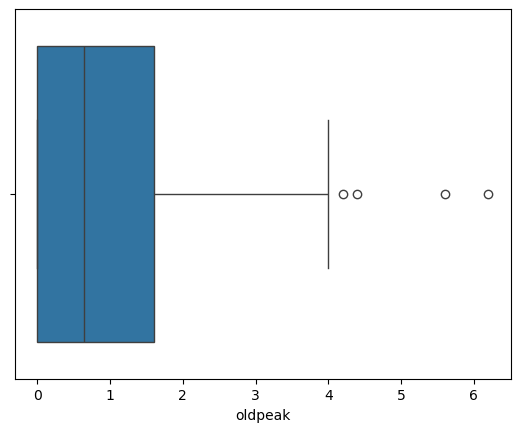

In [544]:
import seaborn as sns
sns.boxplot(x=df['oldpeak'])



<Axes: >

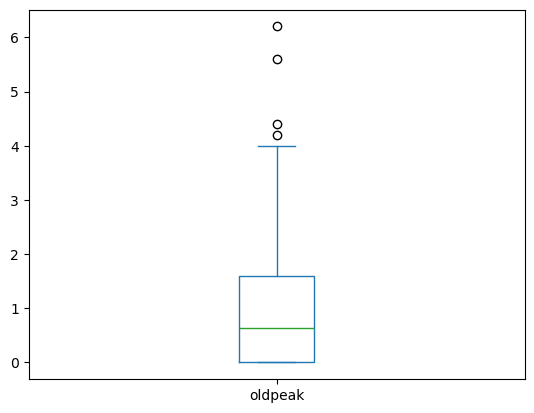

In [545]:
df['oldpeak'].plot.box()


In [546]:
Q1 = df['oldpeak'].quantile(0.25)
Q3 = df['oldpeak'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
df[df['oldpeak'] > limite_superior]


,index,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Faixa_Idade,max_teorica
6,6,62.8,Homem,0.0,114.0,261.2,0,0.0,140.0,0,4.4,0.0,3.0,1.0,0.0,61-70,157.2
13,13,51.0,Homem,0.0,140.0,298.0,0,1.0,122.0,1,4.2,1.0,3.0,3.0,0.0,51-60,169.0
51,51,55.0,Homem,0.0,146.8,217.0,0,1.0,111.0,0,5.6,1.0,1.0,3.0,0.0,51-60,165.0
63,63,62.0,Mulher,0.0,160.0,164.0,0,0.0,145.0,0,6.2,0.0,2.0,3.0,0.0,61-70,158.0


In [547]:
df['sex'].value_counts(normalize=True) * 100
df['cp'].value_counts()


cp
0.0    125
1.0     79
2.0     78
3.0     19
Name: count, dtype: int64

In [548]:
import altair as alt

alt.Chart(df).mark_bar().encode(
    x=alt.X('count()', title='Contagem'),
    y=alt.Y('cp:O', title='Tipo de dor no peito'),
    color='cp:N'
).properties(title='Distribuição de tipo de dor no peito')


/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

## Análise de dados do tipo Numérica discreta



/tmp/ipykernel_7053/836826528.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ca', data=df, palette='viridis')


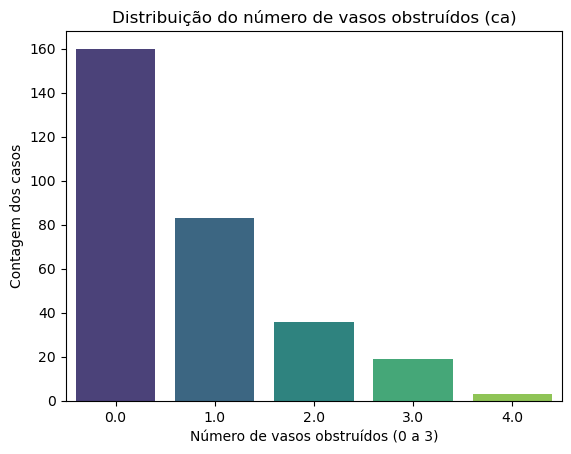

In [549]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='ca', data=df, palette='viridis')
plt.title('Distribuição do número de vasos obstruídos (ca)')
plt.xlabel('Número de vasos obstruídos (0 a 3)')
plt.ylabel('Contagem dos casos')
plt.show()


In [550]:
freq_ca = df['ca'].value_counts().sort_index()
percent_ca = df['ca'].value_counts(normalize=True).sort_index() * 100
pd.DataFrame({'Frequência Absoluta': freq_ca, 'Frequência Relativa (%)': percent_ca.round(2)})


,Frequência Absoluta,Frequência Relativa (%)
ca,,
0.0,160,53.16
1.0,83,27.57
2.0,36,11.96
3.0,19,6.31
4.0,3,1.00


In [551]:
df['ca'].describe()


count    301.000000
mean       0.744186
std        0.964887
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        4.000000
Name: ca, dtype: float64

A coluna `ca` representa quantos vasos principais (entre 0 e 3) mostraram obstração. Caso haja valores maiores isso pode indicar maior gravidade da doença coronariana.
Nesse caso, uma análise posterior pode ser feita relacionando com a coluna do colesterol e com a coluna que representa o tipo de dor no peito, para identificarmos possíveis relações entre essas variáveis.
* Com a estatística descritiva verificamos que a média está mais próxima de 0,ou seja, **a maioria com poucos vasos obstruídos**;  

Assim pela análise, a variável `ca` apresenta distribuição assimétrica, com a maioria dos pacientes possuindo poucos vasos obstruídos (valores próximos de 0). Pacientes com valores mais altos de ca são minoria, mas podem indicar casos de doença cardíaca mais grave. Essa tendência poderá ser confirmada explorando a relação entre ca e a variável-alvo `target`.

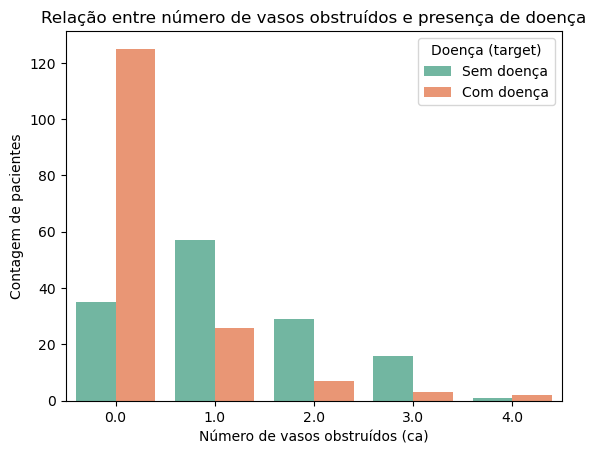

In [552]:
sns.countplot(x='ca', hue='target', data=df, palette='Set2')
plt.title('Relação entre número de vasos obstruídos e presença de doença')
plt.xlabel('Número de vasos obstruídos (ca)')
plt.ylabel('Contagem de pacientes')
plt.legend(title='Doença (target)', labels=['Sem doença', 'Com doença'])
plt.show()


Ao comparar `ca` com a variável-alvo (`target`), observou-se que muitas pessoas diagnosticadas com doença cardíaca (`target = 1`) também possuem `ca = 0`. Isso sugere que a presença de doença nem sempre está associada à obstrução detectável em grandes vasos, podendo envolver outros fatores cardíacos funcionais. Assim, `ca` isoladamente não distingue bem entre indivíduos saudáveis e doentes, mas pode ter importância combinada com outras variáveis clínicas.

/tmp/ipykernel_7053/86883878.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='oldpeak', data=df_sem_obstrucao, palette='coolwarm', ax=axes[0])


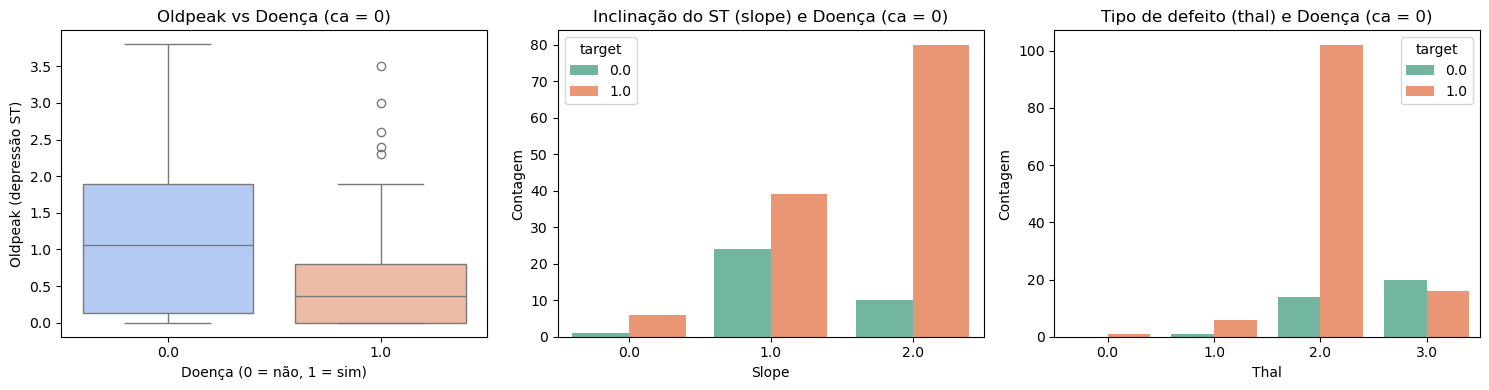

In [553]:
df_sem_obstrucao = df[df['ca'] == 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# oldpeak
sns.boxplot(x='target', y='oldpeak', data=df_sem_obstrucao, palette='coolwarm', ax=axes[0])
axes[0].set_title('Oldpeak vs Doença (ca = 0)')
axes[0].set_xlabel('Doença (0 = não, 1 = sim)')
axes[0].set_ylabel('Oldpeak (depressão ST)')

# slope
sns.countplot(x='slope', hue='target', data=df_sem_obstrucao, palette='Set2', ax=axes[1])
axes[1].set_title('Inclinação do ST (slope) e Doença (ca = 0)')
axes[1].set_xlabel('Slope')
axes[1].set_ylabel('Contagem')

# thal
sns.countplot(x='thal', hue='target', data=df_sem_obstrucao, palette='Set2', ax=axes[2])
axes[2].set_title('Tipo de defeito (thal) e Doença (ca = 0)')
axes[2].set_xlabel('Thal')
axes[2].set_ylabel('Contagem')

plt.tight_layout()
plt.show()


**Entre os que não têm obstrução nos vasos, quais fatores funcionais indicam doença?**

Para compreender por que muitos indivíduos com ca = 0 ainda apresentam diagnóstico positivo de doença, foram analisadas variáveis clínicas associadas à função cardíaca, como oldpeak , slope e thal.
Observou-se que indivíduos com valores 1 ou 2 de slope e com defeitos reversíveis (thal = 2) apresentam maior incidência de doença, mesmo sem obstrução visível nos grandes vasos. Esses achados sugerem que a detecção de anormalidades elétricas ou funcionais do coração também desempenha papel importante no diagnóstico, complementando as informações fornecidas por ca.

## Análise das variáveis do tipo categóricas nominais

No dataset são: `sex, cp, restecg, thal, terget`

/tmp/ipykernel_7053/559305797.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette='Set2', ax=ax[0])


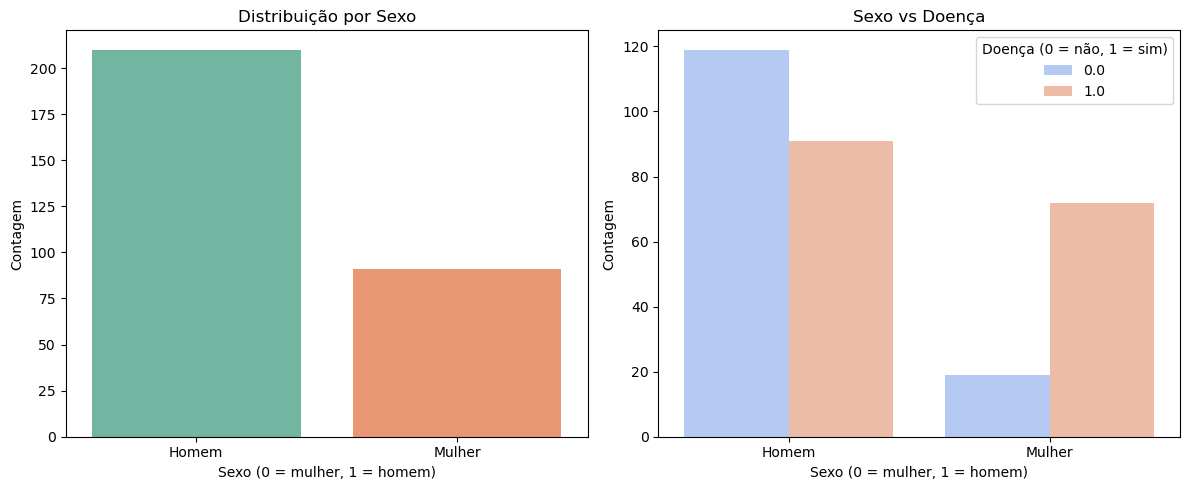

In [554]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Distribuição de sexos
sns.countplot(x='sex', data=df, palette='Set2', ax=ax[0])
ax[0].set_title('Distribuição por Sexo')
ax[0].set_xlabel('Sexo (0 = mulher, 1 = homem)')
ax[0].set_ylabel('Contagem')

# Relação entre sexo e presença de doença
sns.countplot(x='sex', hue='target', data=df, palette='coolwarm', ax=ax[1])
ax[1].set_title('Sexo vs Doença')
ax[1].set_xlabel('Sexo (0 = mulher, 1 = homem)')
ax[1].set_ylabel('Contagem')
ax[1].legend(title='Doença (0 = não, 1 = sim)')

plt.tight_layout()
plt.show()


In [555]:
# Agrupa por sexo e calcula a taxa de doença dentro de cada grupo
sex_stats = df.groupby('sex')['target'].mean()
sex_stats.index = sex_stats.index.map({0: 'Mulheres', 1: 'Homens'})
sex_stats = (
    df.groupby('sex')['target']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={'count': 'Total', 'sum': 'Com doença', 'mean': 'Proporção_doença'})
)

sex_stats['Proporção_doença'] = (sex_stats['Proporção_doença'] * 100).round(2)

sex_stats


,Total,Com doença,Proporção_doença
sex,,,
Homem,210,91.0,43.33
Mulher,91,72.0,79.12


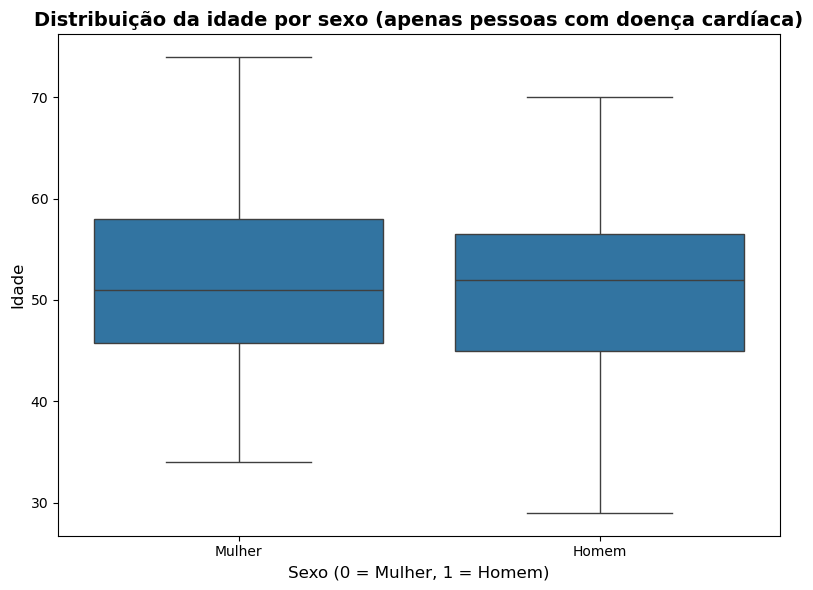

In [556]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtra apenas quem tem doença cardíaca
df_disease = df[df['target'] == 1].copy()

# Gráfico: distribuição das idades by sex for people with heart disease
plt.figure(figsize=(8, 6))
sns.boxplot(x='sex', y='age', data=df_disease)

plt.title('Distribuição da idade por sexo (apenas pessoas com doença cardíaca)', fontsize=14, weight='bold')
plt.xlabel('Sexo (0 = Mulher, 1 = Homem)', fontsize=12)
plt.ylabel('Idade', fontsize=12)
plt.xticks([0, 1], ['Mulher', 'Homem']) # Set the tick labels
plt.tight_layout()
plt.show()

A análise revelou que, embora o conjunto de dados apresente um número maior de homens, **a proporção de mulheres com doença cardíaca é superior**. No entanto, ao relacionar essa informação com a idade, observou-se que as **mulheres acometidas pela doença tendem a ser mais velhas**, enquanto os **homens manifestam a condição em idades mais jovens**. Esse comportamento sugere que a diferença de prevalência entre os sexos pode estar associada à faixa etária, **reforçando a hipótese de que as doenças cardíacas surgem mais tardiamente nas mulheres e de forma mais antecipada nos homens.**

/tmp/ipykernel_7053/1877696697.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cp', data=df, palette='viridis')


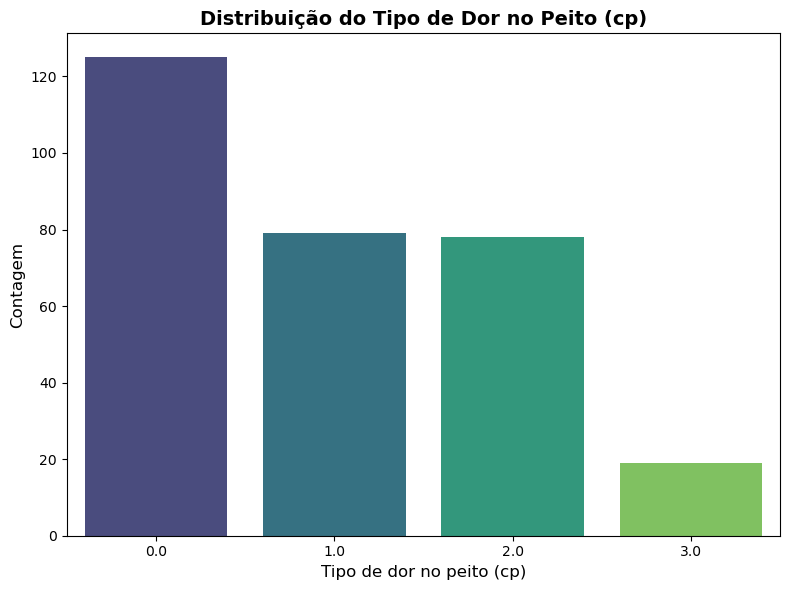

In [557]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(x='cp', data=df, palette='viridis')

plt.title('Distribuição do Tipo de Dor no Peito (cp)', fontsize=14, weight='bold')
plt.xlabel('Tipo de dor no peito (cp)', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.tight_layout()
plt.show()


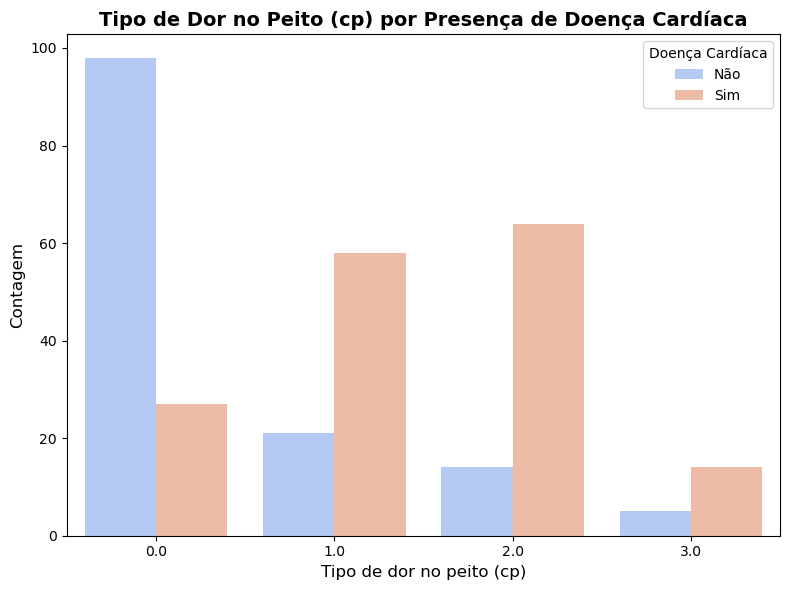

In [558]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(
    x='cp', hue='target', data=df, palette='coolwarm'
)

plt.title('Tipo de Dor no Peito (cp) por Presença de Doença Cardíaca', fontsize=14, weight='bold')
plt.xlabel('Tipo de dor no peito (cp)', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.legend(title='Doença Cardíaca', labels=['Não', 'Sim'])
plt.tight_layout()
plt.show()


A variável cp representa o tipo de dor no peito, variando de 0 (angina típica) até 3 (assintomático).
Ao analisar o conjunto de dados, observa-se que à medida que o valor de cp aumenta, também aumenta a proporção de indivíduos com doença cardíaca.
Ou seja, pessoas com cp = 0 tendem a não apresentar a doença, enquanto aquelas com cp = 2 e cp = 3 (dor não anginosa ou ausência de dor) têm maior probabilidade de diagnóstico positivo.

Esse padrão sugere que, neste dataset, a presença de sintomas típicos de dor no peito nem sempre indica maior risco, enquanto casos assintomáticos ou com dores atípicas estão mais associados à doença, possivelmente refletindo diagnósticos feitos em estágios mais avançados ou com base em outros fatores clínicos.

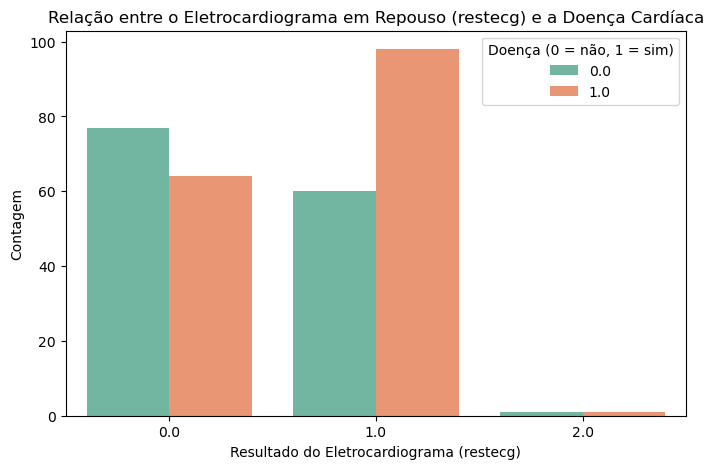

In [559]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(x='restecg', hue='target', data=df, palette='Set2')
plt.title('Relação entre o Eletrocardiograma em Repouso (restecg) e a Doença Cardíaca')
plt.xlabel('Resultado do Eletrocardiograma (restecg)')
plt.ylabel('Contagem')
plt.legend(title='Doença (0 = não, 1 = sim)')
plt.show()


In [560]:
# Calculando a proporção de doença em cada categoria de restecg
restecg_stats = df.groupby('restecg')['target'].agg(
    Total='count',
    Com_doenca='sum'
)
restecg_stats['Proporcao_doenca'] = (restecg_stats['Com_doenca'] / restecg_stats['Total']) * 100
print(restecg_stats)


         Total  Com_doenca  Proporcao_doenca
restecg                                     
0.0        141        64.0         45.390071
1.0        158        98.0         62.025316
2.0          2         1.0         50.000000


A análise da variável **restecg** (resultado do eletrocardiograma em repouso) mostra que a maioria dos indivíduos se enquadra nas categorias 0 e 1. Observa-se que pessoas com **restecg = 1**, indicando anormalidades no traçado do ECG, apresentam a **maior proporção de doença cardíaca aproximadamente 63%**, enquanto aquelas com **restecg = 0**, geralmente com ECG normal, têm uma proporção menor, cerca de 46%. Já o grupo com **restecg = 2**, associado a anormalidades mais específicas, é pequeno na amostra e apresenta uma proporção de 25%. Esses resultados sugerem que alterações detectadas no ECG em repouso estão associadas a maior probabilidade de presença de doença cardíaca.


In [561]:
import pandas as pd

contagem = {0: 0, 1: 0, 2: 0, 3: 0, 'NaN': 0, 'Outros': 0}

for val in df['thal']:
    if pd.isna(val):
        contagem['NaN'] += 1
    else:
        try:
            v = int(val)  # converte float para int, ex: 1.0 -> 1
            if v in contagem:
                contagem[v] += 1
            else:
                contagem['Outros'] += 1
        except:
            contagem['Outros'] += 1

print("Contagem dos valores na coluna 'thal':")
for chave, qtd in contagem.items():
    print(f"Valor {chave}: {qtd} linhas")


Contagem dos valores na coluna 'thal':
Valor 0: 1 linhas
Valor 1: 16 linhas
Valor 2: 174 linhas
Valor 3: 110 linhas
Valor NaN: 0 linhas
Valor Outros: 0 linhas


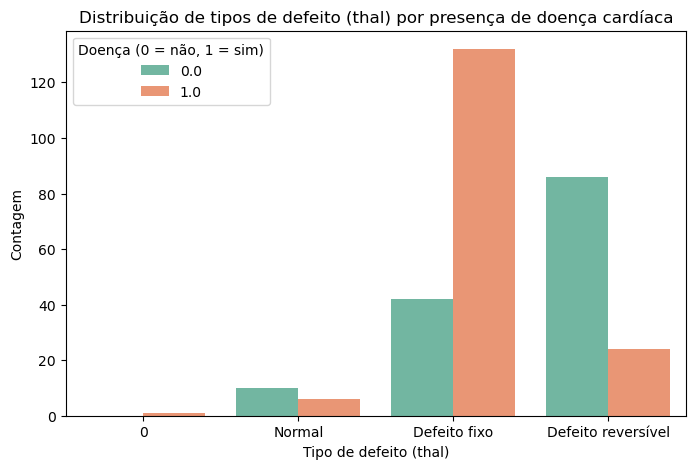

In [562]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapear valores para nomes claros
thal_labels = {0: '0', 1: 'Normal', 2: 'Defeito fixo', 3: 'Defeito reversível'}
df['thal_label'] = df['thal'].map(thal_labels)

plt.figure(figsize=(8,5))
sns.countplot(x='thal_label', hue='target', data=df, palette='Set2', order=['0', 'Normal', 'Defeito fixo', 'Defeito reversível'])

plt.title('Distribuição de tipos de defeito (thal) por presença de doença cardíaca')
plt.xlabel('Tipo de defeito (thal)')
plt.ylabel('Contagem')
plt.legend(title='Doença (0 = não, 1 = sim)')
plt.show()


In [563]:
tabela_thal = df.groupby('thal_label').agg(
    Total=('target', 'count'),
    Com_doenca=('target', 'sum')
)
tabela_thal['Proporcao_doenca'] = (tabela_thal['Com_doenca'] / tabela_thal['Total'] * 100).round(2)

print(tabela_thal)


                    Total  Com_doenca  Proporcao_doenca
thal_label                                             
0                       1         1.0            100.00
Defeito fixo          174       132.0             75.86
Defeito reversível    110        24.0             21.82
Normal                 16         6.0             37.50


A variável thal refere-se ao tipo de defeito observado no exame de tálio, que é um método utilizado para detectar problemas cardíacos através da perfusão do miocárdio. No dataset, essa variável é categorizada em quatro grupos:

* **Normal**: Ausência de defeito na perfusão (18 registros)

* **Defeito fixo**: Áreas do coração com perfusão permanentemente comprometida, indicando possível tecido cicatricial (165 registros)

* **Defeito reversível**: Áreas com perfusão reduzida apenas durante o estresse, sugerindo isquemia transitória (117 registros)

Analisando a relação com a presença de doença cardíaca:

* A maior proporção de pacientes com doença está no grupo de **defeito fixo (78,18%)**, o que é esperado, pois essa categoria indica danos permanentes no tecido cardíaco.

* O grupo de **defeito reversível** apresenta uma proporção de doença significativamente menor (23,93%), indicando que nem todos com este tipo de defeito possuem um diagnóstico confirmado de doença cardíaca.

* Curiosamente, o grupo classificado como normal também apresenta uma proporção de doença de 33,33%, o que pode indicar diagnósticos clínicos baseados em outros critérios ou possíveis limitações no exame de tálio.

Esses resultados ressaltam a importância da variável thal na avaliação diagnóstica, especialmente a presença de defeitos fixos que estão fortemente associados à doença cardíaca no conjunto de dados analisado. Ao mesmo tempo, evidencia que a variável, embora relevante, deve ser interpretada junto com outros indicadores clínicos para um diagnóstico mais completo. Já os casos da categoria 0, sugerem ser outliers no conjunto.

     Total  Com_doenca  Proporcao_doenca
fbs                                     
0      263       144.0         54.752852
1       38        19.0         50.000000


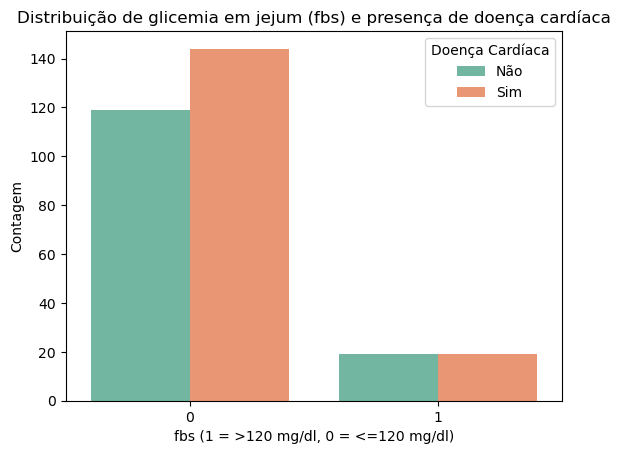

In [564]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tabela de frequência e proporção
tabela_fbs = df.groupby('fbs')['target'].agg(['count', 'sum'])
tabela_fbs.columns = ['Total', 'Com_doenca']
tabela_fbs['Proporcao_doenca'] = (tabela_fbs['Com_doenca'] / tabela_fbs['Total']) * 100
print(tabela_fbs)

# Gráfico
sns.countplot(x='fbs', hue='target', data=df, palette='Set2')
plt.title('Distribuição de glicemia em jejum (fbs) e presença de doença cardíaca')
plt.xlabel('fbs (1 = >120 mg/dl, 0 = <=120 mg/dl)')
plt.ylabel('Contagem')
plt.legend(title='Doença Cardíaca', labels=['Não', 'Sim'])
plt.show()


A variável fbs representa o nível de glicose no sangue em jejum, sendo codificada como:

* 0: menor ou igual a 120 mg/dl

* 1: maior que 120 mg/dl

Essa variável é utilizada como um indicador de possíveis distúrbios metabólicos, como a diabetes, que pode estar relacionada a um maior risco de doenças cardíacas.

Na análise, observa-se que indivíduos com níveis normais de glicose (fbs = 0) apresentam uma proporção de doença cardíaca de aproximadamente 54,9%, enquanto aqueles com níveis elevados (fbs = 1) possuem uma proporção levemente menor, de 51,1%.
Isso sugere que, **neste conjunto de dados**, o **nível de glicose em jejum não se mostrou um fator determinante isolado** na presença de doença cardíaca, já que as proporções de ocorrência são próximas. Contudo, essa variável pode ainda contribuir **em combinação com outras características clínicas**, como pressão arterial e colesterol, para indicar risco cardiovascular.

/tmp/ipykernel_7053/3088116464.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Doença Cardíaca', data=df, palette='Set2')


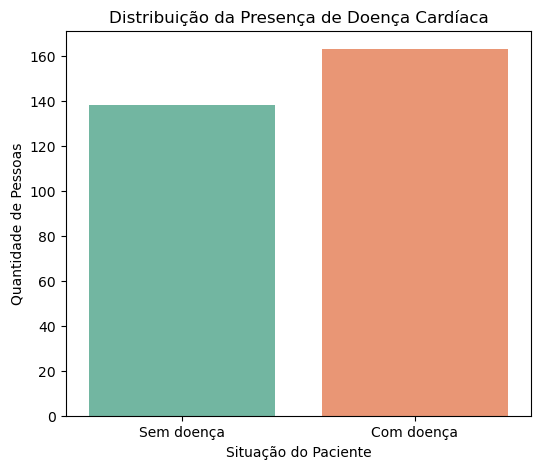

In [565]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mapeando para nomes mais compreensíveis
df['Doença Cardíaca'] = df['target'].map({0: 'Sem doença', 1: 'Com doença'})

# Gráfico de contagem
plt.figure(figsize=(6, 5))
sns.countplot(x='Doença Cardíaca', data=df, palette='Set2')
plt.title('Distribuição da Presença de Doença Cardíaca')
plt.xlabel('Situação do Paciente')
plt.ylabel('Quantidade de Pessoas')
plt.show()


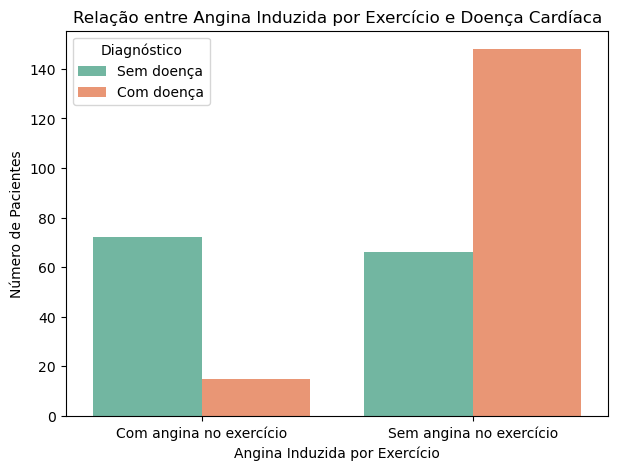

In [566]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mapeando para tornar os rótulos mais compreensíveis
df['Angina_exercicio'] = df['exang'].map({0: 'Sem angina no exercício', 1: 'Com angina no exercício'})
df['Doença Cardíaca'] = df['target'].map({0: 'Sem doença', 1: 'Com doença'})

plt.figure(figsize=(7, 5))
sns.countplot(x='Angina_exercicio', hue='Doença Cardíaca', data=df, palette='Set2')

plt.title('Relação entre Angina Induzida por Exercício e Doença Cardíaca')
plt.xlabel('Angina Induzida por Exercício')
plt.ylabel('Número de Pacientes')
plt.legend(title='Diagnóstico')
plt.show()


In [567]:
# Contagem de cada valor de exang
print(df['exang'].value_counts())

# Contagem cruzada entre exang e target
print(pd.crosstab(df['exang'], df['target'], margins=True))


exang
0    214
1     87
Name: count, dtype: int64
target  0.0  1.0  All
exang                
0        66  148  214
1        72   15   87
All     138  163  301


A variável **angina induzida por exercício (exang)** indica se o paciente apresentou dor no peito durante esforço físico (`1` para sim e `0` para não). Embora se espere que pacientes com angina induzida por exercício tenham maior incidência de doença cardíaca, a análise dos dados mostrou que muitos pacientes com doença cardíaca não apresentaram angina durante o exercício.

Isso evidencia que a angina induzida por exercício não é o único sintoma ou indicador de doença cardíaca, refletindo a complexidade clínica da doença e a variedade de suas manifestações. Portanto, a ausência de angina durante o exercício não exclui a possibilidade de diagnóstico positivo para doença cardíaca, reforçando a importância de uma avaliação clínica abrangente.

Além das considerações clínicas, não se pode descartar a possibilidade de inconsistências ou erros no dataset original, como codificações incorretas ou registros incompletos, que podem afetar a interpretação da variável **angina induzida por exercício (exang)**. Por isso, é importante tratar essa variável com cautela e, se possível, validar os dados com outras fontes ou informações clínicas complementares.

## **Conclusão da Análise Exploratória**

Nesta análise exploratória do dataset de doenças cardíacas, foram investigadas diversas variáveis de diferentes tipos (numéricas contínuas, discretas, categóricas, binárias e ordinais) em relação à presença ou ausência de doença cardíaca.

Os principais achados incluem:

* **Idade e sexo**: Observou-se que a proporção de mulheres com doença cardíaca é maior que a dos homens, porém as mulheres tendem a desenvolver a doença em idades mais avançadas, enquanto os homens apresentam diagnóstico em faixas etárias mais jovens.

* **Tipo de dor no peito (cp)**: Tipos de dor classificados como angina atípica, dor não anginosa e assintomática estão mais associados à presença de doença cardíaca, enquanto a angina típica aparece mais em pacientes sem doença, indicando uma relação relevante dessa variável com o diagnóstico.

* **Eletrocardiograma em repouso (restecg) e tipo de defeito no tálio (thal)**  mostraram correlações significativas com a presença da doença cardíaca. Em especial, a variável thal demonstrou que pacientes com defeito fixo possuem maior prevalência de doença (78%), enquanto os com defeito reversível apresentam uma proporção menor (24%). Pacientes com exame normal ainda apresentaram uma proporção considerável de diagnóstico (33%), o que sugere a necessidade de interpretação cuidadosa em conjunto com outras variáveis clínicas.

* **Glicemia em jejum (fbs) e angina induzida por exercício (exang)** mostraram resultados que indicam a necessidade de cautela na interpretação, pois apresentaram padrões não totalmente alinhados às expectativas clínicas, possivelmente por características específicas da amostra ou limitações do dataset.

* **Variáveis como pressão arterial, colesterol e oldpeak** indicam tendências esperadas, mas sem correlações muito fortes com a presença da doença, sugerindo que isoladamente podem não ser bons preditores.

Adicionalmente, observou-se a presença de categorias pouco frequentes ou dados ausentes em algumas variáveis, reforçando a importância de um pré-processamento cuidadoso para garantir qualidade e consistência nos dados utilizados para modelagem.

Por fim, esta análise exploratória fornece uma base sólida para entender o comportamento das variáveis e suas relações com a doença cardíaca, orientando as próximas etapas de modelagem e validação. Também destaca a importância de considerar possíveis limitações e peculiaridades do conjunto de dados para uma interpretação mais precisa.



# Modelos de classificação para `target`:

Trata-se de uma classificação binária, então podemos fazer diversos modelos, aqui trataremos desses:
- Regressão Linear
- LDA
- QDA
- Regressão Logística
- KNN
- SVM
- Rede Neural

Por fim faremos a comparação fiel entre os modelos e qual seria mais adequado para essa devida tarefa.

**A Pipeline que utilizaremos para o modelo será a seguinte:**

- Criaremos um treino test split geral que será utilizado em todos os modelos
- Para cada modelo faremos uma função que recebe o data_set e fitta o modelo
- Utilizaremos o treino geral para treinar hiper-parâmetros através de um **cross_validation**
- Utilizaremos o teste geral para comparar todos os modelos ao final

In [568]:
# Imports iniciais

import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

Esse seram nossos conjuntos gerais para o **pipeline**

In [569]:
X = heart_imputed.drop(["target","index"], axis=1)
y = heart_imputed["target"]

# Criando as variáveis Dummies para colunas categóricas
categorical_cols = ['cp', 'thal', 'slope', 'restecg', "ca"]
categorical_cols = [c for c in categorical_cols if c in X.columns]
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

scalizer = StandardScaler()
X = pd.DataFrame(scalizer.fit_transform(X), columns=X.columns)

X_const = sm.add_constant(X) # aciciona constante para o intercepto

# Dividindo treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_const, y, test_size=0.3, random_state=200, stratify=y)


### Regressão Linear (Classificação)

- A ideia da utilizaçao de regressão linear para classificação é tentar prever a variável alvo como uma variável categórica alvo como uma variável contínua e usar um limiar a partir do qual classificaremos o alvo como categórico. Se temos duas classes para prever, uma aproximação:

In [570]:
heart_ds = heart_imputed # Apenas renomeando o nosso Dataset
X = heart_ds.drop(["target","index"], axis=1)
y = heart_ds["target"]

# Criando as variáveis Dummies para colunas categóricas
categorical_cols = ['cp', 'thal', 'slope', 'restecg', "ca"]
categorical_cols = [c for c in categorical_cols if c in X.columns]
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

scalizer = StandardScaler()
X = pd.DataFrame(scalizer.fit_transform(X), columns=X.columns)

X_const = sm.add_constant(X) # aciciona constante para o intercepto

# Dividindo treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_const, y, test_size=0.3, random_state=200, stratify=y)

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)


OLS (apenas diagnóstico) - R² e summary:
R² (train): 0.605
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     13.69
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           9.71e-28
Time:                        09:16:46   Log-Likelihood:                -54.216
No. Observations:                 210   AIC:                             152.4
Df Residuals:                     188   BIC:                             226.1
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

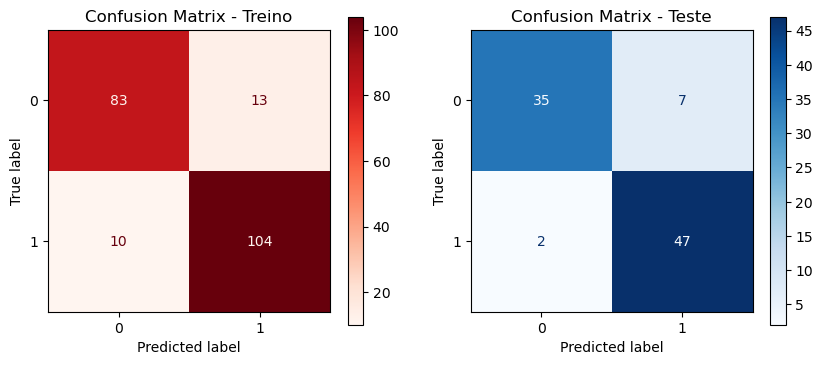

=== MÉTRICAS (Treino) ===
Acurácia:     0.890
Precisão:     0.889
Recall:       0.912

=== MÉTRICAS (Teste) ===
Acurácia:     0.901
Precisão:     0.870
Recall:       0.959


(0.9010989010989011, 0.8703703703703703, 0.9591836734693877)

In [571]:
# Dividindo o Dataset em vetor y e Matriz X

def Regressao_Linear_(df = heart_ds, threshold = 0.5, verbose = True, varsout = [], treino_test = [X_train,X_test,y_train,y_test]):
    if not treino_test:
        X = df.drop(["target","index"], axis=1)
        y = heart_ds["target"]

        # Criando as variáveis Dummies para colunas categóricas
        categorical_cols = ['cp', 'thal', 'slope', 'restecg', "ca"]
        categorical_cols = [c for c in categorical_cols if c in X.columns]
        if len(categorical_cols) > 0:
            X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

        if varsout:
            X = X.drop(varsout, axis = 1)

        # Colocando todos os dados na mesma escala
        # Importante para métodos de regularização e melhora na estabilidade dos coeficientes
        scalizer = StandardScaler()
        X = pd.DataFrame(scalizer.fit_transform(X), columns=X.columns)

        X_const = sm.add_constant(X) # aciciona constante para o intercepto

        # Dividindo treino e teste
        X_train, X_test, y_train, y_test = train_test_split(X_const, y, test_size=0.3, random_state=200, stratify=y)
        X_train = X_train.astype(float)
        X_test = X_test.astype(float)
        y_train = y_train.astype(float)
        y_test = y_test.astype(float)
        X_train = X_train.reset_index(drop=True)
        y_train = y_train.reset_index(drop=True)

    else:
        X_train, X_test, y_train, y_test = treino_test

    model_ols = sm.OLS(y_train, X_train).fit()
    print("OLS (apenas diagnóstico) - R² e summary:")
    print(f"R² (train): {model_ols.rsquared:.3f}")
    print(model_ols.summary())
    print("\nmatriz de covariância dos coeficientes:")
    print(model_ols.cov_params())

    y_pred_train = model_ols.predict(X_train)
    y_pred_test  = model_ols.predict(X_test)

    y_pred_train = np.where(y_pred_train > threshold, 1, 0)
    y_pred_test  = np.where(y_pred_test  > threshold, 1, 0)

    for i in range(len(y_pred_train)):
        if y_pred_train[i] <= threshold:
            y_pred_train[i] = 0
        else:
            y_pred_train[i] = 1

    if verbose:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        cm = confusion_matrix(y_train, y_pred_train)
        cm_display_train = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        cm_display_train.plot(cmap=plt.cm.Reds, ax=axes[0])
        axes[0].set_title("Confusion Matrix - Treino")

        for i in range(len(y_pred_test)):
            if y_pred_test[i] <= 0.5:
                y_pred_test[i] = 0
            else:
                y_pred_test[i] = 1

        cm = confusion_matrix(y_test, y_pred_test)
        cm_display_test = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        cm_display_test.plot(cmap=plt.cm.Blues, ax=axes[1])
        axes[1].set_title("Confusion Matrix - Teste")
        plt.show()

    # --- Métricas de Treino ---
    acc_train = accuracy_score(y_train, y_pred_train)
    prec_train = precision_score(y_train, y_pred_train)
    rec_train = recall_score(y_train, y_pred_train)

    if verbose:

        print("=== MÉTRICAS (Treino) ===")
        print(f"Acurácia:     {acc_train:.3f}")
        print(f"Precisão:     {prec_train:.3f}")
        print(f"Recall:       {rec_train:.3f}\n")

    # --- Métricas de Teste ---
    acc_test = accuracy_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)
    rec_test = recall_score(y_test, y_pred_test)

    if verbose:

        print("=== MÉTRICAS (Teste) ===")
        print(f"Acurácia:     {acc_test:.3f}")
        print(f"Precisão:     {prec_test:.3f}")
        print(f"Recall:       {rec_test:.3f}")

    return acc_test, prec_test, rec_test

# Apenas um exemplo
Regressao_Linear_()

Após fazer a regressão linear, temos que otimizá-la de um jeito que duas coisas sejam obtidas

- Recall seja maximizado (não queremos que pessoas doentes sejam classificadas como saudáveis)
- O modelo mantenha uma acurácia mínima (já que se não precisasse, o problema era simples, era só classificar todos como doentes)

Para isso faremos um treinamento usando os dados de treino para escolher um threshold

In [572]:
class Regressao_Linear_Model:
    def __init__(self, X_train, y_train, vars_in=None):
 
        X = X_train.copy()
        if vars_in is not None:
            X = X.loc[:, X.columns.isin(vars_in)]

        X = X.loc[:, ~X.columns.duplicated()]
        X_const = sm.add_constant(X, has_constant='add')

        self.model = sm.OLS(y_train, X_const).fit()
        self.columns = X_const.columns

    def predict(self, X):

        X = X.copy()
        X = X.loc[:, ~X.columns.duplicated()]
        X_const = sm.add_constant(X, has_constant='add')
        X_const = X_const.reindex(columns=self.columns, fill_value=0)
        y_pred = self.model.predict(X_const)
        return np.clip(y_pred.values if hasattr(y_pred, 'values') else y_pred, 0, 1)





In [573]:
from sklearn.model_selection import StratifiedKFold


def training_thresholds(model_class, X_train, y_train, vars_in=None, acc_min=0.9, n_splits=5):
    thresholds = np.linspace(0, 1, 101)
    melhor_threshold = None
    melhor_recall = -1
    melhor_acc = -1  

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for t in thresholds:
        acc_list, rec_list = [], []

        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[train_idx].reset_index(drop=True), X_train.iloc[val_idx].reset_index(drop=True)
            y_tr, y_val = y_train.iloc[train_idx].reset_index(drop=True), y_train.iloc[val_idx].reset_index(drop=True)

            # Treina modelo no fold
            model = model_class(X_tr, y_tr, vars_in=vars_in)

            # Predição contínua
            y_pred_val = model.predict(X_val)
            y_val_array = y_val.values if hasattr(y_val, 'values') else y_val

            # Threshold
            y_pred_bin = (y_pred_val >= t).astype(int)

            # Métricas
            acc = accuracy_score(y_val_array, y_pred_bin)
            rec = recall_score(y_val_array, y_pred_bin)
            acc_list.append(acc)
            rec_list.append(rec)

        # Média dos folds
        acc_mean = np.mean(acc_list)
        rec_mean = np.mean(rec_list)

        # Atualiza melhor threshold
        if acc_mean >= acc_min and rec_mean > melhor_recall:
            melhor_threshold = t
            melhor_recall = rec_mean
            melhor_acc = acc_mean

    # Resultado final
    if melhor_threshold is not None:
        print(f"\nThreshold ótimo encontrado (CV): {melhor_threshold:.2f}")
        print(f"Acurácia média: {melhor_acc:.3f}")
        print(f"Recall médio máximo (Acurácia ≥ {acc_min:.2f}): {melhor_recall:.3f}")
    else:
        print("\nNenhum threshold atingiu a acurácia mínima desejada.")

    return melhor_threshold





training_thresholds(Regressao_Linear_Model,X_train,y_train,acc_min = 0.85)



Threshold ótimo encontrado (CV): 0.44
Acurácia média: 0.852
Recall médio máximo (Acurácia ≥ 0.85): 0.921


0.44

Achamos um Treshold ótimo de 0.44, então setaremos como o Treshold da nossa regressão_linear

Para seleção de Variáveis da nossa regressão linear faremos dois métodos:

- Backward Selection
- Regularização com Lasso

E verificaremos se conseguimos um modelo bom com menos variáveis

**Lasso :**

Melhor alpha (λ) encontrado: 0.011528

Coeficientes não nulos (variáveis selecionadas):
age                  -> -0.0165
sex                  -> -0.0869
chol                 -> -0.0261
exang                -> -0.0676
oldpeak              -> -0.1125
cp_1.0               -> 0.0832
cp_2.0               -> 0.1006
cp_3.0               -> 0.0632
thal_2.0             -> 0.0513
thal_3.0             -> -0.0243
slope_1.0            -> -0.0495
slope_2.0            -> 0.0134
ca_1.0               -> -0.0591
ca_2.0               -> -0.0496
ca_3.0               -> -0.0273


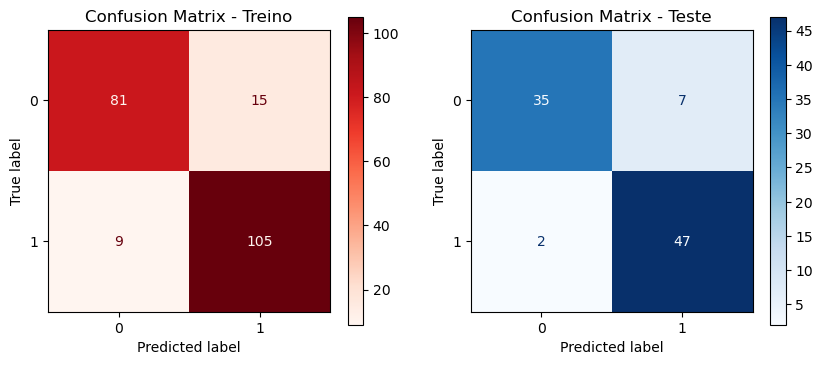

=== MÉTRICAS (Treino) ===
Acurácia: 0.886
Precisão: 0.875
Recall:   0.921

=== MÉTRICAS (Teste) ===
Acurácia: 0.901
Precisão: 0.870
Recall:   0.959


In [677]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def Lasso_Regression_(X_train, y_train, X_test=None, y_test=None, cv=10, threshold=0.5, verbose=True):

    
    # LassoCV com CV interno
    lasso_model = LassoCV(cv=cv, random_state=42, n_jobs=-1)
    lasso_model.fit(X_train, y_train)
    
    if verbose:
        print(f"Melhor alpha (λ) encontrado: {lasso_model.alpha_:.6f}")
        print("\nCoeficientes não nulos (variáveis selecionadas):")
        for name, coef in zip(X_train.columns, lasso_model.coef_):
            if coef != 0:
                print(f"{name:20s} -> {coef:.4f}")
    
    # Predições
    y_pred_train = (lasso_model.predict(X_train) >= threshold).astype(int)
    
    if X_test is not None and y_test is not None:
        y_pred_test = (lasso_model.predict(X_test) >= threshold).astype(int)
    
    # Matrizes de confusão
    if verbose and X_test is not None and y_test is not None:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        
        cm_train = confusion_matrix(y_train, y_pred_train)
        ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=[0, 1]).plot(cmap=plt.cm.Reds, ax=axes[0])
        axes[0].set_title("Confusion Matrix - Treino")
        
        cm_test = confusion_matrix(y_test, y_pred_test)
        ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[0, 1]).plot(cmap=plt.cm.Blues, ax=axes[1])
        axes[1].set_title("Confusion Matrix - Teste")
        
        plt.show()
    
    # Métricas
    acc_train = accuracy_score(y_train, y_pred_train)
    prec_train = precision_score(y_train, y_pred_train)
    rec_train = recall_score(y_train, y_pred_train)
    
    if X_test is not None and y_test is not None:
        acc_test = accuracy_score(y_test, y_pred_test)
        prec_test = precision_score(y_test, y_pred_test)
        rec_test = recall_score(y_test, y_pred_test)
    else:
        acc_test = prec_test = rec_test = None
    
    if verbose:
        print("=== MÉTRICAS (Treino) ===")
        print(f"Acurácia: {acc_train:.3f}")
        print(f"Precisão: {prec_train:.3f}")
        print(f"Recall:   {rec_train:.3f}")
        
        if X_test is not None and y_test is not None:
            print("\n=== MÉTRICAS (Teste) ===")
            print(f"Acurácia: {acc_test:.3f}")
            print(f"Precisão: {prec_test:.3f}")
            print(f"Recall:   {rec_test:.3f}")
    
    return lasso_model, (acc_train, prec_train, rec_train), (acc_test, prec_test, rec_test) if X_test is not None else None

lasso_model, treino_metrics, teste_metrics = Lasso_Regression_(X_train, y_train, X_test, y_test, cv=10, threshold=0.5)


Veja que Lasso não zerou nenhuma variável, logo como método de simplificar o modelo não funcionou.

**Backward Selection :**

Fold 1: Removendo 'ca_4.0' (p-valor = 0.908)
Fold 1: Removendo 'thal_1.0' (p-valor = 0.892)
Fold 1: Removendo 'restecg_2.0' (p-valor = 0.760)
Fold 1: Removendo 'slope_2.0' (p-valor = 0.592)
Fold 1: Removendo 'thal_3.0' (p-valor = 0.554)
Fold 1: Removendo 'restecg_1.0' (p-valor = 0.417)
Fold 1: Removendo 'thalach' (p-valor = 0.321)
Fold 1: Removendo 'age' (p-valor = 0.445)
Fold 1: Removendo 'fbs' (p-valor = 0.267)
Fold 1: Removendo 'trestbps' (p-valor = 0.201)
Fold 1: Removendo 'ca_3.0' (p-valor = 0.181)


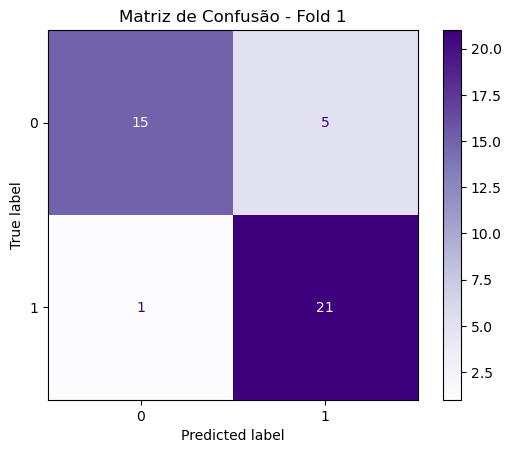

Fold 1 - Acc: 0.857 | Prec: 0.808 | Rec: 0.955 | F1: 0.875

Fold 2: Removendo 'ca_4.0' (p-valor = 0.915)
Fold 2: Removendo 'fbs' (p-valor = 0.825)
Fold 2: Removendo 'slope_2.0' (p-valor = 0.680)
Fold 2: Removendo 'trestbps' (p-valor = 0.697)
Fold 2: Removendo 'restecg_1.0' (p-valor = 0.610)
Fold 2: Removendo 'thal_1.0' (p-valor = 0.564)
Fold 2: Removendo 'thal_3.0' (p-valor = 0.897)
Fold 2: Removendo 'restecg_2.0' (p-valor = 0.433)
Fold 2: Removendo 'age' (p-valor = 0.346)
Fold 2: Removendo 'exang' (p-valor = 0.180)
Fold 2: Removendo 'ca_3.0' (p-valor = 0.162)
Fold 2: Removendo 'thalach' (p-valor = 0.177)
Fold 2: Removendo 'ca_1.0' (p-valor = 0.122)
Fold 2: Removendo 'ca_2.0' (p-valor = 0.253)


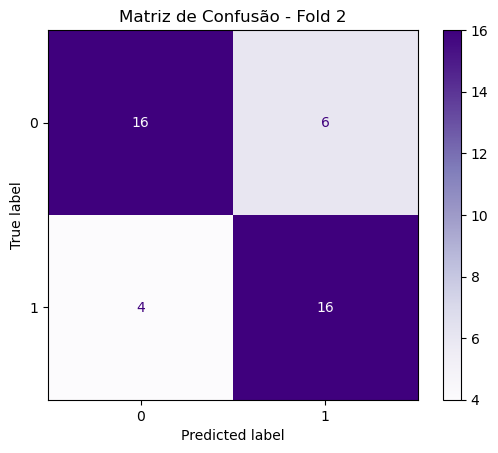

Fold 2 - Acc: 0.762 | Prec: 0.727 | Rec: 0.800 | F1: 0.762

Fold 3: Removendo 'ca_4.0' (p-valor = 0.998)
Fold 3: Removendo 'restecg_2.0' (p-valor = 0.971)
Fold 3: Removendo 'trestbps' (p-valor = 0.960)
Fold 3: Removendo 'slope_2.0' (p-valor = 0.692)
Fold 3: Removendo 'thalach' (p-valor = 0.625)
Fold 3: Removendo 'fbs' (p-valor = 0.514)
Fold 3: Removendo 'thal_1.0' (p-valor = 0.564)
Fold 3: Removendo 'thal_3.0' (p-valor = 0.937)
Fold 3: Removendo 'restecg_1.0' (p-valor = 0.473)
Fold 3: Removendo 'chol' (p-valor = 0.384)
Fold 3: Removendo 'ca_3.0' (p-valor = 0.184)
Fold 3: Removendo 'ca_2.0' (p-valor = 0.131)
Fold 3: Removendo 'exang' (p-valor = 0.072)
Fold 3: Removendo 'age' (p-valor = 0.067)


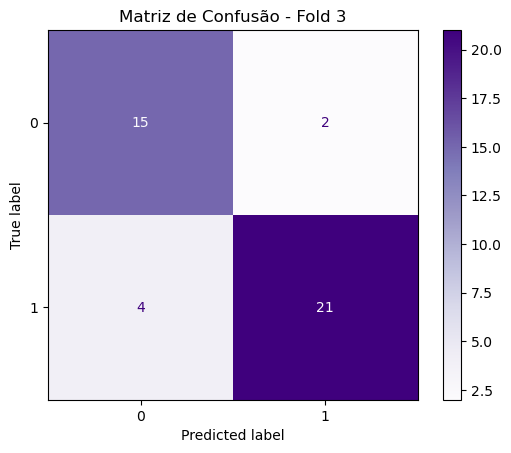

Fold 3 - Acc: 0.857 | Prec: 0.913 | Rec: 0.840 | F1: 0.875

Fold 4: Removendo 'ca_4.0' (p-valor = 0.958)
Fold 4: Removendo 'slope_2.0' (p-valor = 0.953)
Fold 4: Removendo 'trestbps' (p-valor = 0.885)
Fold 4: Removendo 'restecg_1.0' (p-valor = 0.854)
Fold 4: Removendo 'thal_1.0' (p-valor = 0.856)
Fold 4: Removendo 'fbs' (p-valor = 0.807)
Fold 4: Removendo 'chol' (p-valor = 0.712)
Fold 4: Removendo 'thal_3.0' (p-valor = 0.662)
Fold 4: Removendo 'restecg_2.0' (p-valor = 0.584)
Fold 4: Removendo 'age' (p-valor = 0.457)
Fold 4: Removendo 'thalach' (p-valor = 0.171)


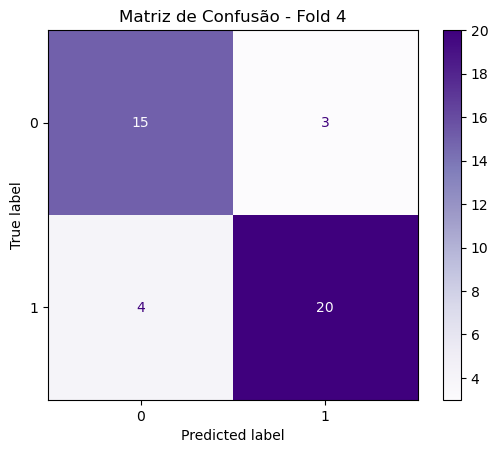

Fold 4 - Acc: 0.833 | Prec: 0.870 | Rec: 0.833 | F1: 0.851

Fold 5: Removendo 'thal_1.0' (p-valor = 0.997)
Fold 5: Removendo 'ca_4.0' (p-valor = 0.921)
Fold 5: Removendo 'slope_1.0' (p-valor = 0.689)
Fold 5: Removendo 'thal_2.0' (p-valor = 0.638)
Fold 5: Removendo 'trestbps' (p-valor = 0.667)
Fold 5: Removendo 'fbs' (p-valor = 0.618)
Fold 5: Removendo 'age' (p-valor = 0.605)
Fold 5: Removendo 'restecg_2.0' (p-valor = 0.591)
Fold 5: Removendo 'restecg_1.0' (p-valor = 0.539)
Fold 5: Removendo 'ca_3.0' (p-valor = 0.395)
Fold 5: Removendo 'thalach' (p-valor = 0.453)
Fold 5: Removendo 'slope_2.0' (p-valor = 0.116)
Fold 5: Removendo 'chol' (p-valor = 0.130)
Fold 5: Removendo 'thal_3.0' (p-valor = 0.093)


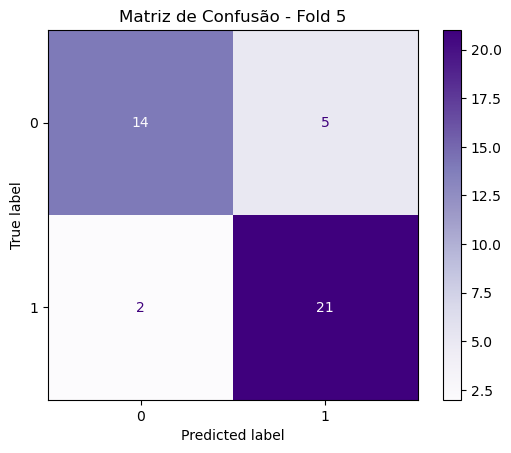

Fold 5 - Acc: 0.833 | Prec: 0.808 | Rec: 0.913 | F1: 0.857


=== Frequência de uso das variáveis nos folds ===
const                      1.00
sex                        1.00
oldpeak                    1.00
cp_1.0                     1.00
cp_2.0                     1.00
cp_3.0                     1.00
thal_2.0                   0.80
slope_1.0                  0.80
ca_1.0                     0.80
exang                      0.60
ca_2.0                     0.60
chol                       0.40
ca_3.0                     0.20
age                        0.00
trestbps                   0.00
fbs                        0.00
thalach                    0.00
thal_1.0                   0.00
thal_3.0                   0.00
slope_2.0                  0.00
restecg_1.0                0.00
restecg_2.0                0.00
ca_4.0                     0.00

=== Variáveis mais estáveis (≥ 60% dos folds) ===
['const', 'sex', 'exang', 'oldpeak', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'thal_2.0', 'slope_1.0', 'ca_1.0', 

In [ ]:
from collections import Counter


def backward_selection_cv(X_train, y_train, X_test, y_test, n_splits=5, p_threshold=0.05, threshold_binary=0.5, verbose=True):

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=360)
    selected_features_per_fold = []
    
    fold = 1
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx].reset_index(drop=True), X_train.iloc[val_idx].reset_index(drop=True)
        y_tr, y_val = y_train.iloc[train_idx].reset_index(drop=True), y_train.iloc[val_idx].reset_index(drop=True)
        
        selected_X_tr, selected_X_val = X_tr.copy(), X_val.copy()
        
        # Backward selection
        while True:
            model_cv = sm.OLS(y_tr, selected_X_tr).fit()
            pvals = model_cv.pvalues.drop("const", errors="ignore")
            
            if pvals.empty:
                break
            
            worst_var = pvals.idxmax()
            worst_pval = pvals.loc[worst_var]
            
            if worst_pval > p_threshold:
                if verbose:
                    print(f"Fold {fold}: Removendo '{worst_var}' (p-valor = {worst_pval:.3f})")
                selected_X_tr = selected_X_tr.drop(columns=[worst_var])
                if worst_var in selected_X_val.columns:
                    selected_X_val = selected_X_val.drop(columns=[worst_var])
            else:
                break
        
        # Garantir alinhamento
        selected_X_val = selected_X_val[selected_X_tr.columns]
        selected_features_per_fold.append(selected_X_tr.columns.tolist())
        
        # Ajuste do modelo do fold
        model_fold = sm.OLS(y_tr, selected_X_tr).fit()
        
        # Predição binária
        y_pred = (model_fold.predict(selected_X_val) > threshold_binary).astype(int)
        
        # Métricas
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        
        if verbose:
            cm = confusion_matrix(y_val, y_pred)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
            disp.plot(cmap=plt.cm.Purples)
            plt.title(f"Matriz de Confusão - Fold {fold}")
            plt.show()
            
            print(f"Fold {fold} - Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f}\n")
        
        fold += 1
    
    # Frequência das variáveis nos folds
    flat_features = [feat for sublist in selected_features_per_fold for feat in sublist]
    freq = Counter(flat_features)
    num_folds = len(selected_features_per_fold)
    feature_freq = {feat: freq[feat]/num_folds for feat in X_train.columns}
    
    sorted_features = sorted(feature_freq.items(), key=lambda x: x[1], reverse=True)
    
    if verbose:
        print("\n=== Frequência de uso das variáveis nos folds ===")
        for feat, fr in sorted_features:
            print(f"{feat:25s}  {fr:.2f}")
    
    stable_features = [feat for feat, fr in feature_freq.items() if fr >= 0.6]
    
    if verbose:
        print("\n=== Variáveis mais estáveis (≥ 60% dos folds) ===")
        print(stable_features)
    
    # Avaliação final no teste
    X_train_stable = X_train[stable_features]
    X_test_stable  = X_test[stable_features]
    
    model_final = sm.OLS(y_train, X_train_stable).fit()
    y_pred_test = (model_final.predict(X_test_stable) > threshold_binary).astype(int)
    
    acc_final = accuracy_score(y_test, y_pred_test)
    prec_final = precision_score(y_test, y_pred_test, zero_division=0)
    rec_final = recall_score(y_test, y_pred_test, zero_division=0)
    f1_final = f1_score(y_test, y_pred_test, zero_division=0)
    
    if verbose:
        print("\n=== Avaliação final no conjunto de teste (usando variáveis mais estáveis) ===")
        print(f"Acurácia:  {acc_final:.3f}")
        print(f"Precisão:  {prec_final:.3f}")
        print(f"Recall:    {rec_final:.3f}")
        print(f"F1-score:  {f1_final:.3f}")
    
    metrics_final = (acc_final, prec_final, rec_final, f1_final)
    
    return model_final, stable_features, metrics_final

model_final, stable_features, metrics_final = backward_selection_cv(
    X_train, y_train, X_test, y_test,
    n_splits=5,
    p_threshold=0.05,
    threshold_binary=0.5,
    verbose=True
)


Vemos que as variáveis presentes em todos os clusters foram:

- const

- sex

- oldpeak

- cp_1

- cp_2

- cp_3

em seguida com 4-3 aparições temos:

- thal_2

- slope_1

- exang

- ca_2

- ca_1

já as outras ficaram com menos de 3 aparições

Vamos escolher as variáveis que apareceram em pelo menos 3 cluster para montar um problema simplificado.



In [ ]:
vars_inbackward = ["sex", "oldpeak", "cp_1.0", "cp_2.0", "cp_3.0", "thal_2.0", "slope_1.0", "exang", "ca_2.0", "ca_1.0"]

In [ ]:
vars_to_keep = list(dict.fromkeys([v for v in vars_inbackward if v != "const"]))

# Mantém apenas as colunas selecionadas
X_train_backward = X_train[[v for v in vars_to_keep if v in X_train.columns]]

print("Colunas mantidas no treino:", X_train_backward.columns.tolist())


Colunas mantidas no treino: ['sex', 'oldpeak', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'thal_2.0', 'slope_1.0', 'exang', 'ca_2.0', 'ca_1.0']


In [ ]:
training_thresholds(Regressao_Linear_Model,X_train_backward,y_train, acc_min = 0.85)


Threshold ótimo encontrado (CV): 0.49
Acurácia média: 0.857
Recall médio máximo (Acurácia ≥ 0.85): 0.912


0.49

Threshold otimizado para o modelo simplificado foi de 0.49

## LDA - Análise Linear Discriminante

Após a abordagem inicial com a Regressão Linear como um classificador, passaremos agora para a Análise Linear Discriminante (LDA), um método que modela a classificação de maneira inerentemente estatística e mais robusta.

LDA é um algoritmo que assume que os dados de cada classe seguem uma distribuição Gaussiana (Normal) e que todas as classes compartilham da mesma matriz de covariância (ou seja, a mesma dispersão). A ideia central é:

Projetar os Dados: Encontrar um eixo (ou subespaço) que maximize a separação entre as médias das classes e minimize a variação dentro de cada classe.

Decisão: Classificar um novo ponto de dados na classe cuja média, ele está mais próximo após a projeção.

A principal vantagem do LDA é a sua capacidade de reduzir a dimensionalidade enquanto otimiza a separação entre as classes, tornando-o um classificador linear eficiente e interpretável. Para garantir a validade estatística do modelo, o Standard Scaling das variáveis contínuas é um passo obrigatório, pois o LDA é sensível à escala das variáveis

=== AVALIAÇÃO DO LDA NO CONJUNTO DE TESTE (30%) ===
Threshold:  0.50
Acurácia :  0.868
Precisão :  0.863
Recall: 0.898


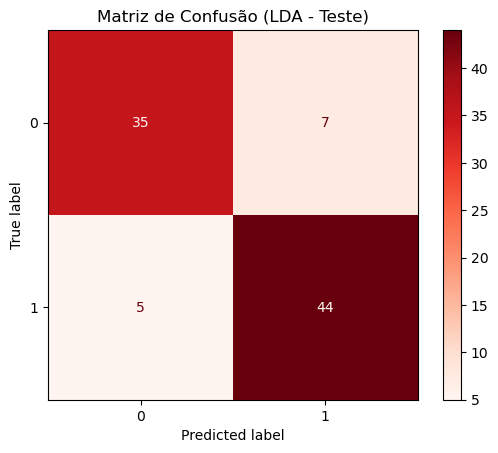


=== AVALIAÇÃO DO LDA NO CONJUNTO DE TREINO ===
Acurácia Treino: 0.890
Precisão Treino: 0.870
Recall Treino: 0.939


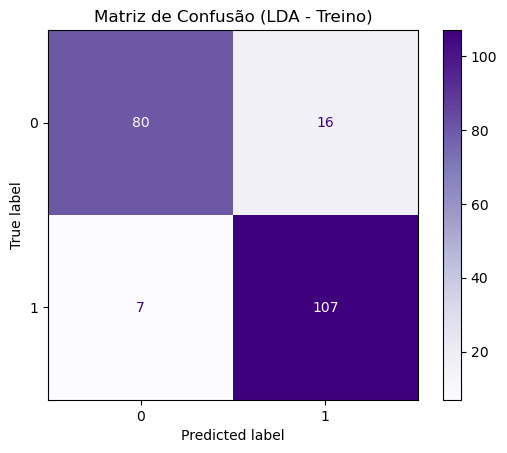

In [613]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

def LDA_model_(threshold=0.5, verbose=True, treino_test=[], vars_in = []):
    if not treino_test:
        # Separar Features (X) e Target (y)
        X = heart_ds.drop("target", axis=1)
        y = heart_ds["target"]

        # Identifica colunas contínuas e categóricas
        continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
        categorical_cols = ['cp', 'thal', 'slope', 'restecg']

        # One-hot encoding
        X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

        # Escalonamento das variáveis contínuas
        cols_to_scale = [col for col in continuous_cols if col in X_encoded.columns]
        scaler = StandardScaler()
        X_encoded[cols_to_scale] = scaler.fit_transform(X_encoded[cols_to_scale])

        # Divisão Treino/Teste
        X_train, X_test, y_train, y_test = train_test_split(
            X_encoded, y, test_size=0.3, random_state=42, stratify=y
        )

    else:
        X_train, X_test, y_train, y_test = treino_test

    # Modelo LDA
    model = LDA()
    model.fit(X_train, y_train)

    # Probabilidades e threshold customizado
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > threshold).astype(int)

    # Métricas no conjunto de teste
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    if verbose:
        print("=== AVALIAÇÃO DO LDA NO CONJUNTO DE TESTE (30%) ===")
        print(f"Threshold:  {threshold:.2f}")
        print(f"Acurácia :  {acc:.3f}")
        print(f"Precisão :  {prec:.3f}")
        print(f"Recall: {rec:.3f}")  # Substituí "Sensibilidade" por "Recall"

        # Matriz de confusão no teste
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(
            cmap="Reds", values_format="d"
        )
        plt.title("Matriz de Confusão (LDA - Teste)")
        plt.show()

        # Métricas no conjunto de treino
        y_prob_train = model.predict_proba(X_train)[:, 1]
        y_pred_train = (y_prob_train > threshold).astype(int)
        acc_train = accuracy_score(y_train, y_pred_train)
        prec_train = precision_score(y_train, y_pred_train)
        rec_train = recall_score(y_train, y_pred_train)
        print("\n=== AVALIAÇÃO DO LDA NO CONJUNTO DE TREINO ===")
        print(f"Acurácia Treino: {acc_train:.3f}")
        print(f"Precisão Treino: {prec_train:.3f}")
        print(f"Recall Treino: {rec_train:.3f}")

        # Matriz de confusão no treino
        cm_train = confusion_matrix(y_train, y_pred_train)
        ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=[0, 1]).plot(
            cmap="Purples", values_format="d"
        )
        plt.title("Matriz de Confusão (LDA - Treino)")
        plt.show()

    return acc, prec, rec


acc, prec, rec = LDA_model_(threshold=0.5)


Apenas definindo em classe para simplificar o treinamento de hiper-parâmetros

In [ ]:
class LDA_Model:
    def __init__(self, X_train, y_train, vars_in=None):
        if vars_in is not None:
            X_train = X_train[vars_in].copy()

        self.columns = X_train.columns
        self.model = LDA()
        self.model.fit(X_train, y_train)

    def predict(self, X):
        if hasattr(self, "columns"):
            X = X.copy()
            missing_cols = [c for c in self.columns if c not in X.columns]
            for c in missing_cols:
                X[c] = 0
            X = X[self.columns]

        y_prob = self.model.predict_proba(X)[:, 1]
        return np.clip(y_prob, 0, 1)

    def evaluate(self, X, y, threshold=0.5, verbose=True):
        y_prob = self.predict(X)
        y_pred = (y_prob >= threshold).astype(int)

        acc = accuracy_score(y, y_pred)
        prec = precision_score(y, y_pred)
        rec = recall_score(y, y_pred)

        if verbose:
            print(f"Acurácia: {acc:.3f}, Precisão: {prec:.3f}, Recall: {rec:.3f}")
            cm = confusion_matrix(y, y_pred)
            ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot()
            plt.show()

        return acc, prec, rec


In [ ]:
melhor_threshold = training_thresholds(LDA_Model, X_train, y_train, acc_min=0.85)


Threshold ótimo encontrado (CV): 0.35
Acurácia média: 0.852
Recall médio máximo (Acurácia ≥ 0.85): 0.921


Para LDA encontramos um bom balanceamento classificando a partir de 0.35 de probabilidade para a classe 1

## QDA - Análise Quadrática Discriminante

A Análise Quadrática Discriminante (QDA) é a progressão natural da Análise Linear Discriminante (LDA). Enquanto o LDA assume que todas as classes compartilham a mesma matriz de covariância (ou seja, a dispersão dos dados é idêntica para todas as classes), o QDA relaxa essa suposição

In [616]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def QDA_(threshold=0.5, verbose=True, treino_test=[]):
    if not treino_test:
        # Separar Features (X) e Target (y)
        X = heart_ds.drop("target", axis=1)
        y = heart_ds["target"]

        # One-Hot Encoding
        continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
        categorical_cols = ['cp', 'thal', 'slope', 'restecg'] 

        X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

        # Escalonamento das variáveis contínuas
        cols_to_scale = [col for col in continuous_cols if col in X_encoded.columns]
        scaler = StandardScaler()
        X_encoded[cols_to_scale] = scaler.fit_transform(X_encoded[cols_to_scale])

        # Divisão Treino/Teste
        X_train, X_test, y_train, y_test = train_test_split(
            X_encoded, y, test_size=0.3, random_state=42, stratify=y
        )
    else:
        X_train, X_test, y_train, y_test = treino_test

    # Modelo QDA
    model = QDA(reg_param=0.1, priors=[0.5, 0.5])
    model.fit(X_train, y_train)

    # Probabilidades e threshold customizado
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > threshold).astype(int)

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    if verbose:
        print("AVALIAÇÃO DO QDA NO CONJUNTO DE TESTE (30%)")
        print("-------------------------------------------")
        print(f"Threshold:  {threshold:.2f}")
        print(f"Acurácia :  {acc:.3f}")
        print(f"Precisão :  {prec:.3f}")
        print(f"Recall: {rec:.3f}")
        print("-------------------------------------------")

        # Matriz de confusão no teste
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(
            cmap="Reds", values_format="d"
        )
        plt.title("Matriz de Confusão (QDA - Teste)")
        plt.show()

        # Métricas no treino
        y_prob_train = model.predict_proba(X_train)[:, 1]
        y_pred_train = (y_prob_train > threshold).astype(int)
        acc_train = accuracy_score(y_train, y_pred_train)
        prec_train = precision_score(y_train, y_pred_train)
        rec_train = recall_score(y_train, y_pred_train)
        print(f"Acurácia Treino: {acc_train:.3f}")
        print(f"Precisão Treino: {prec_train:.3f}")
        print(f"Recall Treino: {rec_train:.3f}")

        cm_train = confusion_matrix(y_train, y_pred_train)
        ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=[0, 1]).plot(
            cmap="Purples", values_format="d"
        )
        plt.title("Matriz de Confusão (QDA - Treino)")
        plt.show()

    return acc, prec, rec, acc_train, prec_train, rec_train


Definindo como classe para facilitar o treinamento de hiper-parâmetros

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

class QDA_Model:
    def __init__(self, X_train, y_train, vars_in=None):
        """
        Classe QDA compatível com training_thresholds.
        X_train, y_train: DataFrame/Series de treino
        vars_in: lista de variáveis a manter (como no backward selection)
        """
        X = X_train.copy()
        if vars_in is not None:
            vars_in = [v for v in vars_in if v in X.columns]
            X = X[vars_in]

        # Escalonamento (apenas contínuas, se existirem)
        continuous_cols = [col for col in X.columns if np.issubdtype(X[col].dtype, np.number)]
        if continuous_cols:
            scaler = StandardScaler()
            X[continuous_cols] = scaler.fit_transform(X[continuous_cols])

        self.columns = X.columns
        self.model = QDA(reg_param=0.5, priors=[0.5,0.5])
        self.model.fit(X, y_train)

    def predict(self, X):
        X = X.copy()
        # Mantém apenas as colunas da classe
        X = X[[c for c in self.columns if c in X.columns]]
        # Adiciona colunas faltantes como random_state0
        for c in self.columns:
            if c not in X.columns:
                X[c] = 0
        X = X[self.columns]  # garante a mesma ordem
        y_prob = self.model.predict_proba(X)[:, 1]
        return np.clip(y_prob, 0, 1)


In [ ]:
best_threshold_qda = training_thresholds(QDA_Model, X_train, y_train, acc_min=0.76)
print("Melhor threshold QDA:", best_threshold_qda)


/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Varia


Threshold ótimo encontrado (CV): 0.01
Acurácia média: 0.776
Recall médio máximo (Acurácia ≥ 0.76): 0.957
Melhor threshold QDA: 0.01


/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


Threshold ótimo encontrado: 0.01, QDA por falta de dados obviamente teria que se mostrar menos eficaz

## Regressão Logística

Definindo uma função de **Regressão Logística** geral para facilitar o treinamento com e sem regularização

In [ ]:
from sklearn.linear_model import LogisticRegression

def LogisticRegression_(threshold=0.5, class_weight=None, penalty=None, lambda_=0, verbose=True, params=False, treino_test = []):

    if not treino_test:
        # Separar Features e Target
        X = heart_ds.drop(["target", "index"], axis=1)
        y = heart_ds["target"].astype(int)

        # Colunas categóricas e contínuas
        categorical_cols = ['cp', 'thal', 'slope', 'restecg']
        continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

        # One-Hot Encoding
        X_encoded = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True, dtype=int)

        # Escalonamento das variáveis contínuas
        cols_to_scale = [c for c in continuous_cols if c in X_encoded.columns]
        scaler = StandardScaler()
        if len(cols_to_scale) > 0:
            X_encoded[cols_to_scale] = scaler.fit_transform(X_encoded[cols_to_scale])

        # Divisão treino/teste
        X_train, X_test, y_train, y_test = train_test_split(
            X_encoded, y, test_size=0.3, random_state=42, stratify=y
        )

    else:
        X_train, X_test, y_train, y_test = treino_test

    # Se penalty=None, usar solver='saga', senão usar 'liblinear'
    solver_choice = 'saga' if penalty is None else 'liblinear'

    # Modelo com penalização e lambda
    model = LogisticRegression(
        class_weight=class_weight, 
        solver=solver_choice, 
        max_iter=500, 
        penalty=penalty, 
        C=1/lambda_ if lambda_ > 0 else 1e10  # Para 'lambda=0', não há regularização (C muito alto)
    )
    
    model.fit(X_train, y_train)

    # Se params=True, imprime os parâmetros e coeficientes
    if params:
        print("Parâmetros do Modelo:")
        print(model.get_params())

        # Coeficientes do modelo
        print("\nCoeficientes do Modelo:")
        coef_df = pd.DataFrame({
            'Variáveis': X_train.columns,
            'Coeficientes': model.coef_[0]
        })
        print(coef_df)

    # Probabilidades e threshold customizado
    y_prob_train = model.predict_proba(X_train)[:, 1]
    y_prob_test  = model.predict_proba(X_test)[:, 1]
    
    y_pred_train = (y_prob_train > threshold).astype(int)
    y_pred_test  = (y_prob_test  > threshold).astype(int)

    # Métricas de Treino
    acc_train = accuracy_score(y_train, y_pred_train)
    prec_train = precision_score(y_train, y_pred_train)
    rec_train  = recall_score(y_train, y_pred_train)

    # Métricas de Teste
    acc_test = accuracy_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)
    rec_test  = recall_score(y_test, y_pred_test)

    # Imprimir métricas se verbose=True
    if verbose:
        print("=== Métricas de Treino ===")
        print(f"Acurácia: {acc_train:.3f} | Precisão: {prec_train:.3f} | Recall: {rec_train:.3f}")
        cm_train = confusion_matrix(y_train, y_pred_train)
        ConfusionMatrixDisplay(cm_train, display_labels=[0,1]).plot(cmap="Purples", values_format="d")
        plt.title("Matriz de Confusão - Treino")
        plt.show()

        print("=== Métricas de Teste ===")
        print(f"Acurácia: {acc_test:.3f} | Precisão: {prec_test:.3f} | Recall: {rec_test:.3f}")
        cm_test = confusion_matrix(y_test, y_pred_test)
        ConfusionMatrixDisplay(cm_test, display_labels=[0,1]).plot(cmap="Reds", values_format="d")
        plt.title("Matriz de Confusão - Teste")
        plt.show()

    return acc_test, prec_test, rec_test


Definindo o modelo com classe para facilitar o treinamento de hiper-parâmetros:

In [ ]:

class LogisticRegression_Model:
    def __init__(self, X, y, vars_in=None, class_weight=None):
        """
        X, y: DataFrames/Series
        vars_in: lista de colunas a usar (similar ao backward selection)
        class_weight: dicionário para pesos das classes
        """
        # Seleciona apenas variáveis desejadas
        if vars_in is not None:
            X = X[vars_in].copy()
        
        # Remove colunas duplicadas
        X = X.loc[:, ~X.columns.duplicated()]
        
        # Escalonamento
        self.scaler = StandardScaler()
        self.X = pd.DataFrame(self.scaler.fit_transform(X), columns=X.columns)
        self.y = y.reset_index(drop=True)
        
        # Treina o modelo
        self.model = LogisticRegression(
            class_weight=class_weight, solver='liblinear', max_iter=500
        )
        self.model.fit(self.X, self.y)
        self.columns = self.X.columns

    def predict(self, X):
        # Seleciona as mesmas colunas usadas no treino
        X = X[self.columns].copy()
        X = pd.DataFrame(self.scaler.transform(X), columns=self.columns)
        y_prob = self.model.predict_proba(X)[:, 1]
        return np.clip(y_prob, 0, 1)



Para maximizar o Recall iremos mexer com os pesos da função, ou seja, veremos o peso que mantém ainda uma acurácia mínima e maximiza o **Recall**

In [ ]:

def training_weights(model_class, X_train, y_train, vars_in=None, threshold=0.5,
                        acc_min=0.8, n_splits=5, verbose=True):
   
    
    pesos_positivos = np.linspace(1, 10, 20)
    melhor_recall = -1
    melhor_weight = None
    acuracia_correspondente = None

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for w in pesos_positivos:
        acc_list, rec_list = [], []
        class_weight = {0: 1, 1: w}

        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[train_idx].reset_index(drop=True), X_train.iloc[val_idx].reset_index(drop=True)
            y_tr, y_val = y_train.iloc[train_idx].reset_index(drop=True), y_train.iloc[val_idx].reset_index(drop=True)

            model = model_class(X_tr, y_tr, vars_in=vars_in, class_weight=class_weight)
            y_pred_val = model.predict(X_val)
            y_pred_bin = (y_pred_val >= threshold).astype(int)

            acc_list.append(accuracy_score(y_val, y_pred_bin))
            rec_list.append(recall_score(y_val, y_pred_bin))

        acc_mean = np.mean(acc_list)
        rec_mean = np.mean(rec_list)

        if acc_mean >= acc_min and rec_mean > melhor_recall:
            melhor_recall = rec_mean
            melhor_weight = w
            acuracia_correspondente = acc_mean

    if verbose:
        print(f"Melhor peso da classe positiva (CV): {melhor_weight:.2f}")
        print(f"Recall médio máximo: {melhor_recall:.3f} | Acurácia média: {acuracia_correspondente:.3f}")
        # Treina modelo final com melhor peso
        final_model = model_class(X_train, y_train, vars_in=vars_in, class_weight={0: 1, 1: melhor_weight})
        y_pred_final = final_model.predict(X_train)
        y_pred_final_bin = (y_pred_final >= threshold).astype(int)
        cm = confusion_matrix(y_train, y_pred_final_bin)
        ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(cmap="Reds", values_format="d")
        plt.title("Matriz de Confusão - Treino (melhor peso)")
        plt.show()

    return melhor_weight, melhor_recall, acuracia_correspondente


Melhor peso da classe positiva (CV): 1.95
Recall médio máximo: 0.938 | Acurácia média: 0.852


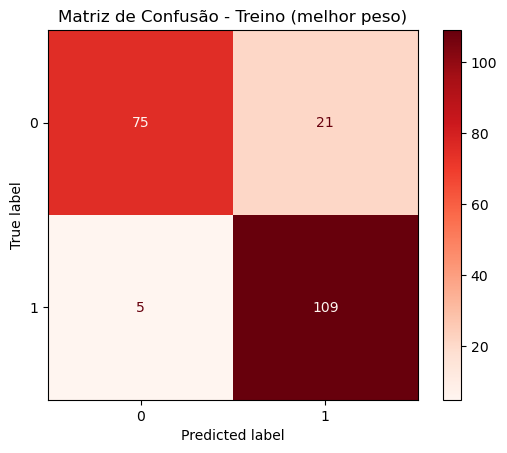

In [ ]:
best_weight, best_recall, best_acc = training_weights(
    LogisticRegression_Model,
    X_train,
    y_train,
    vars_in=vars_inbackward,
    threshold=0.5,
    acc_min=0.85
)


O melhor peso é 1.95 para a classe 1

Fold 1: Removendo 'slope_1.0' (p-valor = 0.975)
Fold 1: Removendo 'ca_4.0' (p-valor = 1.000)
Fold 1: Removendo 'fbs' (p-valor = 0.930)
Fold 1: Removendo 'thal_2.0' (p-valor = 1.000)
Fold 1: Removendo 'restecg_2.0' (p-valor = 0.906)
Fold 1: Removendo 'age' (p-valor = 0.874)
Fold 1: Removendo 'chol' (p-valor = 0.838)
Fold 1: Removendo 'restecg_1.0' (p-valor = 0.649)
Fold 1: Removendo 'thal_1.0' (p-valor = 0.565)
Fold 1: Removendo 'ca_3.0' (p-valor = 0.370)
Fold 1: Removendo 'thalach' (p-valor = 0.404)
Fold 1: Removendo 'exang' (p-valor = 0.153)
Fold 1: Removendo 'trestbps' (p-valor = 0.091)
Fold 1: Removendo 'ca_2.0' (p-valor = 0.050)


/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/statsmodels/base/optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: weights. After release 0.14, this will raise.
  warnings.warn(
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/statsmodels/base/optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: weights. After release 0.14, this will raise.
  warnings.warn(
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/statsmodels/base/optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton i

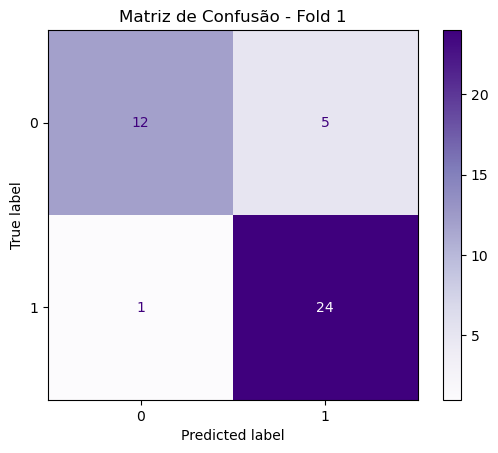

Fold 1 - Acc: 0.857 | Prec: 0.828 | Rec: 0.960 | F1: 0.889

Fold 2: Removendo 'thal_2.0' (p-valor = 1.000)
Fold 2: Removendo 'restecg_2.0' (p-valor = 1.000)
Fold 2: Removendo 'ca_4.0' (p-valor = 1.000)
Fold 2: Removendo 'restecg_1.0' (p-valor = 0.879)
Fold 2: Removendo 'thal_1.0' (p-valor = 0.766)
Fold 2: Removendo 'slope_2.0' (p-valor = 0.768)
Fold 2: Removendo 'fbs' (p-valor = 0.402)
Fold 2: Removendo 'age' (p-valor = 0.390)
Fold 2: Removendo 'ca_3.0' (p-valor = 0.264)
Fold 2: Removendo 'thalach' (p-valor = 0.338)
Fold 2: Removendo 'exang' (p-valor = 0.231)
Fold 2: Removendo 'chol' (p-valor = 0.142)
Fold 2: Removendo 'ca_1.0' (p-valor = 0.080)
Fold 2: Removendo 'ca_2.0' (p-valor = 0.072)


/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/statsmodels/base/optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: weights. After release 0.14, this will raise.
  warnings.warn(
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/statsmodels/base/optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: weights. After release 0.14, this will raise.
  warnings.war

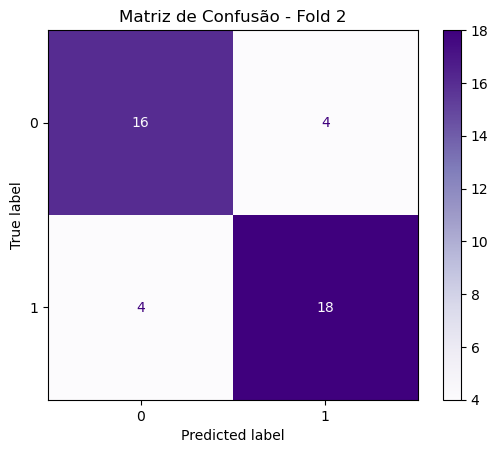

Fold 2 - Acc: 0.810 | Prec: 0.818 | Rec: 0.818 | F1: 0.818

Fold 3: Removendo 'thal_3.0' (p-valor = 1.000)
Fold 3: Removendo 'ca_4.0' (p-valor = 1.000)
Fold 3: Removendo 'restecg_2.0' (p-valor = 1.000)
Fold 3: Removendo 'ca_3.0' (p-valor = 0.943)
Fold 3: Removendo 'thal_1.0' (p-valor = 0.719)
Fold 3: Removendo 'slope_2.0' (p-valor = 0.704)
Fold 3: Removendo 'thalach' (p-valor = 0.578)
Fold 3: Removendo 'trestbps' (p-valor = 0.509)
Fold 3: Removendo 'restecg_1.0' (p-valor = 0.461)
Fold 3: Removendo 'ca_2.0' (p-valor = 0.385)
Fold 3: Removendo 'fbs' (p-valor = 0.246)
Fold 3: Removendo 'ca_1.0' (p-valor = 0.232)
Fold 3: Removendo 'slope_1.0' (p-valor = 0.206)
Fold 3: Removendo 'exang' (p-valor = 0.091)
Fold 3: Removendo 'age' (p-valor = 0.072)


/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/statsmodels/base/optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: weights. After release 0.14, this will raise.
  warnings.warn(
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/statsmodels/base/optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: weights. After release 0.14, this will raise.
  warnings.war

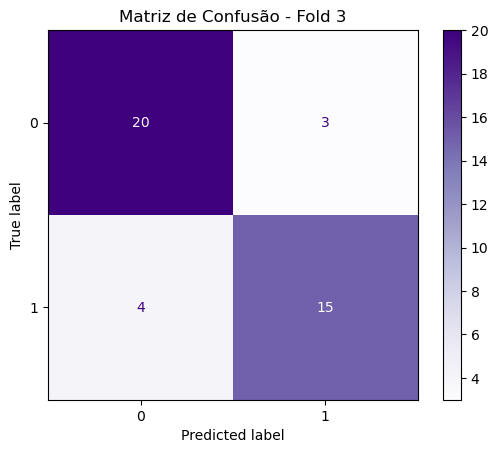

Fold 3 - Acc: 0.833 | Prec: 0.833 | Rec: 0.789 | F1: 0.811

Fold 4: Removendo 'thal_1.0' (p-valor = 1.000)
Fold 4: Removendo 'ca_4.0' (p-valor = 1.000)
Fold 4: Removendo 'restecg_2.0' (p-valor = 0.964)
Fold 4: Removendo 'thal_3.0' (p-valor = 0.947)
Fold 4: Removendo 'slope_1.0' (p-valor = 0.929)
Fold 4: Removendo 'trestbps' (p-valor = 0.905)
Fold 4: Removendo 'restecg_1.0' (p-valor = 0.812)
Fold 4: Removendo 'age' (p-valor = 0.539)
Fold 4: Removendo 'fbs' (p-valor = 0.503)
Fold 4: Removendo 'ca_3.0' (p-valor = 0.483)
Fold 4: Removendo 'thalach' (p-valor = 0.330)
Fold 4: Removendo 'chol' (p-valor = 0.145)
Fold 4: Removendo 'thal_2.0' (p-valor = 0.125)
Fold 4: Removendo 'ca_2.0' (p-valor = 0.090)
Fold 4: Removendo 'ca_1.0' (p-valor = 0.080)


/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/statsmodels/base/optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: weights. After release 0.14, this will raise.
  warnings.warn(
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/statsmodels/base/optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: weights. After release 0.14, this will raise.
  warnings.war

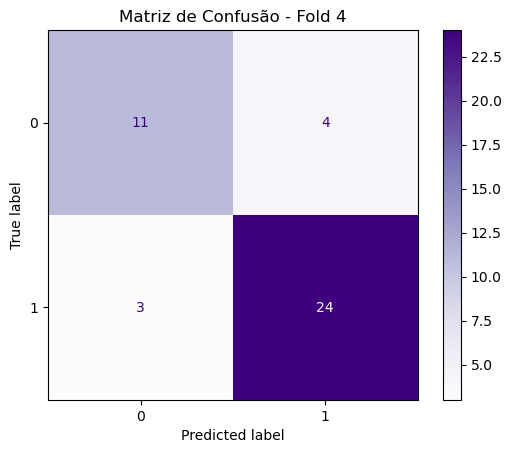

Fold 4 - Acc: 0.833 | Prec: 0.857 | Rec: 0.889 | F1: 0.873

Fold 5: Removendo 'ca_4.0' (p-valor = 1.000)
Fold 5: Removendo 'thal_1.0' (p-valor = 1.000)
Fold 5: Removendo 'ca_3.0' (p-valor = 1.000)
Fold 5: Removendo 'slope_1.0' (p-valor = 0.912)
Fold 5: Removendo 'restecg_2.0' (p-valor = 0.869)
Fold 5: Removendo 'thalach' (p-valor = 0.772)
Fold 5: Removendo 'age' (p-valor = 0.652)
Fold 5: Removendo 'thal_2.0' (p-valor = 0.558)
Fold 5: Removendo 'fbs' (p-valor = 0.566)
Fold 5: Removendo 'trestbps' (p-valor = 0.300)
Fold 5: Removendo 'restecg_1.0' (p-valor = 0.153)


/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/statsmodels/base/optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: weights. After release 0.14, this will raise.
  warnings.warn(
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/statsmodels/base/optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: weights. After release 0.14, this will raise.
  warnings.war

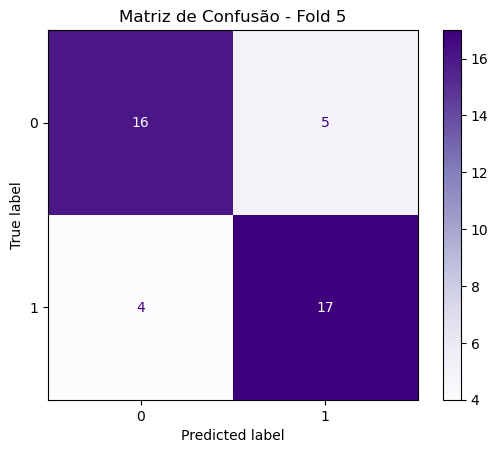

Fold 5 - Acc: 0.786 | Prec: 0.773 | Rec: 0.810 | F1: 0.791


=== Frequência de uso das variáveis nos folds ===
sex                        1.00
oldpeak                    1.00
cp_1.0                     1.00
cp_2.0                     1.00
cp_3.0                     1.00
thal_3.0                   0.60
slope_2.0                  0.60
chol                       0.40
exang                      0.40
ca_1.0                     0.40
trestbps                   0.20
thal_2.0                   0.20
slope_1.0                  0.20
ca_2.0                     0.20
const                      0.00
age                        0.00
fbs                        0.00
thalach                    0.00
thal_1.0                   0.00
restecg_1.0                0.00
restecg_2.0                0.00
ca_3.0                     0.00
ca_4.0                     0.00

=== Variáveis mais estáveis (≥ 60% dos folds) ===
['sex', 'oldpeak', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'thal_3.0', 'slope_2.0']


/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/statsmodels/base/optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: weights. After release 0.14, this will raise.
  warnings.warn(


(<statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x7cccf6b33410>,
 ['sex', 'oldpeak', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'thal_3.0', 'slope_2.0'],
 [['sex',
   'oldpeak',
   'cp_1.0',
   'cp_2.0',
   'cp_3.0',
   'thal_3.0',
   'slope_2.0',
   'ca_1.0'],
  ['sex',
   'trestbps',
   'oldpeak',
   'cp_1.0',
   'cp_2.0',
   'cp_3.0',
   'thal_3.0',
   'slope_1.0'],
  ['sex', 'chol', 'oldpeak', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'thal_2.0'],
  ['sex', 'exang', 'oldpeak', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'slope_2.0'],
  ['sex',
   'chol',
   'exang',
   'oldpeak',
   'cp_1.0',
   'cp_2.0',
   'cp_3.0',
   'thal_3.0',
   'slope_2.0',
   'ca_1.0',
   'ca_2.0']])

In [686]:
from collections import Counter
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

def backward_selection_cv_train_only(X_train, y_train, n_splits=5, p_threshold=0.05, threshold_binary=0.5, class_weight=None, verbose=True):
    """
    Backward selection usando apenas o treino com K-Folds.
    class_weight: dicionário {0: peso_classe0, 1: peso_classe1} ou None
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    selected_features_per_fold = []
    fold = 1
    
    # Cria vetor de pesos se class_weight for fornecido
    if class_weight is not None:
        weights_vector = y_train.map(class_weight).values
    else:
        weights_vector = None
    
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx].reset_index(drop=True), X_train.iloc[val_idx].reset_index(drop=True)
        y_tr, y_val = y_train.iloc[train_idx].reset_index(drop=True), y_train.iloc[val_idx].reset_index(drop=True)
        
        X_tr_sel, X_val_sel = sm.add_constant(X_tr.copy()), sm.add_constant(X_val.copy())
        
        # Se class_weight for usado, cria vetor de pesos para este fold
        if class_weight is not None:
            weights_tr = y_tr.map(class_weight).values
        else:
            weights_tr = None
        
        # Backward selection
        while True:
            model_cv = sm.Logit(y_tr, X_tr_sel).fit(disp=0, weights=weights_tr)
            pvals = model_cv.pvalues.drop("const", errors="ignore")
            if pvals.empty:
                break
            
            worst_var = pvals.idxmax()
            worst_pval = pvals.loc[worst_var]
            if worst_pval > p_threshold:
                if verbose:
                    print(f"Fold {fold}: Removendo '{worst_var}' (p-valor = {worst_pval:.3f})")
                X_tr_sel = X_tr_sel.drop(columns=[worst_var])
                X_val_sel = X_val_sel.drop(columns=[worst_var])
            else:
                break
        
        selected_features_per_fold.append([col for col in X_tr_sel.columns if col != "const"])
        
        # Avaliação no fold
        y_pred_val = (model_cv.predict(X_val_sel) > threshold_binary).astype(int)
        acc = accuracy_score(y_val, y_pred_val)
        prec = precision_score(y_val, y_pred_val, zero_division=0)
        rec = recall_score(y_val, y_pred_val, zero_division=0)
        f1 = f1_score(y_val, y_pred_val, zero_division=0)
        
        if verbose:
            cm = confusion_matrix(y_val, y_pred_val)
            fig, ax = plt.subplots()
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
            disp.plot(cmap=plt.cm.Purples, ax=ax)
            plt.title(f"Matriz de Confusão - Fold {fold}")
            plt.show()
            
            print(f"Fold {fold} - Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f}\n")
        
        fold += 1
    
    # Frequência das variáveis nos folds
    flat_features = [feat for sublist in selected_features_per_fold for feat in sublist]
    freq = Counter(flat_features)
    num_folds = len(selected_features_per_fold)
    feature_freq = {feat: freq.get(feat,0)/num_folds for feat in X_train.columns}
    
    sorted_features = sorted(feature_freq.items(), key=lambda x: x[1], reverse=True)
    
    if verbose:
        print("\n=== Frequência de uso das variáveis nos folds ===")
        for feat, fr in sorted_features:
            print(f"{feat:25s}  {fr:.2f}")
    
    stable_features = [feat for feat, fr in feature_freq.items() if fr >= 0.6]
    
    if verbose:
        print("\n=== Variáveis mais estáveis (≥ 60% dos folds) ===")
        print(stable_features)
    
    # Modelo final usando todas as folds do treino
    X_train_stable = sm.add_constant(X_train[stable_features])
    if class_weight is not None:
        weights_final = y_train.map(class_weight).values
    else:
        weights_final = None
    model_final = sm.Logit(y_train, X_train_stable).fit(disp=0, weights=weights_final)
    
    return model_final, stable_features, selected_features_per_fold

backward_selection_cv_train_only(X_train,y_train,class_weight={0:1,1:1.95})


In [687]:
vars_in_logistic_backward = ["sex","oldpeak","cp_1.0","cp_2.0","cp_3.0","thal_3.0","slope_2.0"]

## Regressão Logística com Lasso

Faremos agora a função para treinarmos o hiper-parâmetro "lambda" da regressão logistica com lasso


Melhor C: 0.46415888336127775, Melhor peso classe 1: 5.0
Acurácia média CV: 0.829, Recall médio CV: 0.965

=== Avaliação Final no Teste (Threshold=0.5) ===
Acurácia: 0.802 | Precisão: 0.763 | Recall: 0.918


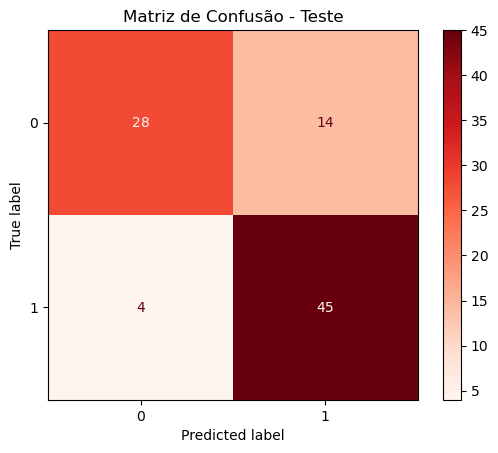


Coeficientes do Modelo Lasso:
       Variável  Coeficiente
10       cp_2.0     2.299104
13     thal_2.0     1.716161
11       cp_3.0     1.699389
9        cp_1.0     1.399589
16    slope_2.0     1.378245
8            ca    -1.080997
14     thal_3.0    -0.673561
7       oldpeak    -0.663577
1           sex    -0.394028
3          chol    -0.302508
6         exang    -0.228420
5       thalach     0.219972
17  restecg_1.0     0.141433
0           age    -0.051652
2      trestbps    -0.037084
12     thal_1.0     0.000000
15    slope_1.0     0.000000
4           fbs     0.000000
18  restecg_2.0     0.000000


In [ ]:


def Logistic_lasso_cv(threshold=0.5, min_acc=0.8, n_splits=5, Cs=np.logspace(-3,3,10), pesos_positivos=np.linspace(1,10,10), verbose=True, treino_test=[]):
    
    if not treino_test:
        X = heart_ds.drop(["target", "index"], axis=1)
        y = heart_ds["target"].astype(int)

        categorical_cols = ['cp', 'thal', 'slope', 'restecg']
        continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

        X_encoded = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True, dtype=int)
        cols_to_scale = [c for c in continuous_cols if c in X_encoded.columns]
        scaler = StandardScaler()
        if len(cols_to_scale) > 0:
            X_encoded[cols_to_scale] = scaler.fit_transform(X_encoded[cols_to_scale])

        X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, stratify=y, random_state=42)
    else:
        X_train, X_test, y_train, y_test = treino_test
        X_encoded = pd.concat([X_train, X_test])

    # 2) Grid search com CV
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    melhor_recall = -1
    best_C = None
    best_weight = None
    best_acc = 0

    for C in Cs:
        for w in pesos_positivos:
            acc_list, rec_list = [], []
            class_weight = {0:1, 1:w}

            for train_idx, val_idx in skf.split(X_train, y_train):
                X_tr, X_val = X_train.iloc[train_idx].reset_index(drop=True), X_train.iloc[val_idx].reset_index(drop=True)
                y_tr, y_val = y_train.iloc[train_idx].reset_index(drop=True), y_train.iloc[val_idx].reset_index(drop=True)

                model = LogisticRegression(penalty='l1', C=C, solver='liblinear', class_weight=class_weight, max_iter=500)
                model.fit(X_tr, y_tr)
                y_pred = (model.predict_proba(X_val)[:,1] > threshold).astype(int)

                acc_list.append(accuracy_score(y_val, y_pred))
                rec_list.append(recall_score(y_val, y_pred))

            acc_mean = np.mean(acc_list)
            rec_mean = np.mean(rec_list)

            if acc_mean >= min_acc and rec_mean > melhor_recall:
                melhor_recall = rec_mean
                best_C = C
                best_weight = w
                best_acc = acc_mean

    if verbose:
        print(f"\nMelhor C: {best_C}, Melhor peso classe 1: {best_weight}")
        print(f"Acurácia média CV: {best_acc:.3f}, Recall médio CV: {melhor_recall:.3f}")

    # 3) Treinar modelo final
    final_model = LogisticRegression(penalty='l1', C=best_C, solver='liblinear', class_weight={0:1,1:best_weight}, max_iter=500)
    final_model.fit(X_train, y_train)

    y_prob_test = final_model.predict_proba(X_test)[:,1]
    y_pred_test = (y_prob_test > threshold).astype(int)

    acc_test = accuracy_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)
    rec_test = recall_score(y_test, y_pred_test)

    if verbose:
        print(f"\n=== Avaliação Final no Teste (Threshold={threshold}) ===")
        print(f"Acurácia: {acc_test:.3f} | Precisão: {prec_test:.3f} | Recall: {rec_test:.3f}")

        cm = confusion_matrix(y_test, y_pred_test)
        ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(cmap="Reds", values_format="d")
        plt.title("Matriz de Confusão - Teste")
        plt.show()

        coef_df = pd.DataFrame({
            'Variável': X_encoded.columns,
            'Coeficiente': final_model.coef_[0]
        }).sort_values(by='Coeficiente', key=abs, ascending=False)
        print("\nCoeficientes do Modelo Lasso:")
        print(coef_df)

    return final_model, best_C, best_weight, acc_test, prec_test, rec_test

final_model, best_C, best_weight, acc, prec, rec = Logistic_lasso_cv(
    threshold=0.5,
    min_acc=0.8,
    n_splits=5
)



## Regressão Logistica com Ridge

In [ ]:
def Logistic_ridge_cv(threshold=0.5, min_acc=0.8, n_splits=5,
                      Cs=np.logspace(-3,3,10), pesos_positivos=np.linspace(1,10,10),
                      verbose=True, treino_test=[]):
    """
    Logistic Regression (Ridge - L2) com busca em grade (C, class_weight) via Cross-Validation.
    Seleciona o par que maximiza o recall, respeitando acurácia mínima.
    """

    # ============================
    # 1) Preparação dos dados
    # ============================
    if not treino_test:
        X = heart_ds.drop(["target", "index"], axis=1)
        y = heart_ds["target"].astype(int)

        categorical_cols = ['cp', 'thal', 'slope', 'restecg']
        continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

        # One-hot encoding e escalonamento
        X_encoded = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns],
                                   drop_first=True, dtype=int)
        cols_to_scale = [c for c in continuous_cols if c in X_encoded.columns]
        scaler = StandardScaler()
        if len(cols_to_scale) > 0:
            X_encoded[cols_to_scale] = scaler.fit_transform(X_encoded[cols_to_scale])

        # Split treino/teste
        X_train, X_test, y_train, y_test = train_test_split(
            X_encoded, y, test_size=0.3, stratify=y, random_state=42
        )
    else:
        X_train, X_test, y_train, y_test = treino_test
        X_encoded = pd.concat([X_train, X_test])

    # ============================
    # 2) Grid Search com Cross Validation
    # ============================
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    melhor_recall = -1
    best_C = None
    best_weight = None
    best_acc = 0

    for C in Cs:
        for w in pesos_positivos:
            acc_list, rec_list = [], []
            class_weight = {0: 1, 1: w}

            for train_idx, val_idx in skf.split(X_train, y_train):
                X_tr, X_val = X_train.iloc[train_idx].reset_index(drop=True), X_train.iloc[val_idx].reset_index(drop=True)
                y_tr, y_val = y_train.iloc[train_idx].reset_index(drop=True), y_train.iloc[val_idx].reset_index(drop=True)

                model = LogisticRegression(penalty='l2', C=C, solver='liblinear',
                                           class_weight=class_weight, max_iter=500)
                model.fit(X_tr, y_tr)
                y_pred = (model.predict_proba(X_val)[:, 1] > threshold).astype(int)

                acc_list.append(accuracy_score(y_val, y_pred))
                rec_list.append(recall_score(y_val, y_pred))

            acc_mean = np.mean(acc_list)
            rec_mean = np.mean(rec_list)

            if acc_mean >= min_acc and rec_mean > melhor_recall:
                melhor_recall = rec_mean
                best_C = C
                best_weight = w
                best_acc = acc_mean

    if verbose:
        print(f"\nMelhor C: {best_C}, Melhor peso da classe positiva: {best_weight}")
        print(f"Acurácia média CV: {best_acc:.3f}, Recall médio CV: {melhor_recall:.3f}")

    # ============================
    # 3) Treinar modelo final
    # ============================
    final_model = LogisticRegression(penalty='l2', C=best_C, solver='liblinear',
                                     class_weight={0:1,1:best_weight}, max_iter=500)
    final_model.fit(X_train, y_train)

    y_prob_test = final_model.predict_proba(X_test)[:, 1]
    y_pred_test = (y_prob_test > threshold).astype(int)

    acc_test = accuracy_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)
    rec_test = recall_score(y_test, y_pred_test)

    # ============================
    # 4) Exibição de resultados
    # ============================
    if verbose:
        print(f"\n=== Avaliação Final no Teste (Threshold={threshold}) ===")
        print(f"Acurácia: {acc_test:.3f} | Precisão: {prec_test:.3f} | Recall: {rec_test:.3f}")

        cm = confusion_matrix(y_test, y_pred_test)
        ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(cmap="Reds", values_format="d")
        plt.title("Matriz de Confusão - Teste")
        plt.show()

        coef_df = pd.DataFrame({
            'Variável': X_encoded.columns,
            'Coeficiente': final_model.coef_[0]
        }).sort_values(by='Coeficiente', key=abs, ascending=False)
        print("\nCoeficientes do Modelo Ridge:")
        print(coef_df)

    return final_model, best_C, best_weight, acc_test, prec_test, rec_test



Melhor C: 46.41588833612773, Melhor peso da classe positiva: 3.0
Acurácia média CV: 0.852, Recall médio CV: 0.930

=== Avaliação Final no Teste (Threshold=0.5) ===
Acurácia: 0.857 | Precisão: 0.833 | Recall: 0.918


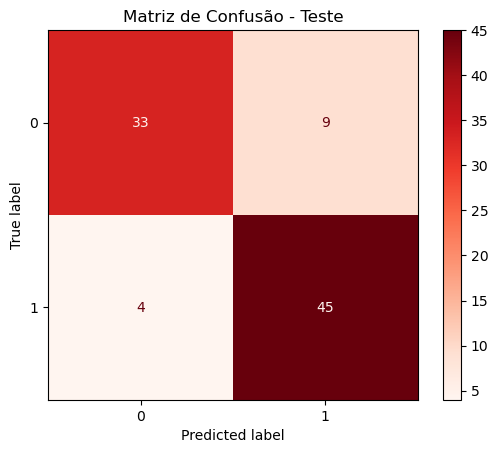


Coeficientes do Modelo Ridge:
       Variável  Coeficiente
11       cp_3.0     4.316547
10       cp_2.0     3.406975
9        cp_1.0     2.010304
1           sex    -1.820278
13     thal_2.0     1.339224
14     thal_3.0    -1.337877
8            ca    -1.285240
16    slope_2.0     1.130569
15    slope_1.0    -1.041338
4           fbs    -0.973186
12     thal_1.0     0.972202
7       oldpeak    -0.691088
2      trestbps    -0.427954
5       thalach     0.424760
3          chol    -0.358659
17  restecg_1.0     0.326651
18  restecg_2.0    -0.292225
6         exang    -0.231571
0           age    -0.068210


In [ ]:
ridge_model, best_C, best_weight, acc, prec, rec = Logistic_ridge_cv(
    threshold=0.5,
    min_acc=0.85,
    n_splits=5
)


## KNN

In [ ]:
def train_knn_cv(X_train, y_train, X_test=None, y_test=None,
                 acc_min=0.8, k_values=None, metrics=None,
                 outer_splits=5, inner_splits=3, random_state=42, verbose=True):

    from sklearn.neighbors import KNeighborsClassifier

    if k_values is None:
        k_values = [1, 3, 5, 7, 9, 11, 15, 21]
    if metrics is None:
        metrics = ['euclidean', 'manhattan', 'minkowski']

    skf_outer = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=random_state)
    cv_results = []

    if verbose:
        print(f"KNN — Cross-validation ({outer_splits}-fold externa, {inner_splits}-fold interna)")
        print(f"Acurácia mínima exigida: {acc_min}")
        print("=" * 70)

    for fold, (train_idx, val_idx) in enumerate(skf_outer.split(X_train, y_train), 1):
        X_tr_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr_fold)
        X_val_scaled = scaler.transform(X_val_fold)

        skf_inner = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=random_state)
       
    for fold, (train_idx, val_idx) in enumerate(skf_outer.split(X_train, y_train), 1):
        X_tr_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr_fold)
        X_val_scaled = scaler.transform(X_val_fold)

        skf_inner = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=random_state)
        results_inner = []

        for k in k_values:
            for metric in metrics:
                accs, recalls = [], []
                for tr_idx, te_idx in skf_inner.split(X_tr_scaled, y_tr_fold):
                    X_tr_inner, X_te_inner = X_tr_scaled[tr_idx], X_tr_scaled[te_idx]
                    y_tr_inner, y_te_inner = y_tr_fold.iloc[tr_idx], y_tr_fold.iloc[te_idx]

                    try:
                        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
                        knn.fit(X_tr_inner, y_tr_inner)
                        y_pred = knn.predict(X_te_inner)
                        accs.append(accuracy_score(y_te_inner, y_pred))
                        recalls.append(recall_score(y_te_inner, y_pred))
                    except:
                        accs.append(0)
                        recalls.append(0)

                acc_mean, rec_mean = np.mean(accs), np.mean(recalls)
                results_inner.append({'k': k, 'metric': metric, 'acc': acc_mean, 'rec': rec_mean})

        inner_df = pd.DataFrame(results_inner)
        # Seleciona o modelo com maior recall respeitando acc >= acc_min
        valid_models = inner_df[inner_df['acc'] >= acc_min]
        if len(valid_models) == 0:
            best_row = inner_df.loc[inner_df['acc'].idxmax()]  # fallback: melhor acc possível
        else:
            best_row = valid_models.loc[valid_models['rec'].idxmax()]

        best_k = int(best_row['k'])
        best_metric = best_row['metric']

        # Treina modelo com esse k no fold externo
        knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
        knn.fit(X_tr_scaled, y_tr_fold)
        y_pred = knn.predict(X_val_scaled)
        acc = accuracy_score(y_val_fold, y_pred)
        rec = recall_score(y_val_fold, y_pred)

        cv_results.append({
            'fold': fold,
            'best_k': best_k,
            'best_metric': best_metric,
            'acc': acc,
            'rec': rec
        })

        if verbose:
            print(f"Fold {fold}: k={best_k}, metric={best_metric} | Acc={acc:.3f} | Rec={rec:.3f}")

    cv_df = pd.DataFrame(cv_results)
    best_k_overall = int(cv_df['best_k'].mode()[0])
    best_metric_overall = cv_df['best_metric'].mode()[0]

    summary = {
        'acc_mean': cv_df['acc'].mean(),
        'acc_std': cv_df['acc'].std(),
        'rec_mean': cv_df['rec'].mean(),
        'rec_std': cv_df['rec'].std()
    }

    if verbose:
        print("\n=== Resultados Médios (Validação Cruzada Externa) ===")
        print(f"Acurácia média: {summary['acc_mean']:.3f} ± {summary['acc_std']:.3f}")
        print(f"Recall médio:   {summary['rec_mean']:.3f} ± {summary['rec_std']:.3f}")
        print(f"Melhor configuração global: k={best_k_overall}, métrica={best_metric_overall}")

    # ====================
    # Treino final + teste
    # ====================
    scaler_final = StandardScaler()
    X_train_scaled = scaler_final.fit_transform(X_train)
    knn_final = KNeighborsClassifier(n_neighbors=best_k_overall, metric=best_metric_overall)
    knn_final.fit(X_train_scaled, y_train)

    if X_test is not None and y_test is not None:
        X_test_scaled = scaler_final.transform(X_test)
        y_pred_test = knn_final.predict(X_test_scaled)
        acc_test = accuracy_score(y_test, y_pred_test)
        rec_test = recall_score(y_test, y_pred_test)

        if verbose:
            print(f"\n=== Avaliação Final no Teste ===")
            print(f"Teste: Acc={acc_test:.3f} | Recall={rec_test:.3f}")

            cm = confusion_matrix(y_test, y_pred_test)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
            plt.title(f"KNN Final (k={best_k_overall}, metric={best_metric_overall})")
            plt.xlabel("Predito")
            plt.ylabel("Real")
            plt.show()

    return {
        'best_k': best_k_overall,
        'best_metric': best_metric_overall,
        'cv_results': cv_df,
        'cv_summary': summary,
        'model_final': knn_final
    }


## SVM

In [679]:
from sklearn.svm import SVC


def SVM_tuned(X_train, y_train, acc_min=0.85, kernels=['rbf', 'linear'], Cs=[0.01, 0.1, 1, 10, 100], 
              gammas=['scale', 'auto'], cv=5, verbose=True):
    


    X = X_train.drop("const", axis = 1)
    y = y_train.reset_index(drop=True)

    # ===========================
    # Cross-validation manual
    # ===========================
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    best_params = None
    best_recall = -1
    best_acc = 0

    for kernel in kernels:
        for C in Cs:
            for gamma in gammas:
                accs, recs = [], []

                for train_idx, val_idx in skf.split(X, y):
                    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
                    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

                    model = SVC(kernel=kernel, C=C, gamma=gamma, probability=True, random_state=42)
                    model.fit(X_tr, y_tr)
                    y_pred = model.predict(X_val)

                    accs.append(accuracy_score(y_val, y_pred))
                    recs.append(recall_score(y_val, y_pred))

                mean_acc, mean_rec = np.mean(accs), np.mean(recs)

                if mean_acc >= acc_min and mean_rec > best_recall:
                    best_recall = mean_rec
                    best_acc = mean_acc
                    best_params = {'kernel': kernel, 'C': C, 'gamma': gamma}

    if best_params is None:
        raise ValueError(f"Nenhuma combinação atingiu acurácia mínima de {acc_min}")

    if verbose:
        print(f"Melhores parâmetros: {best_params}")
        print(f"Acurácia média: {best_acc:.3f} | Recall médio: {best_recall:.3f}")

    # ===========================
    # Treina modelo final
    # ===========================
    best_model = SVC(**best_params, probability=True, random_state=42)
    best_model.fit(X, y)

    if verbose:
        print("\nModelo final treinado com todo o conjunto de treino.")

    return best_model, best_params, best_acc, best_recall


In [682]:
model_svm, params, acc, rec = SVM_tuned(X_train, y_train, acc_min=0.85)


Melhores parâmetros: {'kernel': 'linear', 'C': 1, 'gamma': 'scale'}
Acurácia média: 0.857 | Recall médio: 0.876

Modelo final treinado com todo o conjunto de treino.


## Rede Neural:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim



seed = 42  # Defina o valor da semente para garantir reprodutibilidade

# Configura as sementes
np.random.seed(seed)  # Para o NumPy
torch.manual_seed(seed)  # Para PyTorch CPU
torch.cuda.manual_seed(seed)  # Para PyTorch GPU (caso use CUDA)
torch.cuda.manual_seed_all(seed)  # Para PyTorch GPU (caso use CUDA)

# Para garantir que a inicialização dos parâmetros seja a mesma a cada rodada
torch.backends.cudnn.deterministic = True  # Garante que os resultados sejam determinísticos
torch.backends.cudnn.benchmark = False  # Impede otimizações específicas de hardware

# Rede Neural simples
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.hidden = nn.Linear(input_dim, 8)
        self.output = nn.Linear(8, 1)
        self.dropout = nn.Dropout(0.2)
        self.activation = nn.Tanh()
        
    def forward(self, x):
        x = self.hidden(x)
        x = self.dropout(x)
        x = self.activation(x)
        x = self.output(x)
        return x

def NeuralNet_model(treino_test=[], verbose=False, epochs=500, patience=25):

    if not treino_test:
        X = heart_ds.drop("target", axis=1).to_numpy()
        y = heart_ds["target"].to_numpy().reshape(-1, 1)

        scaler = StandardScaler()
        X = scaler.fit_transform(X)


        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                            stratify=y, random_state=seed)
    else:
        X_train, X_test, y_train, y_test = treino_test
        X_train = X_train.to_numpy() if hasattr(X_train, "to_numpy") else X_train
        X_test  = X_test.to_numpy()  if hasattr(X_test, "to_numpy") else X_test
        y_train = y_train.to_numpy().reshape(-1,1) if hasattr(y_train, "to_numpy") else y_train.reshape(-1,1)
        y_test  = y_test.to_numpy().reshape(-1,1)  if hasattr(y_test, "to_numpy") else y_test.reshape(-1,1)


    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test, dtype=torch.float32)
    y_test_t  = torch.tensor(y_test, dtype=torch.float32)

    model = SimpleNN(X_train.shape[1])
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-3)

    best_acc_val = 0
    counter = 0
    best_weights = None

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()

        # Avaliação
        model.eval()
        with torch.no_grad():
            preds_train = (torch.sigmoid(model(X_train_t)) > 0.5).float()
            preds_test  = (torch.sigmoid(model(X_test_t)) > 0.5).float()

            acc_train = accuracy_score(y_train_t, preds_train)
            acc_test  = accuracy_score(y_test_t, preds_test)
            rec_train = recall_score(y_train_t, preds_train)
            rec_test  = recall_score(y_test_t, preds_test)
            prec_train = precision_score(y_train_t, preds_train)
            prec_test = precision_score(y_test_t, preds_test)

        if acc_test > best_acc_val:
            best_acc_val = acc_test
            best_weights = model.state_dict().copy()
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            break

    model.load_state_dict(best_weights)
    
    # Exibindo as métricas no treino e teste
    print("=== Métricas de Treino ===")
    print(f"Acurácia: {acc_train:.3f}")
    print(f"Precisão: {prec_train:.3f}")
    print(f"Recall: {rec_train:.3f}")

    print("\n=== Métricas de Teste ===")
    print(f"Acurácia: {acc_test:.3f}")
    print(f"Precisão: {prec_test:.3f}")
    print(f"Recall: {rec_test:.3f}")

    # Matriz de Confusão
    cm_train = confusion_matrix(y_train_t, preds_train)
    cm_test = confusion_matrix(y_test_t, preds_test)

    # Plota as Matrizes de Confusão lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Matriz de Confusão para o treino
    cm_display_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=[0, 1])
    cm_display_train.plot(cmap=plt.cm.Blues, ax=axes[0])
    axes[0].set_title("Matriz de Confusão - Treino")

    # Matriz de Confusão para o teste
    cm_display_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[0, 1])
    cm_display_test.plot(cmap=plt.cm.Reds, ax=axes[1])
    axes[1].set_title("Matriz de Confusão - Teste")

    plt.tight_layout()
    plt.show()

    return acc_test, prec_test, rec_test  # Accuracy média treino/teste = acc_test


# Comparação final dos modelos:

In [627]:
X_trainn = X_train.drop(["const"], axis = 1)
X_testt = X_test.drop(["const"], axis = 1)

**Regressões lineares:**

OLS (apenas diagnóstico) - R² e summary:
R² (train): 0.605
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     13.69
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           9.71e-28
Time:                        08:51:19   Log-Likelihood:                -54.216
No. Observations:                 210   AIC:                             152.4
Df Residuals:                     188   BIC:                             226.1
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

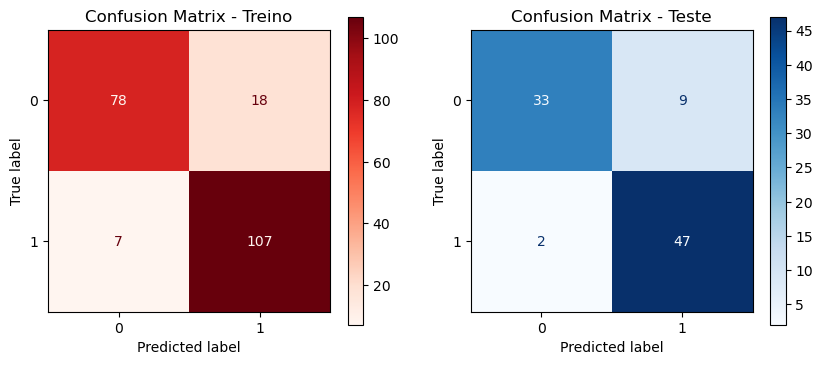

=== MÉTRICAS (Treino) ===
Acurácia:     0.881
Precisão:     0.856
Recall:       0.939

=== MÉTRICAS (Teste) ===
Acurácia:     0.879
Precisão:     0.839
Recall:       0.959


(0.8791208791208791, 0.8392857142857143, 0.9591836734693877)

In [ ]:
Regressao_Linear_(threshold = 0.44, treino_test= [X_train,X_test,y_train,y_test])

**Regressão Linear com backward selection:**

OLS (apenas diagnóstico) - R² e summary:
R² (train): 0.586
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     28.20
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           3.99e-33
Time:                        09:19:09   Log-Likelihood:                -58.971
No. Observations:                 210   AIC:                             139.9
Df Residuals:                     199   BIC:                             176.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

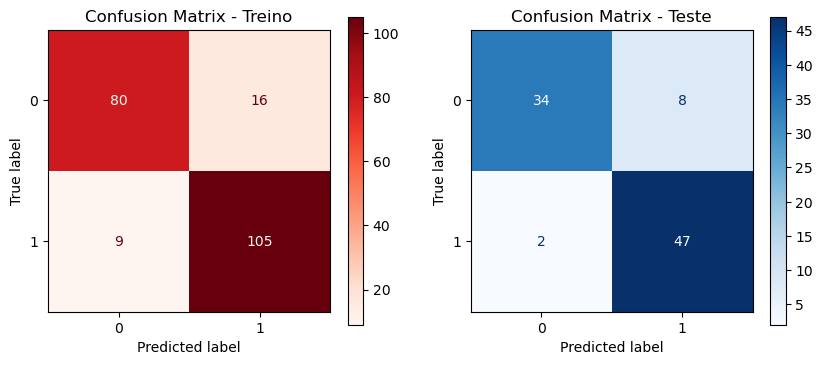

=== MÉTRICAS (Treino) ===
Acurácia:     0.881
Precisão:     0.868
Recall:       0.921

=== MÉTRICAS (Teste) ===
Acurácia:     0.890
Precisão:     0.855
Recall:       0.959


(0.8901098901098901, 0.8545454545454545, 0.9591836734693877)

In [579]:
vars_inbackward.append("constant")

vars_to_keep = list(dict.fromkeys([v for v in vars_inbackward]))


X_train_backward = X_train[[v for v in vars_to_keep if v in X_train.columns]]
X_test_backward = X_test[[v for v in vars_to_keep if v in X_train.columns]]

X_train_backward = sm.add_constant(X_train_backward)
X_test_backward = sm.add_constant(X_test_backward)



Regressao_Linear_(threshold = 0.49, treino_test= [X_train_backward,X_test_backward,y_train,y_test])

**Regressão Logística:**

Parâmetros do Modelo:
{'C': 10000000000.0, 'class_weight': {0: 1, 1: 1.95}, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 500, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': None, 'random_state': None, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Coeficientes do Modelo:
      Variáveis  Coeficientes
0         const      0.458951
1           age     -0.187421
2           sex     -0.938208
3      trestbps     -0.203388
4          chol     -0.425963
5           fbs      0.139445
6       thalach     -0.379168
7         exang     -0.559893
8       oldpeak     -1.141529
9        cp_1.0      0.808990
10       cp_2.0      1.053363
11       cp_3.0      0.733413
12     thal_1.0      0.056911
13     thal_2.0      0.276556
14     thal_3.0     -0.306973
15    slope_1.0     -0.143390
16    slope_2.0      0.656168
17  restecg_1.0     -0.089145
18  restecg_2.0     -0.085107
19       ca_1.0     -0.668007
20       ca_2.0     

/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


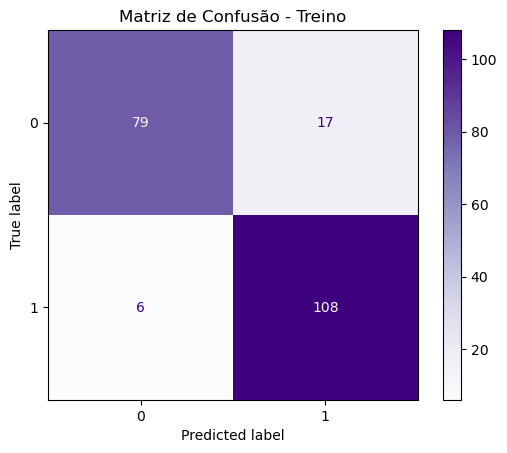

=== Métricas de Teste ===
Acurácia: 0.835 | Precisão: 0.783 | Recall: 0.959


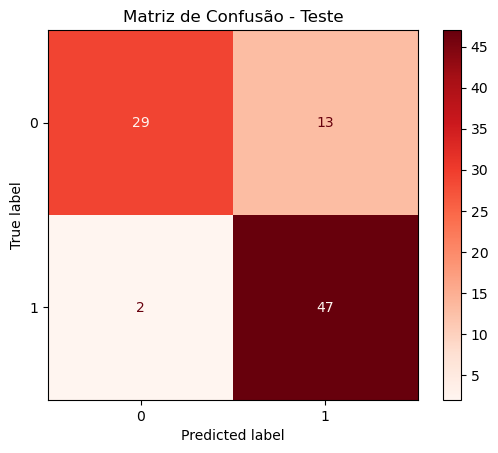

(0.8351648351648352, 0.7833333333333333, 0.9591836734693877)

In [603]:
LogisticRegression_(class_weight={0:1, 1:1.95}, treino_test=[X_train,X_test,y_train,y_test],params = True)

**Regressão Logística com backward selection**

Parâmetros do Modelo:
{'C': 10000000000.0, 'class_weight': {0: 1, 1: 1.95}, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 500, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': None, 'random_state': None, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Coeficientes do Modelo:
   Variáveis  Coeficientes
0      const      0.425285
1        sex     -0.978240
2    oldpeak     -1.212191
3     cp_1.0      0.803459
4     cp_2.0      1.172696
5     cp_3.0      0.747332
6   thal_3.0     -0.682403
7  slope_2.0      0.688087
=== Métricas de Treino ===
Acurácia: 0.843 | Precisão: 0.814 | Recall: 0.921


/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


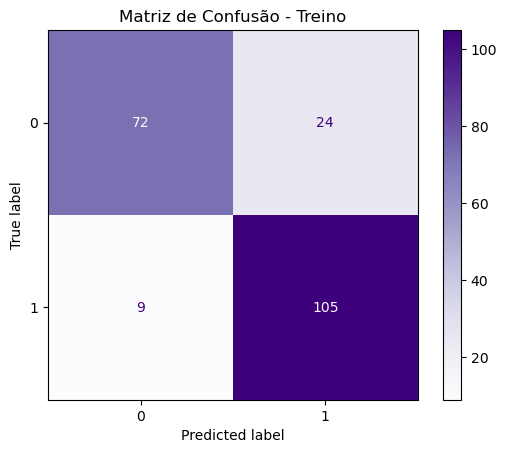

=== Métricas de Teste ===
Acurácia: 0.824 | Precisão: 0.800 | Recall: 0.898


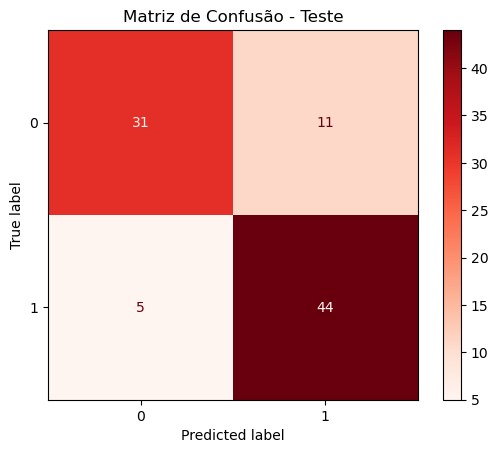

(0.8241758241758241, 0.8, 0.8979591836734694)

In [689]:
vars_to_keep = list(dict.fromkeys([v for v in vars_in_logistic_backward]))


X_train_backward = X_train[[v for v in vars_to_keep if v in X_train.columns]]
X_test_backward = X_test[[v for v in vars_to_keep if v in X_train.columns]]

X_train_backward = sm.add_constant(X_train_backward)
X_test_backward = sm.add_constant(X_test_backward)



LogisticRegression_(class_weight={0:1, 1:1.95}, treino_test= [X_train_backward,X_test_backward,y_train,y_test], params =  True)

**Regressão Logística com ridge**

Parâmetros do Modelo:
{'C': 46.0, 'class_weight': {0: 1, 1: 3}, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 500, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Coeficientes do Modelo:
      Variáveis  Coeficientes
0         const      0.662942
1           age     -0.211189
2           sex     -0.905018
3      trestbps     -0.237792
4          chol     -0.452387
5           fbs      0.113795
6       thalach     -0.409542
7         exang     -0.588981
8       oldpeak     -1.139502
9        cp_1.0      0.809674
10       cp_2.0      1.019667
11       cp_3.0      0.752901
12     thal_1.0      0.057141
13     thal_2.0      0.282864
14     thal_3.0     -0.312143
15    slope_1.0     -0.022118
16    slope_2.0      0.802068
17  restecg_1.0     -0.111552
18  restecg_2.0     -0.100612
19       ca_1.0     -0.704543
20       ca_2.0     -0.8394

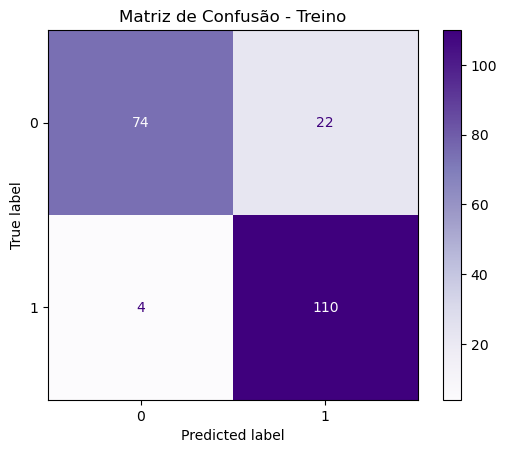

=== Métricas de Teste ===
Acurácia: 0.835 | Precisão: 0.774 | Recall: 0.980


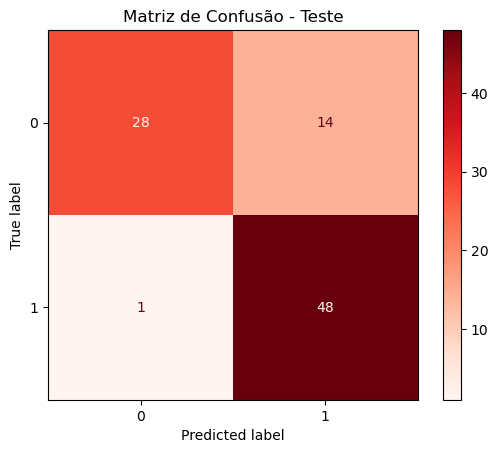

(0.8351648351648352, 0.7741935483870968, 0.9795918367346939)

In [610]:
LogisticRegression_(class_weight={0:1, 1:3},penalty = "l2",lambda_=  1/46, treino_test=[X_train,X_test,y_train,y_test], params = True)

**Regressão Logística com Lasso**

Parâmetros do Modelo:
{'C': 0.46, 'class_weight': {0: 1, 1: 5}, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 500, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Coeficientes do Modelo:
      Variáveis  Coeficientes
0         const      0.827868
1           age     -0.205096
2           sex     -0.726852
3      trestbps     -0.235413
4          chol     -0.389386
5           fbs      0.072667
6       thalach     -0.262475
7         exang     -0.560619
8       oldpeak     -1.008933
9        cp_1.0      0.657604
10       cp_2.0      0.784869
11       cp_3.0      0.618454
12     thal_1.0      0.034800
13     thal_2.0      0.304767
14     thal_3.0     -0.323059
15    slope_1.0     -0.208266
16    slope_2.0      0.513609
17  restecg_1.0     -0.073392
18  restecg_2.0     -0.078603
19       ca_1.0     -0.590043
20       ca_2.0     -0.7633

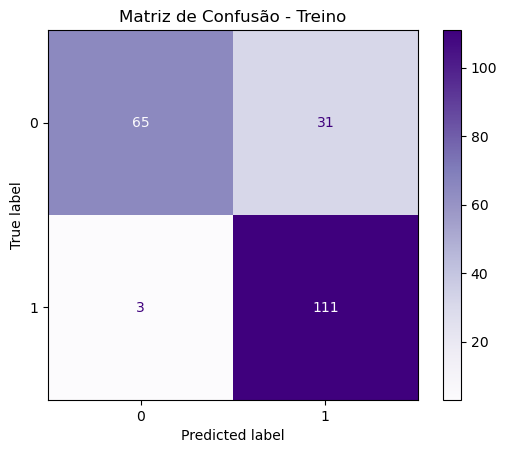

=== Métricas de Teste ===
Acurácia: 0.802 | Precisão: 0.738 | Recall: 0.980


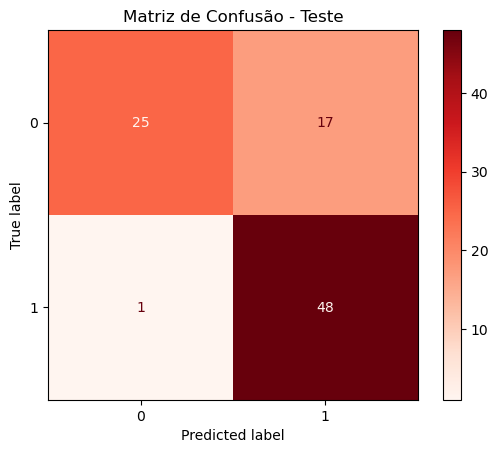

(0.8021978021978022, 0.7384615384615385, 0.9795918367346939)

In [691]:
LogisticRegression_(class_weight={0:1, 1:5},penalty = "l2",lambda_=  1/0.46, treino_test=[X_train,X_test,y_train,y_test], params = True)

**KNN**

=== Métricas de Treino ===
Acurácia: 0.876
Precisão: 0.855
Recall: 0.930

=== Métricas de Teste ===
Acurácia: 0.879
Precisão: 0.852
Recall: 0.939


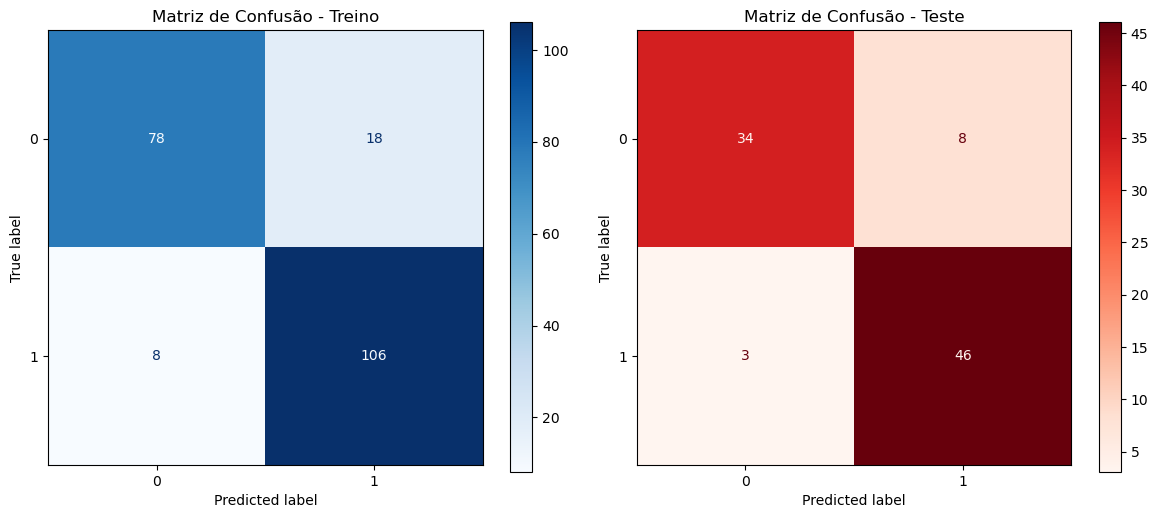

In [628]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Supondo que X_train, X_test, y_train, y_test já estejam definidos

# Inicializa o modelo KNN com k=21
knn = KNeighborsClassifier(n_neighbors=21)

# Treina o modelo
knn.fit(X_trainn, y_train)

# Faz previsões no conjunto de treino e teste
y_pred_train = knn.predict(X_trainn)
y_pred_test = knn.predict(X_testt)

# Calcula as métricas de treino
acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train)
rec_train = recall_score(y_train, y_pred_train)

# Calcula as métricas de teste
acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test)
rec_test = recall_score(y_test, y_pred_test)

# Exibe as métricas
print("=== Métricas de Treino ===")
print(f"Acurácia: {acc_train:.3f}")
print(f"Precisão: {prec_train:.3f}")
print(f"Recall: {rec_train:.3f}")

print("\n=== Métricas de Teste ===")
print(f"Acurácia: {acc_test:.3f}")
print(f"Precisão: {prec_test:.3f}")
print(f"Recall: {rec_test:.3f}")

# Plota as Matrizes de Confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de Confusão para o treino
cm_train = confusion_matrix(y_train, y_pred_train)
cm_display_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=[0, 1])
cm_display_train.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title("Matriz de Confusão - Treino")

# Matriz de Confusão para o teste
cm_test = confusion_matrix(y_test, y_pred_test)
cm_display_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[0, 1])
cm_display_test.plot(cmap=plt.cm.Reds, ax=axes[1])
axes[1].set_title("Matriz de Confusão - Teste")

plt.tight_layout()
plt.show()



**LDA**

=== AVALIAÇÃO DO LDA NO CONJUNTO DE TESTE (30%) ===
Threshold:  0.35
Acurácia :  0.879
Precisão :  0.839
Recall: 0.959


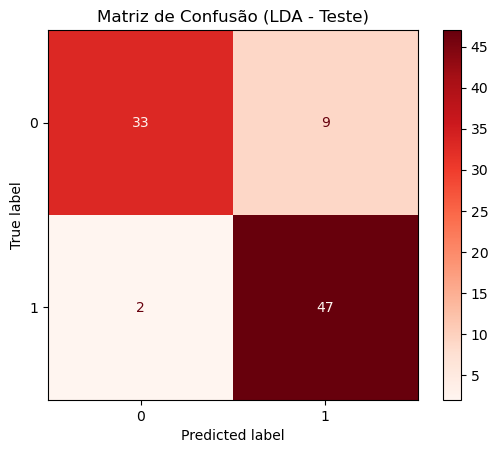


=== AVALIAÇÃO DO LDA NO CONJUNTO DE TREINO ===
Acurácia Treino: 0.881
Precisão Treino: 0.856
Recall Treino: 0.939


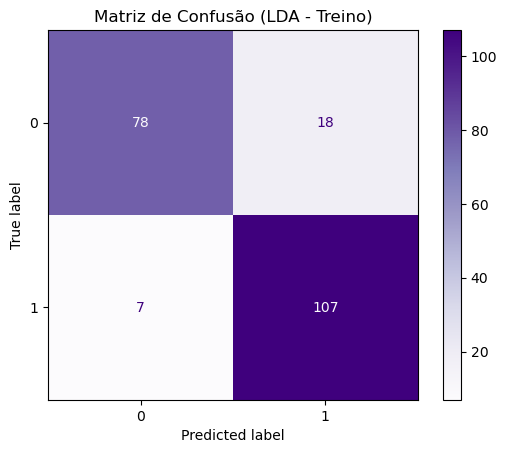

(0.8791208791208791, 0.8392857142857143, 0.9591836734693877)

In [614]:
LDA_model_(threshold= 0.35, treino_test=[X_train,X_test,y_train,y_test])

**QDA**

AVALIAÇÃO DO QDA NO CONJUNTO DE TESTE (30%)
-------------------------------------------
Threshold:  0.01
Acurácia :  0.769
Precisão :  0.719
Recall: 0.939
-------------------------------------------


/home/al.igor.alves/anaconda3/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


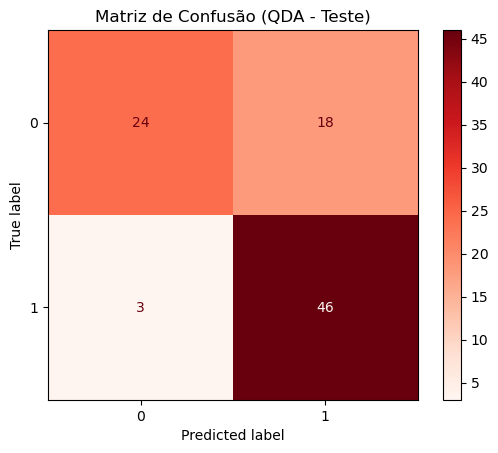

Acurácia Treino: 0.838
Precisão Treino: 0.786
Recall Treino: 0.965


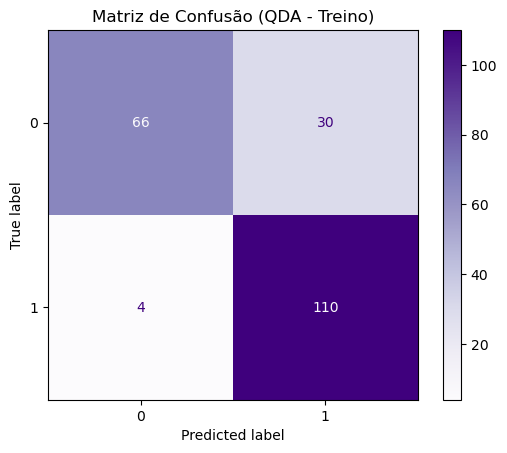

(0.7692307692307693,
 0.71875,
 0.9387755102040817,
 0.8380952380952381,
 0.7857142857142857,
 0.9649122807017544)

In [629]:
QDA_(threshold = 0.01, treino_test= [X_trainn, X_testt, y_train, y_test])

**SVM**

=== Métricas de Treino ===
Acurácia: 0.867
Precisão: 0.841
Recall: 0.930

=== Métricas de Teste ===
Acurácia: 0.923
Precisão: 0.904
Recall: 0.959


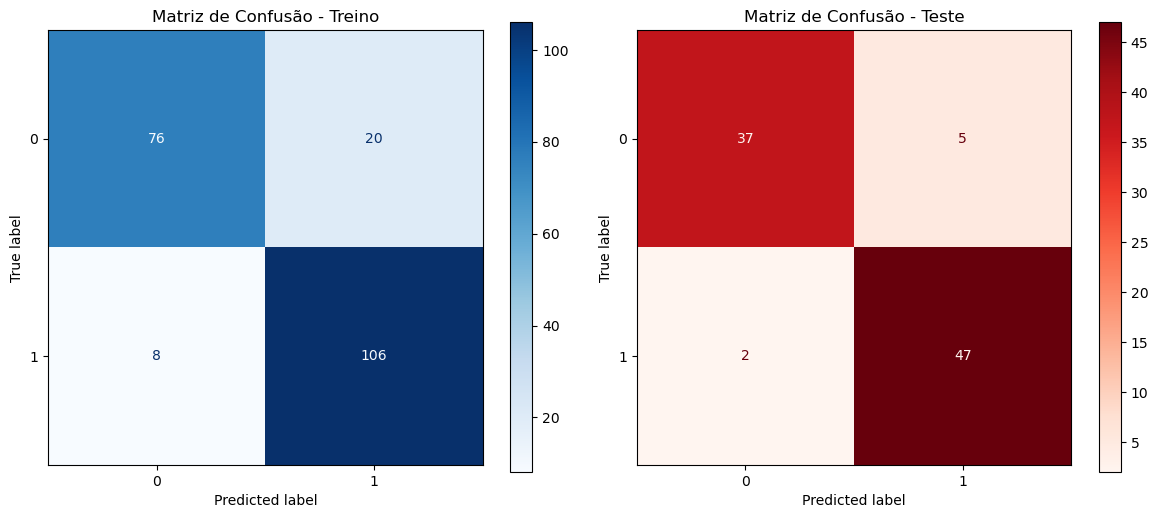

In [630]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Supondo que X_train, X_test, y_train, y_test já estão definidos

# Inicializa o modelo SVC com os parâmetros especificados
svc_model = SVC(kernel='linear', C=0.01, gamma='scale')

# Treina o modelo
svc_model.fit(X_trainn, y_train)

# Faz previsões no conjunto de treino e teste
y_pred_train = svc_model.predict(X_trainn)
y_pred_test = svc_model.predict(X_testt)

# Calcula as métricas de treino
acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train)
rec_train = recall_score(y_train, y_pred_train)

# Calcula as métricas de teste
acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test)
rec_test = recall_score(y_test, y_pred_test)

# Exibe as métricas
print("=== Métricas de Treino ===")
print(f"Acurácia: {acc_train:.3f}")
print(f"Precisão: {prec_train:.3f}")
print(f"Recall: {rec_train:.3f}")

print("\n=== Métricas de Teste ===")
print(f"Acurácia: {acc_test:.3f}")
print(f"Precisão: {prec_test:.3f}")
print(f"Recall: {rec_test:.3f}")

# Plota as Matrizes de Confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de Confusão para o treino
cm_train = confusion_matrix(y_train, y_pred_train)
cm_display_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=[0, 1])
cm_display_train.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title("Matriz de Confusão - Treino")

# Matriz de Confusão para o teste
cm_test = confusion_matrix(y_test, y_pred_test)
cm_display_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[0, 1])
cm_display_test.plot(cmap=plt.cm.Reds, ax=axes[1])
axes[1].set_title("Matriz de Confusão - Teste")

plt.tight_layout()
plt.show()


**Rede Neural**

=== Métricas de Treino ===
Acurácia: 0.881
Precisão: 0.880
Recall: 0.904

=== Métricas de Teste ===
Acurácia: 0.923
Precisão: 0.904
Recall: 0.959


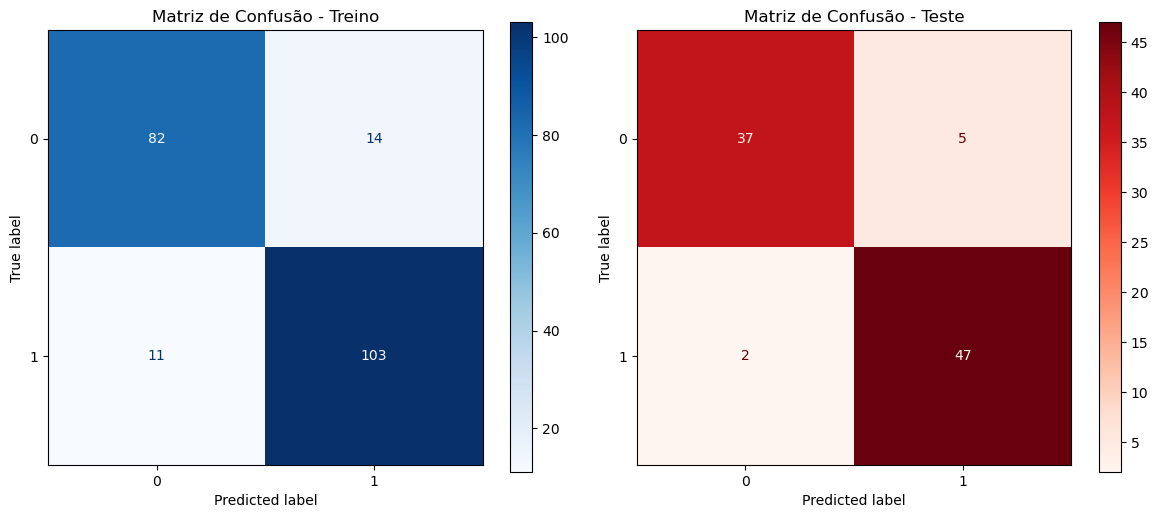

(0.9230769230769231, 0.9038461538461539, 0.9591836734693877)

In [676]:
NeuralNet_model(treino_test=[X_trainn, X_testt,y_train,y_test])

# Conclusão Heart Disease

A principal ideia desse Dataset é de alguma maneira conseguir preditar um indíviduo possivelmente com alguma doença cardíaca a partir de fatores pessoiais.

## Primeiros insights sobre os preditores

In [ ]:
import pandas as pd

# Criando o DataFrame com as informações em português
data = {
    'Preditor': [
        'Idade (anos)', 'Sexo', 'Tipo de Dor no Peito', 'Pressão Arterial em Repouso', 'Colesterol Sérico (mg/dl)',
        'Glicemia de Jejum', 'Eletrocardiograma em Repouso', 'Frequência Cardíaca Máxima', 'Angina Induzida por Exercício',
        'Oldpeak (depressão ST no exercício)', 'Inclinação do Segmento ST no Pico do Exercício', 'Número de Vasos Coloridos pela Fluoroscopia',
        'Teste de Estresse com Tálio', 'Doença Cardíaca (Target)'
    ],
    'Descrição': [
        'Idade em anos (valor contínuo entre 29 e 77)',
        'Sexo: 1 representa masculino, 0 representa feminino',
        'Tipo de dor no peito: 0 - Angina Típica, 1 - Angina Atípica, 2 - Dor Não-Anginosa, 3 - Assintomático',
        'Pressão arterial em repouso: 90–120 (normal), 120–140 (usual), 140–160 (alta), >160 (muito alta)',
        'Colesterol sérico em mg/dl: 110–200 (normal), 200–240 (borderline alto), 240–250 (alto), >250 (muito alto)',
        'Glicemia de jejum > 120 mg/dl: 1 - verdadeiro, 0 - falso',
        'Resultado do eletrocardiograma em repouso: 0 - normal, 1 - anormalidade ST-T, 2 - provável hipertrofia ventricular esquerda',
        'Frequência cardíaca máxima alcançada: 60–100 (normal), >100 (taquicardia)',
        'Angina induzida por exercício: 1 - sim, 0 - não',
        'Depressão ST induzida por exercício (relativo ao repouso): valor entre 0 e 6.2',
        'Inclinação do segmento ST no pico do exercício: 0 - subida, 1 - plano, 2 - descida',
        'Número de vasos (0-3) coloridos por fluoroscopia: valor entre 0 e 3',
        'Teste de estresse com Tálio: 0 - normal, 1 - defeito fixo, 2 - defeito reversível',
        'Doença cardíaca (target): 0 - sem chances de doença cardíaca, 1 - chances de doença cardíaca'
    ],
    'Valor': [
        '29 < idade > 77', '1-masculino, 0-feminino', '0-angina típica, 1-angina atípica, 2-dor não-anginosa, 3-assintomático',
        '90–120: normal, 120–140: incomum, 140–160: alta, >160: muito alta', '110–200: normal, 200–240: limite alto, 240–250: alto, >250: muito alto',
        '1-verdadeiro, 0-falso', '0-normal, 1-anormalidade ST-T, 2-hipertrofia ventricular esquerda', '60–100-normal, >100-taquicardia',
        '1-sim, 0-não', '0–6.2', '1-suba, 2-plano, 3-desça', '0-3', '0-normal, 1-fixo, 2-reversível', '0-sem doença, 1-com doença'
    ],
    'Tipo': [
        'Numérico', 'Nominal', 'Nominal', 'Numérico', 'Numérico', 'Nominal', 'Nominal', 'Numérico', 'Nominal', 'Numérico', 'Nominal', 'Nominal', 'Nominal', 'Classe'
    ]
}

# Criando o DataFrame
df_portugues = pd.DataFrame(data)

# Exibindo o DataFrame
df_portugues


NARASIMHAN, G.; VICTOR, A. Empirical analysis of predicting heart disease using diverse datasets and classification procedures of machine learning. Ain Shams Engineering Journal, v. 16, n. 8, p. 103470–103470, 16 maio 2025. https://www.sciencedirect.com/science/article/pii/S2090447925002114

In [ ]:
data = {
    'Preditor': [
        'Idade', 'Sexo', 'Tipo de Dor no Peito - Angina Típica', 'Tipo de Dor no Peito - Angina Atípica',
        'Tipo de Dor no Peito - Dor Não-Anginosa', 'Tipo de Dor no Peito - Assintomático', 'Pressão Arterial em Repouso',
        'Colesterol Sérico (LDL)', 'Glicemia de Jejum > 120 mg/dl', 'Eletrocardiograma em Repouso - Normal (0)',
        'Eletrocardiograma em Repouso - Anormalidade ST-T (1)', 'Eletrocardiograma em Repouso - Hipertrofia Ventricular Esquerda (2)',
        'Frequência Cardíaca Máxima', 'Angina Induzida por Exercício', 'Oldpeak (depressão ST no exercício)',
        'Inclinação ST no pico do exercício', 'Número de Grandes Vasos Fluorescência', 'Escala de Defeito - Normal (0)',
        'Escala de Defeito - Defeito Fixo (1)', 'Escala de Defeito - Defeito Reversível (2)'
    ],
    'Influência na Doença Cardíaca': [
        'Positiva (↑)', 'Positiva (↑)', 'Positiva (↑)', 'Positiva (↑)', 'Negativa (↓)', 'Positiva (↑)', 'Positiva (↑)',
        'Positiva (↑)', 'Positiva (↑)', 'Negativa (↓)', 'Positiva (↑)', 'Positiva (↑)', 'Positiva (↑)', 'Positiva (↑)',
        'Positiva (↑)', 'Positiva (↑)', 'Positiva (↑)', 'Negativa (↓)', 'Positiva (↑)', 'Positiva (↑)'
    ],
    'Interpretação': [
        'Idade avançada aumenta o risco devido ao envelhecimento das artérias e menor elasticidade.',
        'Homens têm maior risco de doenças cardíacas em idades mais jovens; mulheres têm risco aumentado após a menopausa.',
        'Dor clássica associada à doença arterial coronariana, risco elevado de infarto e AVC.',
        'Dor semelhante à angina típica, indica problemas cardíacos subclínicos, como isquemia.',
        'Não relacionada ao coração, pode indicar outros problemas, mas não risco direto de doenças cardíacas.',
        'Ausência de dor não descarta risco, pode indicar doenças cardíacas silenciosas como infarto.',
        'Hipertensão eleva risco de infarto, AVC e insuficiência cardíaca, sobrecarregando o coração.',
        'Colesterol elevado (LDL) contribui para aterosclerose, aumentando risco de infarto e AVC.',
        'Glicemia elevada é um indicador de diabetes tipo 2, que danifica vasos sanguíneos e aumenta o risco cardiovascular.',
        'ECG normal sugere ausência de problemas cardíacos evidentes, mas não descarta completamente doenças cardíacas.',
        'Alterações ST-T indicam isquemia, um forte sinal de risco de infarto e angina.',
        'Hipertrofia ventricular esquerda devido à hipertensão, aumentando risco de insuficiência cardíaca e arritmias.',
        'Uma frequência cardíaca baixa durante o exercício sugere disfunção cardíaca ou baixo nível de aptidão física.',
        'Indica que o coração não recebe oxigênio suficiente durante o exercício, sugerindo doença coronariana.',
        'Depressão ST no exercício sugere isquemia, risco aumentado de infarto e outras condições cardíacas.',
        'Elevação é o resultado esperado, sapida plana ou descida ST durante o exercício sugere isquemia',
        'Quanto mais vasos afetados, maior o risco de doença coronariana, indicando múltiplas obstruções nas artérias.',
        'Sem defeitos no coração, indicando função cardíaca saudável.',
        'Defeito fixo indica dano permanente ao coração, geralmente por isquemia ou infarto.',
        'Defeito reversível sugere isquemia transitória, mas ainda um risco significativo se não tratado.'
    ]
}

# Criando o DataFrame
df = pd.DataFrame(data)

# Exibindo o DataFrame
df


## Insights Analise Exploratoria

* Idade entre 29 e 77 anos, maioria entre 50 e 60 anos - Não há diferença significativa na idade média entre homens e mulheres.
* Maioria homens (68%)
* Maioria com pressão arterial já elevada, taxas altas de colesterol, anginia tipica, pressão arterial já em níveis incomuns, sinais de taquicardia, inclinações planas ou de descida de ST no pico do exercicio e grande presença de defeitos fixos ou reversíveis
* Bem dividido entre pessoas com eletrocardiograma em repouso normal e pessoas que apresentem anormalidade que indica isquemia
* Maioria sem pré diabetes e sem dor no peito (anginia) causada por exercicios, concentração em valores baixos de oldpeak, sem grandes vasos obstruídos

Dataset com pessoas já com grande indicativo de doenças cardiacas. Dividido meio a meio em doentes e não doentes (bom pq temos um grupo de controle de não doentes também, importante essa divisão em análises na área da saúde)

## Resumo Pré Processamento

Como o dataset parece corrompido, para contornar essa situação iremos "aleatorizar" um pouco nossas instâncias, removendo dados aleatoriamente e depois fazendo um método de imputação

Resumo:

Delete: Introduziu dados faltantes aleatoriamente para criar uma situação controlada de dados ausentes.

Imputação: Preencheu os dados ausentes usando KNN, substituindo valores ausentes com base em instâncias similares.

Transformações finais: Ajustou as variáveis para garantir que os dados imputados estivessem dentro dos intervalos válidos e condizentes com o tipo da variável.

# Modelagem:

Modelos usados:

* Regressão Linear
* LDA
* QDA
* Regressão Logística
* KNN
* SVM
* Rede Neural


## Resultados Modelagem

**OLS**

Fizemos uma Regressão Linear e uma Backward Sellection.
A seleção backward eliminou alguns preditores, ficando com a saída final de:

* $\hat{target}=0.5456−0.0913⋅sex−0.0656⋅exang−0.1141⋅oldpeak+0.1177⋅cp_1+0.1311⋅cp_2+0.0886⋅cp_3+0.0743⋅thal_2−0.0686⋅slope_1−0.0700⋅ca_1−0.0522⋅ca_2−0$

* Acurácia no conjunto de treino: 0.881
* Acurácia no conjunto de teste: 0.890

Para ter uma estimativa mais robusta, fizemos uma validação cruzada (cross-validation), aplicando a regressão linear em cinco divisões (5-folds) diferentes dos dados.

**Esse método fornece uma estimativa mais confiável da performance média do modelo, pois reduz a influência da divisão específica dos dados em treino e teste, além de representar melhor sua capacidade de generalização ou seja, o risco de erro ao aplicar o modelo em novos dados**

----------------------------------------------------

**LDA**

Após a abordagem inicial com a Regressão Linear como um classificador, passaremos agora para a Análise Linear Discriminante (LDA), um método que modela a classificação de maneira inerentemente estatística e mais robusta.

LDA é um algoritmo que assume que os dados de cada classe seguem uma distribuição Gaussiana (Normal) e que todas as classes compartilham da mesma matriz de covariância (ou seja, a mesma dispersão). A ideia central é:

Projetar os Dados: Encontrar um eixo (ou subespaço) que maximize a separação entre as médias das classes e minimize a variação dentro de cada classe.

Decisão: Classificar um novo ponto de dados na classe cuja média, ele está mais próximo após a projeção.

A principal vantagem do LDA é a sua capacidade de reduzir a dimensionalidade enquanto otimiza a separação entre as classes, tornando-o um classificador linear eficiente e interpretável. Para garantir a validade estatística do modelo, o Standard Scaling das variáveis contínuas é um passo obrigatório, pois o LDA é sensível à escala das variáveis


--- RESUMO FINAL DA VALIDAÇÃO CRUZADA TESTE (LDA) ---

Acurácia:  0.879

Precisão :  0.839

Recall:  0.959

-------------------------------------------------------

**QDA**

A Análise Quadrática Discriminante (QDA) é a progressão natural da Análise Linear Discriminante (LDA). Enquanto o LDA assume que todas as classes compartilham a mesma matriz de covariância (ou seja, a dispersão dos dados é idêntica para todas as classes), o QDA relaxa essa suposição

RESUMO FINAL DA VALIDAÇÃO CRUZADA TESTE (QDA)

Acurácia Média:  0.769

Precisão Média:  0.719

Recall Médio:    0.939

-----------------------------------------------------

**Logit**

Fizemos uma Regressão Logistica com peso 1.95 na classe 1.

Após a validação cruzada:

Métrica | Treino | Teste

Acurácia | 0.890 | 0.868

Precisão | 0.864 | 0.825

Recall | 0.947 | 0.959

**Lasso $\lambda = 2.17, W1 = 5$ com Validação Cruzada:**

Resultados após a validação cruzada:

Métrica | Treino | Teste

Acurácia | 0.833 | 0.813

Precisão | 0.772 | 0.750

Recall | 0.982 | 0.980

**Ridge $\lambda = 0.022, W1 = 3$ com Validação Cruzada:**

Resultados após a validação cruzada:

Métrica | Treino | Teste

Acurácia | 0.890 | 0.835

Precisão | 0.864 | 0.783

Recall | 0.947 | 0.959

-------------------------------------------------------------


In [ ]:
print("Tabela Resumo modelos Logit, Ridge e Lasso:")
# Crie uma lista de dicionários com os valores das métricas de cada modelo
data = [
    {
        'Modelo': 'Logit',
        'Acurácia (Teste)': 0.868,
        'Precisão (Teste)': 0.825,
        'Recall (Teste)': 0.959
    },
    {
        'Modelo': 'Lasso',
        'Acurácia (Teste)': 0.813,
        'Precisão (Teste)': 0.750,
        'Recall (Teste)': 0.980
    },
    {
        'Modelo': 'Ridge',
        'Acurácia (Teste)': 0.835,
        'Precisão (Teste)': 0.783,
        'Recall (Teste)': 0.959
    }
]

# Criar o DataFrame
df = pd.DataFrame(data)

# Exibir o DataFrame
print(df)


Ridge adiciona uma penalização baseada no quadrado dos coeficientes, ajudando a evitar overfitting sem eliminar variáveis. É útil quando as variáveis são correlacionadas.

Lasso penaliza a soma dos valores absolutos dos coeficientes, o que pode levar a zerar variáveis irrelevantes, fazendo uma seleção automática de características.

Ambos são usados para evitar overfitting e melhorar a generalização do modelo, especialmente em dados com muitas variáveis. Ridge é bom para variáveis correlacionadas, enquanto Lasso é útil quando queremos selecionar automaticamente as variáveis mais importantes.

-----------------------------------------------------------
**Backward Sellection no LOGIT**

Fizemos o backward sellection no método logit, afim de poder elimitar preditores com menor poder de influencia no nosso modelo. Escolhemos fazer somente nesse pois teve o desempenho melhor, sem a necessidade dos métodos Ridge e Lasso. Isso permite termos insights interpretaveis para a conclusão.

Métrica | Treino | Teste

Acurácia | 0.843 | 0.824

Precisão | 0.814 | 0.800

Recall | 0.921 | 0.898

* $\hat {LogitTarget} = 0.42 -0.98sex - 1.21oldpeak + 0.80cp1 + 1.17cp2 + 0.75cp3 -0.68thal3 + 0.69slope2$

**KNN**

O KNN (K-Nearest Neighbors) é um algoritmo de aprendizado supervisionado usado para classificação e regressão. Ele funciona classificando um ponto com base nos k vizinhos mais próximos no conjunto de dados. Para prever a classe de um ponto, o KNN calcula a distância até os outros pontos e seleciona a maioria das classes dos vizinhos mais próximos.

A melhor configuração que achamos toma k = 21

KNN — Avaliação Final (k=21, cosine):

Treino: Acc=0.876 | Prec=0.855 | Rec=0.930

Teste : Acc=0.879 | Prec=0.852 | Rec=0.939

--------------------------------------------------------

**SVM**

O SVM (Support Vector Machine) é um algoritmo de aprendizado supervisionado utilizado para classificação. Ele busca encontrar uma hiperplano que separa as diferentes classes de dados com a maior margem possível.

Kernel: rbf

C é o parâmetro de regularização = 1

Treino: Acc=0.867 | Prec=0.841 | Rec=0.930

Teste : Acc=0.923 | Prec=0.904 | Rec=0.959

-------------------------------------------------------

**Redes Neurais**

Treino: Acc=0.881 | Prec=0.880 | Rec=0.904

Teste : Acc=0.923 | Prec=0.904 | Rec=0.959

-----------------------------------------------------

**Comparando os resultados**



In [ ]:
import pandas as pd

# Dados fornecidos
data = {
    'model': [
        'Logistic', 'Lasso', 'Ridge', 'LDA', 'QDA',
        'KNN', 'SVM', 'Redes Neurais'
    ],
    'acc_test': [
        0.868, 0.802, 0.835, 0.881, 0.769, 0.879, 0.923, 0.923
    ],
    'prec_test': [
        0.825, 0.738, 0.783, 0.856, 0.719, 0.852, 0.904, 0.904
    ],
    'rec_test': [
        0.959, 0.980, 0.959, 0.939, 0.939, 0.939, 0.959, 0.959
    ],
}

# Criando o DataFrame
df = pd.DataFrame(data)

# Exibindo os DataFrames
print("Tabela Resumo dos Modelos:")
print(df)



**Qual o melhor modelo?**

Os modelos que tiveram melhor desempenho foram as redes neurais e o SVM. A regressão Logistica com o Lasso apresentou bom Recall, parametro desejado em modelagens de detecção de doenças, mas com acurácia significativamente menor.

**Quais preditores indicam probabilidade de doença cardiaca?**

A nível de interpretabilidade, vamos analisar o modelo Logit com Backward Sellection para compreender os preditores que tem influência significativa na nossa modelagem.

$\hat {LogitTarget} = 0.42 -0.98sex - 1.21oldpeak + 0.80cp1 + 1.17cp2 + 0.75cp3 -0.68thal3 + 0.69slope2$

Os preditores com constante negativa diminuem o valor do log da probabilidade, indicando menor probabilidade do target ser igual a 1.

Nesse caso, seriam os preditores:

* sexo, oldpeak, ca, thal_3

Os positivos são:

cp_1, cp_2, cp_3, slope_2

O que indica que:

* Ser homem diminui a incidencia de doença cardiaca
* Oldpeaks altos diminuem a incidencia de doença cardiaca
* Obstrução em artérias diminui a incidencia de doença cardiaca
* Defeitos reversíveis no teste de estresse com Talio indicam baixa incidencia de doença cardiaca
* Pessoas assintomaticas (sem dor no peito), com dores ou pessoas com dores no peito não causadas por angina tem maior tendencia a doenças cardiacas
* Pessoas com slope 2 (descida) tem maior tendencia a doenças cardiacas

**Limitações**

A escolha do dataset prejudicou o nosso resultado obtido, pois indica uma influencia negativa de diversos preditores em que é sabido que aumentam a tendencia a doenças cardiovasculares (e que foram explicados acima).

Um possível erro, como ja explicado pelo notebook, é a troca dos resultados 1 e 0 (no dataset de Cleaveland, diz que tem 164 com doença cardiaca e 138 sem doença cardiaca, enquanto no nosso esse número está invertido).

Não fizemos a troca inicialmente pois iria enviesar os resultados, e não temos um fator que indique com certeza essa possível troca. Porém, é uma interpretação possível que possibilita um modelo ótimo de previsão de doenças cardiacas, pois mantém a sua acurácia e recall (não precisa alterar em nada a modelagem do problema), e que os preditores batem com os resultados esperados inicialmente,